# Notebook GNN spatial pur sur réseau de gaz avec charge GFPP

Ce notebook **repart de zéro** et construit un pipeline complet **PyTorch + PyTorch Geometric** pour prédire les injections `g` des **4 wells** sur les **24 prochaines heures** à partir des **72 heures passées** et de la **structure spatiale du réseau de gaz**.

## Points imposés dans cette version
- **modèle purement spatial**
  - pas de GRU
  - pas de LSTM
  - pas d'attention temporelle
- **encodeur = MLP**
- **message passing spatial**
- **décodeur = MLP**
- **aucune feature dynamique d'arête**
- **aucun usage de `q` comme input**
- **features d'arête = uniquement statiques**
- ajout d'une **nouvelle consommation nodale dynamique GFPP** construite à partir de `p`

## Idée générale
Les 72 heures d'historique sont intégrées **dans les features nodales d'entrée** en **aplatissant temporellement** les séries dynamiques par nœud.  
Le GNN traite ensuite **spatialement** le graphe gaz.

## Charge GFPP ajoutée
On ajoute une nouvelle composante dynamique nodale :

\[
	ext{gaz\_GFPP}(t) = rac{p(t)	imes 	ext{base}}{	ext{ConversionFactor}	imes \eta}
\]

avec :
- `p(t)` = production électrique des générateurs
- `base` = facteur pour convertir `p` vers MW si nécessaire
- `ConversionFactor` = contenu énergétique du gaz
- `eta` = rendement de la centrale

Cette charge est :
- **agrégée par nœud gas**
- **ajoutée aux inputs**
- **jamais ajoutée aux targets**

In [1]:
# ============================================================
# Cellule 1 - Installation / vérification de PyTorch Geometric
# ============================================================
import sys
import subprocess
import pkgutil

def ensure_package(pkg_name: str, pip_name: str | None = None):
    if pkgutil.find_loader(pkg_name) is None:
        name = pip_name or pkg_name
        print(f"Installation de {name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", name])
    else:
        print(f"{pkg_name} déjà installé.")

ensure_package("torch_geometric", "torch-geometric")

torch_geometric déjà installé.


In [1]:
# ============================================================
# Cellule 2 - Hyperparamètres / constantes / chemins
# Tout est regroupé ici
# ============================================================
from pathlib import Path

CONFIG = {
    # -------------------------
    # chemins
    # -------------------------
    "BASE_DIR": Path("."),
    "PATH_NETWORK": Path("Gas Network Data.xlsx"),
    "PATH_CONS_DISTRIB": Path("./input/Gas Cons Distrib.xlsx"),
    "PATH_CONS_EXPORT": Path("./input/Gas Cons Export.xlsx"),
    "PATH_CONS_IND": Path("./input/Gas Cons Ind.xlsx"),
    "PATH_DECISION": Path("./output/Decision_variablesRU.xlsx"),

    # -------------------------
    # structure problème
    # -------------------------
    "MONTHS": [f"{m:02d}" for m in range(1, 13)],
    "NUM_NODES": 28,
    "WELL_IDX": [0, 4, 16, 17],   # indices 0-based
    "TARGET_COLS_ARE_ALL_G": True,

    # -------------------------
    # fenêtres temporelles
    # -------------------------
    "HIST_HOURS": 72,
    "HORIZON_HOURS": 24,
    "STRIDE_HOURS": 24,

    # -------------------------
    # split temporel
    # target_start < TRAIN_END -> train
    # TRAIN_END <= target_start < VAL_END -> val
    # target_start >= VAL_END -> test
    # -------------------------
    "TRAIN_END": "2024-10-01 00:00:00",
    "VAL_END": "2024-11-01 00:00:00",

    # -------------------------
    # features dynamiques nodales
    # chacune sera aplatie sur 72h
    # -------------------------
    "USE_PR_HISTORY": False,
    "USE_RES_DEMAND_HISTORY": True,
    "USE_IND_DEMAND_HISTORY": True,
    "USE_EXP_DEMAND_HISTORY": True,
    "USE_GFPP_GAS_LOAD_HISTORY": True,   # NOUVELLE FEATURE
    "USE_G_HISTORY": False,               # historique g des wells injecté aux noeuds wells
    "USE_RAW_P_HISTORY_ON_GAS_NODES": False,  # laissé en option, mais False par défaut

    # -------------------------
    # features statiques nodales
    # -------------------------
    "USE_NODE_STATIC_IS_WELL": True,
    "USE_NODE_STATIC_SHARES": True,
    "USE_NODE_STATIC_PRESSURE_BOUNDS": True,
    "USE_NODE_STATIC_DEGREE": True,
    "USE_NODE_STATIC_IS_GFPP_LOAD_NODE": True,
    "USE_NODE_STATIC_GFPP_COUNT": True,

    # -------------------------
    # features statiques d'arête
    # ne pas mettre de colonne texte
    # -------------------------
    "EDGE_STATIC_COLUMNS": [
        "Natural gas flow constant [MNm3/(bar*h)2]",
        "Compressor factor",
        "High Linepack",
        "Initial linepack [MNm3]",
        "Linepack constant [MNm3/bar]",
        "Estimated lenght [km]",
    ],
    "USE_BIDIRECTIONAL_EDGES": True,

    # -------------------------
    # paramètres GFPP
    # logique: gaz = (p * base) / (ConversionFactor * Efficiency)
    # -------------------------
    # si p est en pu et que la base du modèle vaut 100 MW -> mettre 100.0
    # si p est déjà en MW -> mettre 1.0
    "GFPP_P_TO_MW_MULTIPLIER": 100.0,

    # contenu énergétique du gaz en MWh par MNm3
    # ordre de grandeur compatible avec ~11 kWh/Nm3
    "GFPP_GAS_ENERGY_CONTENT_MWH_PER_MNM3": 11000.0,

    # rendement global par défaut si on n'a pas mieux
    "GFPP_DEFAULT_EFFICIENCY": 0.55,

    # override optionnel par générateur (index 0-based de p)
    # exemple: {3: 0.52, 4: 0.58}
    "GFPP_EFFICIENCY_BY_GENERATOR": {},

    # si une colonne d'efficacité existe un jour, on pourrait l'utiliser
    "GFPP_USE_OPTIONAL_EFFICIENCY_COLUMN": False,
    "GFPP_OPTIONAL_EFFICIENCY_COLUMN_NAME": "Efficiency",

    # -------------------------
    # modèle
    # -------------------------
    "MODEL_TYPE": "gine",   # "gine" ou "nnconv"
    "HIDDEN_DIM": 8,
    "ENCODER_HIDDEN_DIMS": [4,2],
    "DECODER_HIDDEN_DIMS": [2, 4],
    "NUM_MP_LAYERS": 4,
    "DROPOUT": 0.1,
    "USE_BATCHNORM": True,
    "RESIDUAL": False,

    # -------------------------
    # entraînement
    # -------------------------
    "SEED": 42,
    "DEVICE": "cpu",  # "cuda" si dispo
    "EPOCHS": 100,
    "BATCH_SIZE": 24,
    "LR": 5e-4,
    "WEIGHT_DECAY": 1e-4,
    "GRAD_CLIP_NORM": 2.0,
    "EARLY_STOPPING_PATIENCE": 30,
    "SCHEDULER_FACTOR": 0.6,
    "SCHEDULER_PATIENCE": 4,
    "SCHEDULER_MIN_LR": 1e-5,

    # -------------------------
    # baseline / diagnostics / plots
    # -------------------------
    "PERSISTENCE_MODE": "last_24h",   # "last_value" ou "last_24h"
    "NUM_ALIGNMENT_CHECKS": 10,
    "NUM_PLOT_SAMPLES": 3,
    "PLOT_WELL_LOCAL_INDEX": 0,
    "SAVE_MODEL_STATE": False,
    "MODEL_STATE_PATH": Path("spatial_gas_gnn_gfpp.pt"),
}

PATHS = {
    "network": CONFIG["BASE_DIR"] / CONFIG["PATH_NETWORK"],
    "cons_distrib": CONFIG["BASE_DIR"] / CONFIG["PATH_CONS_DISTRIB"],
    "cons_export": CONFIG["BASE_DIR"] / CONFIG["PATH_CONS_EXPORT"],
    "cons_ind": CONFIG["BASE_DIR"] / CONFIG["PATH_CONS_IND"],
    "decision": CONFIG["BASE_DIR"] / CONFIG["PATH_DECISION"],
}

print("Fichiers attendus :")
for k, v in PATHS.items():
    print(f"  {k}: {v.resolve()} | exists={v.exists()}")

for p in PATHS.values():
    assert p.exists(), f"Fichier introuvable: {p}"

print("\nCONFIG OK.")

Fichiers attendus :
  network: C:\Users\yoans\TFE - GAZ\Gas Network Data.xlsx | exists=True
  cons_distrib: C:\Users\yoans\TFE - GAZ\input\Gas Cons Distrib.xlsx | exists=True
  cons_export: C:\Users\yoans\TFE - GAZ\input\Gas Cons Export.xlsx | exists=True
  cons_ind: C:\Users\yoans\TFE - GAZ\input\Gas Cons Ind.xlsx | exists=True
  decision: C:\Users\yoans\TFE - GAZ\output\Decision_variablesRU.xlsx | exists=True

CONFIG OK.


In [2]:
# ============================================================
# Cellule 3 - Imports, seed, utilitaires de base
# ============================================================
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GINEConv, NNConv

warnings.filterwarnings("ignore")

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(CONFIG["SEED"])

DEVICE = torch.device(
    "cuda" if (CONFIG["DEVICE"] == "cuda" and torch.cuda.is_available()) else "cpu"
)
print("DEVICE =", DEVICE)

def pretty_shape(name, x):
    if isinstance(x, (np.ndarray, torch.Tensor, pd.DataFrame, pd.Series)):
        print(f"{name}: shape={getattr(x, 'shape', None)}")
    else:
        print(f"{name}: type={type(x)}")

def drop_unnamed_first_col(df: pd.DataFrame) -> pd.DataFrame:
    if len(df.columns) > 0 and str(df.columns[0]).startswith("Unnamed"):
        return df.drop(columns=[df.columns[0]])
    return df

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

C:\Users\yoans\anaconda3\envs\torch118\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DEVICE = cpu


In [3]:
# ============================================================
# Cellule 4 - Exploration des fichiers et des feuilles Excel
# ============================================================
def show_excel_overview(path: Path, n_preview_rows: int = 3):
    xls = pd.ExcelFile(path)
    print("=" * 100)
    print(path.name)
    print("Sheets:", xls.sheet_names)
    for sheet in xls.sheet_names[:8]:
        df = pd.read_excel(path, sheet_name=sheet, nrows=n_preview_rows)
        print(f"\n[{sheet}] preview shape = {df.shape}")
        display(df.head(n_preview_rows))

for p in PATHS.values():
    show_excel_overview(p)

Gas Network Data.xlsx
Sheets: ['Nodes', 'Pipelines', 'Check', 'Well', 'GasWellMap', 'GFPPMap', 'KI', 'KO']

[Nodes] preview shape = (3, 6)


,Gas Node,Res_Load_share_%,Ind_Load_share_%,Exp_Load_share_%,Pr_min [bar],Pr_max [bar]
0,1,0.000000,0.000000,0,60,80
1,2,0.055556,0.105263,0,60,80
2,3,0.055556,0.052632,0,60,80



[Pipelines] preview shape = (3, 10)


,Pipeline,From node,To node,Natural gas flow constant [MNm3/(bar*h)2],Compressor factor,High Linepack,Initial linepack [MNm3],Linepack constant [MNm3/bar],Estimated lenght [km],Linepack constant quantifies
0,1,1,2,0.14400,1,1,12.144166,0.1680,25,how much gas volume is
1,2,2,3,0.00739,1,1,10.592369,0.1470,30,added or removed from the
2,3,2,4,0.08270,1,1,2.515726,0.0349,35,pipeline for each change in pressure



[Check] preview shape = (3, 8)


...

,Unnamed: 0,0
0,0,7370.565156
1,0,11222.879449
2,0,11342.246438



[q-02-2024] preview shape = (3, 34)


,Unnamed: 0,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32
0,0,2.135997,0.079173,0.888889,1.120665,0.000000,1.398563,0.444444,0.668141,0.920204,0.668141,0.407476,0.274094,0.162472,0.063663,1.119373,1.794794,0.095079,1.706983,0.070286,1.526005,1.854820,1.854820,0.581626,0.650085,0.081186,0.511128,1.426165,0.039381,0.316843,1.140996,0.122243,0.242913,0.069600
1,1,2.142751,0.136875,0.025496,1.777778,0.003787,1.238461,0.444444,1.353063,0.866072,1.353063,0.412368,0.205017,0.095619,0.030115,1.253699,2.252982,0.008942,2.222222,0.083015,1.428634,1.634820,1.634820,0.461759,1.052778,0.110504,0.802475,1.443289,0.039128,0.508049,1.173227,0.123710,0.242771,0.074839
2,2,2.222222,0.136602,0.541976,1.333333,0.000000,1.289222,0.471824,0.872719,0.921929,0.872719,0.427337,0.238019,0.126809,0.037653,1.191427,2.402801,0.222111,2.002352,0.054569,1.277661,1.414939,1.414939,0.311759,0.521813,0.062763,0.444444,1.451126,0.031659,0.268004,1.292509,0.124382,0.245069,0.076465



[pr-02-2024] preview shape = (3, 29)


,Unnamed: 0,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27
0,0,71.729656,71.508821,71.475857,71.442677,71.409920,71.399560,71.471281,71.327591,70.919856,67.958230,67.389111,66.876260,66.173874,71.520934,68.053221,61.975440,62.222222,68.977985,68.888889,73.333333,68.389042,70.733054,72.635072,66.666667,71.461110,71.468456,71.475857,71.440224
1,1,71.933808,71.711674,71.654684,71.710725,71.457459,71.447099,71.816831,71.383502,70.972564,68.888889,68.553949,68.311353,67.467833,71.658772,69.324064,62.029008,62.222222,67.232759,67.179398,75.555556,66.666667,72.100501,73.959449,67.969750,71.639702,71.647137,71.654532,71.616217
2,2,72.165572,71.928155,71.871279,71.900733,71.791606,71.779332,71.945073,71.707042,71.285605,68.817480,68.373282,68.069957,67.299356,71.976582,68.888889,62.077677,62.222222,68.368688,68.335174,73.333333,67.816545,71.332126,72.851812,67.894834,71.856338,71.863813,71.871279,71.832131


In [4]:
# ============================================================
# Cellule 5 - Lecture des données statiques du réseau
# ============================================================
nodes_df = pd.read_excel(PATHS["network"], sheet_name="Nodes")
pipes_df = pd.read_excel(PATHS["network"], sheet_name="Pipelines")
well_df = pd.read_excel(PATHS["network"], sheet_name="Well")
gaswell_map_df = pd.read_excel(PATHS["network"], sheet_name="GasWellMap")
gfpp_map_df = pd.read_excel(PATHS["network"], sheet_name="GFPPMap")
ki_df = pd.read_excel(PATHS["network"], sheet_name="KI")
ko_df = pd.read_excel(PATHS["network"], sheet_name="KO")

pretty_shape("nodes_df", nodes_df)
pretty_shape("pipes_df", pipes_df)
pretty_shape("well_df", well_df)
pretty_shape("gaswell_map_df", gaswell_map_df)
pretty_shape("gfpp_map_df", gfpp_map_df)
pretty_shape("ki_df", ki_df)
pretty_shape("ko_df", ko_df)

assert len(nodes_df) == CONFIG["NUM_NODES"], f"On attend {CONFIG['NUM_NODES']} nœuds gas."
assert len(CONFIG["WELL_IDX"]) == 4, "On attend 4 wells."
assert pipes_df["From node"].min() >= 1 and pipes_df["To node"].min() >= 1
assert pipes_df["From node"].max() <= CONFIG["NUM_NODES"]
assert pipes_df["To node"].max() <= CONFIG["NUM_NODES"]

print("Colonnes Nodes   :", list(nodes_df.columns))
print("Colonnes Pipelines:", list(pipes_df.columns))
print("Colonnes GFPPMap :", list(gfpp_map_df.columns))

display(nodes_df.head())
display(pipes_df.head())
display(well_df)

nodes_df: shape=(28, 6)
pipes_df: shape=(33, 10)
well_df: shape=(4, 10)
gaswell_map_df: shape=(28, 4)
gfpp_map_df: shape=(28, 24)
ki_df: shape=(9, 12)
ko_df: shape=(26, 12)
Colonnes Nodes   : ['Gas Node', 'Res_Load_share_%', 'Ind_Load_share_%', 'Exp_Load_share_%', 'Pr_min [bar]', 'Pr_max [bar]']
Colonnes Pipelines: ['Pipeline', 'From node', 'To node', 'Natural gas flow constant [MNm3/(bar*h)2]', 'Compressor factor', 'High Linepack', 'Initial linepack [MNm3]', 'Linepack constant [MNm3/bar]', 'Estimated lenght [km]', 'Linepack constant quantifies']
Colonnes GFPPMap : ['Gen1', 'Gen2', 'Gen3', 'Gen4', 'Gen5', 'Gen6', 'Gen7', 'Gen8', 'Gen9', 'Gen10', 'Gen11', 'Gen12', 'Gen13', 'Gen14', 'Gen15', 'Gen16', 'Gen17', 'Gen18', 'Gen19', 'Gen20', 'Gen21', 'Gen22', 'Gen23', 'Gen24']


,Gas Node,Res_Load_share_%,Ind_Load_share_%,Exp_Load_share_%,Pr_min [bar],Pr_max [bar]
0,1,0.000000,0.000000,0.0,60,80
1,2,0.055556,0.105263,0.0,60,80
2,3,0.055556,0.052632,0.0,60,80
3,4,0.055556,0.052632,0.0,60,80
4,5,0.000000,0.000000,0.0,60,80


,Pipeline,From node,To node,Natural gas flow constant [MNm3/(bar*h)2],Compressor factor,High Linepack,Initial linepack [MNm3],Linepack constant [MNm3/bar],Estimated lenght [km],Linepack constant quantifies
0,1,1,2,0.14400,1.0,1,12.144166,0.1680,25.0,how much gas volume is
1,2,2,3,0.00739,1.0,1,10.592369,0.1470,30.0,added or removed from the
2,3,2,4,0.08270,1.0,1,2.515726,0.0349,35.0,pipeline for each change in pressure
3,4,2,6,0.08270,1.0,1,2.516711,0.0349,30.0,NaN
4,5,3,27,0.07670,1.0,0,0.000000,0.0142,65.0,NaN


,Gas node,Gmax [MNm3/h],Day-ahead offer price [€/MNm3],Spot Market TTF Q4 2024 :,Unnamed: 4,Unnamed: 5,GCV moyen décembre :,Unnamed: 7,Unnamed: 8,OLD Day-ahead offer price (€/Mm3)
0,1,4.0,497394,43.251667,€/MWh,NaN,11.5,kWh/Nm3,NaN,65717.14
1,5,2.5,497394,0.043252,€/kWh,NaN,NaN,NaN,NaN,78860.57
2,17,2.2,497394,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,18,1.5,497394,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# ============================================================
# Cellule 6 - Helpers de lecture des séries 2024
# ============================================================
def read_simple_monthly_series(path: Path, months, value_col: str) -> pd.DataFrame:
    parts = []
    for m in months:
        sheet = f"{m}-2024"
        df = pd.read_excel(path, sheet_name=sheet)
        df = df[["Date Time", value_col]].copy()
        df["Date Time"] = pd.to_datetime(df["Date Time"])
        df = df.rename(columns={value_col: "value"})
        df["month"] = m
        parts.append(df)
    out = pd.concat(parts, axis=0, ignore_index=True)
    out = out.sort_values("Date Time").reset_index(drop=True)
    return out

def read_decision_tensor(prefix: str, months, decision_path: Path):
    all_values = []
    all_times = []

    for m in months:
        sheet = f"{prefix}-{m}-2024"
        df = pd.read_excel(decision_path, sheet_name=sheet)
        df = drop_unnamed_first_col(df)
        arr = df.to_numpy(dtype=float)

        # Les feuilles Time-xx-2024 sont peu exploitables ici.
        # On reconstruit donc proprement l'index horaire à partir du mois.
        start_ts = pd.Timestamp(f"2024-{m}-01 00:00:00")
        idx = pd.date_range(start=start_ts, periods=len(df), freq="h")

        all_values.append(arr)
        all_times.append(idx)

    values = np.vstack(all_values)
    times = pd.DatetimeIndex(np.concatenate([x.to_numpy() for x in all_times]))
    return values, times

def month_num_hours(month_str: str) -> int:
    start = pd.Timestamp(f"2024-{month_str}-01 00:00:00")
    end = start + pd.offsets.MonthBegin(1)
    return int((end - start) / pd.Timedelta(hours=1))

In [6]:
# ============================================================
# Cellule 7 - Lecture et concaténation mensuelle des séries 2024
# ============================================================
MONTHS = CONFIG["MONTHS"]

cons_distrib_df = read_simple_monthly_series(PATHS["cons_distrib"], MONTHS, "Physical Flow (MNm3)")
cons_ind_df     = read_simple_monthly_series(PATHS["cons_ind"], MONTHS, "Physical Flow (MNm3)")
cons_export_df  = read_simple_monthly_series(PATHS["cons_export"], MONTHS, "Physical Flow (MNm3)")

g_full,  ts_g  = read_decision_tensor("g",  MONTHS, PATHS["decision"])
pr_full, ts_pr = read_decision_tensor("pr", MONTHS, PATHS["decision"])
q_full,  ts_q  = read_decision_tensor("q",  MONTHS, PATHS["decision"])   # lu pour contrôle, mais PAS utilisé en entrée
p_full,  ts_p  = read_decision_tensor("p",  MONTHS, PATHS["decision"])

assert len(cons_distrib_df) == len(cons_ind_df) == len(cons_export_df)
assert len(ts_g) == len(ts_pr) == len(ts_q) == len(ts_p) == len(cons_distrib_df)
assert (ts_g == ts_pr).all()
assert (ts_g == ts_q).all()
assert (ts_g == ts_p).all()
assert (ts_g == pd.DatetimeIndex(cons_distrib_df["Date Time"])).all()
assert (ts_g == pd.DatetimeIndex(cons_ind_df["Date Time"])).all()
assert (ts_g == pd.DatetimeIndex(cons_export_df["Date Time"])).all()

pretty_shape("g_full", g_full)
pretty_shape("pr_full", pr_full)
pretty_shape("q_full (lu mais non utilisé)", q_full)
pretty_shape("p_full", p_full)
pretty_shape("cons_distrib_df", cons_distrib_df)
pretty_shape("cons_ind_df", cons_ind_df)
pretty_shape("cons_export_df", cons_export_df)

assert g_full.shape[1] == 4, "g doit contenir 4 colonnes (4 wells)."
assert pr_full.shape[1] == CONFIG["NUM_NODES"], "pr doit contenir 28 colonnes (28 nœuds gas)."
assert p_full.shape[1] == gfpp_map_df.shape[1], "Le nombre de générateurs de p doit matcher GFPPMap."

print("Plage temporelle globale :", ts_g.min(), "->", ts_g.max())
print("Nombre total d'heures    :", len(ts_g))

display(cons_distrib_df.head())
display(cons_ind_df.head())
display(cons_export_df.head())

g_full: shape=(8784, 4)
pr_full: shape=(8784, 28)
q_full (lu mais non utilisé): shape=(8784, 33)
p_full: shape=(8784, 24)
cons_distrib_df: shape=(8784, 3)
cons_ind_df: shape=(8784, 3)
cons_export_df: shape=(8784, 3)
Plage temporelle globale : 2024-01-01 00:00:00 -> 2024-12-31 23:00:00
Nombre total d'heures    : 8784


,Date Time,value,month
0,2024-01-01 00:00:00,0.613663,01
1,2024-01-01 01:00:00,0.602864,01
2,2024-01-01 02:00:00,0.600239,01
3,2024-01-01 03:00:00,0.604978,01
4,2024-01-01 04:00:00,0.652098,01


,Date Time,value,month
0,2024-01-01 00:00:00,0.338141,01
1,2024-01-01 01:00:00,0.342184,01
2,2024-01-01 02:00:00,0.341420,01
3,2024-01-01 03:00:00,0.343037,01
4,2024-01-01 04:00:00,0.343228,01


,Date Time,value,month
0,2024-01-01 00:00:00,2.226069,01
1,2024-01-01 01:00:00,2.226069,01
2,2024-01-01 02:00:00,2.226069,01
3,2024-01-01 03:00:00,2.226069,01
4,2024-01-01 04:00:00,2.226069,01


In [7]:
# ============================================================
# Cellule 8 - Construction du mapping generator -> gas node pour les GFPP
# ============================================================
gfpp_map = gfpp_map_df.to_numpy(dtype=float)
gen_cols = list(gfpp_map_df.columns)
num_generators = len(gen_cols)
num_nodes = CONFIG["NUM_NODES"]

assert gfpp_map.shape == (num_nodes, num_generators)

generator_to_gas_node = {}
generators_without_gas_node = []
generators_with_multiple_nodes = []

for g_idx, gen_name in enumerate(gen_cols):
    connected_rows = np.where(gfpp_map[:, g_idx] > 0.5)[0]
    if len(connected_rows) == 0:
        generators_without_gas_node.append(g_idx)
    elif len(connected_rows) == 1:
        generator_to_gas_node[g_idx] = int(connected_rows[0])  # 0-based gas node index
    else:
        generators_with_multiple_nodes.append((g_idx, connected_rows.tolist()))

connected_generator_idx = sorted(generator_to_gas_node.keys())
connected_gas_nodes = sorted(set(generator_to_gas_node.values()))

print("Nombre total de générateurs dans p               :", num_generators)
print("Nombre de générateurs reliés au réseau gaz       :", len(connected_generator_idx))
print("Nombre de générateurs sans gas node (ignorés)    :", len(generators_without_gas_node))
print("Générateurs sans gas node (0-based)              :", generators_without_gas_node)
print("Nœuds gas alimentés par charge GFPP (0-based)    :", connected_gas_nodes)
print("Nœuds gas alimentés par charge GFPP (1-based)    :", [n + 1 for n in connected_gas_nodes])

assert len(generators_with_multiple_nodes) == 0, (
    "Certains générateurs sont reliés à plusieurs nœuds gas. "
    "Ce notebook suppose un seul gas node par générateur."
)

generator_to_gas_df = pd.DataFrame({
    "generator_idx_0based": connected_generator_idx,
    "generator_name": [gen_cols[g] for g in connected_generator_idx],
    "gas_node_idx_0based": [generator_to_gas_node[g] for g in connected_generator_idx],
    "gas_node_label_1based": [generator_to_gas_node[g] + 1 for g in connected_generator_idx],
}).sort_values(["gas_node_idx_0based", "generator_idx_0based"]).reset_index(drop=True)

display(generator_to_gas_df)

# nombre de générateurs par nœud gas
gfpp_count_per_node = np.zeros(num_nodes, dtype=int)
for g_idx, node_idx in generator_to_gas_node.items():
    gfpp_count_per_node[node_idx] += 1

gfpp_is_load_node = (gfpp_count_per_node > 0).astype(float)

print("Nombre de générateurs GFPP par nœud gas :")
display(pd.DataFrame({
    "gas_node_idx_0based": np.arange(num_nodes),
    "gas_node_label_1based": np.arange(1, num_nodes + 1),
    "gfpp_generator_count": gfpp_count_per_node,
    "is_gfpp_load_node": gfpp_is_load_node.astype(int),
}).query("gfpp_generator_count > 0"))

Nombre total de générateurs dans p               : 24
Nombre de générateurs reliés au réseau gaz       : 22
Nombre de générateurs sans gas node (ignorés)    : 2
Générateurs sans gas node (0-based)              : [2, 21]
Nœuds gas alimentés par charge GFPP (0-based)    : [1, 2, 5, 7, 8, 10, 12, 18, 22, 23, 26]
Nœuds gas alimentés par charge GFPP (1-based)    : [2, 3, 6, 8, 9, 11, 13, 19, 23, 24, 27]


,generator_idx_0based,generator_name,gas_node_idx_0based,gas_node_label_1based
0,3,Gen4,1,2
1,4,Gen5,1,2
2,6,Gen7,2,3
3,14,Gen15,5,6
4,15,Gen16,5,6
5,16,Gen17,5,6
6,17,Gen18,5,6
7,9,Gen10,7,8
8,10,Gen11,7,8
9,11,Gen12,7,8


Nombre de générateurs GFPP par nœud gas :


,gas_node_idx_0based,gas_node_label_1based,gfpp_generator_count,is_gfpp_load_node
1,1,2,2,1
2,2,3,1,1
5,5,6,4,1
7,7,8,5,1
8,8,9,1,1
10,10,11,1,1
12,12,13,1,1
18,18,19,3,1
22,22,23,1,1
23,23,24,2,1


In [8]:
# ============================================================
# Cellule 9 - Construction de la consommation gaz GFPP nodale
# ============================================================
# Rendements par générateur
eff_by_gen = np.full(num_generators, CONFIG["GFPP_DEFAULT_EFFICIENCY"], dtype=float)

for g_idx, eff_val in CONFIG["GFPP_EFFICIENCY_BY_GENERATOR"].items():
    assert 0 <= g_idx < num_generators
    assert eff_val > 0
    eff_by_gen[g_idx] = float(eff_val)

assert np.all(eff_by_gen > 0), "Tous les rendements doivent être > 0."

base_multiplier = float(CONFIG["GFPP_P_TO_MW_MULTIPLIER"])
gas_energy_content = float(CONFIG["GFPP_GAS_ENERGY_CONTENT_MWH_PER_MNM3"])

assert base_multiplier > 0
assert gas_energy_content > 0

# p_full: [T, num_generators]
p_full_mw = p_full * base_multiplier

# consommation gaz par générateur connecté au gaz
gfpp_gas_consumption_per_gen = np.zeros_like(p_full_mw, dtype=float)
for g_idx in connected_generator_idx:
    gfpp_gas_consumption_per_gen[:, g_idx] = (
        p_full_mw[:, g_idx] / (gas_energy_content * eff_by_gen[g_idx])
    )

# agrégation nodale
gfpp_gas_nodal = np.zeros((len(ts_g), num_nodes), dtype=float)
for g_idx in connected_generator_idx:
    node_idx = generator_to_gas_node[g_idx]
    gfpp_gas_nodal[:, node_idx] += gfpp_gas_consumption_per_gen[:, g_idx]

pretty_shape("p_full_mw", p_full_mw)
pretty_shape("gfpp_gas_consumption_per_gen", gfpp_gas_consumption_per_gen)
pretty_shape("gfpp_gas_nodal", gfpp_gas_nodal)

print("Résumé consommation GFPP nodale :")
print("  min  =", gfpp_gas_nodal.min())
print("  max  =", gfpp_gas_nodal.max())
print("  mean =", gfpp_gas_nodal.mean())

# Vérifications d'agrégation
for hour_idx in [0, 1, 2, 100, 1000, len(ts_g) - 1]:
    for node_idx in connected_gas_nodes[:min(6, len(connected_gas_nodes))]:
        gens_here = [g for g, n in generator_to_gas_node.items() if n == node_idx]
        lhs = gfpp_gas_nodal[hour_idx, node_idx]
        rhs = gfpp_gas_consumption_per_gen[hour_idx, gens_here].sum()
        assert np.isclose(lhs, rhs), (
            f"Erreur agrégation GFPP à t={hour_idx}, node={node_idx}: {lhs} vs {rhs}"
        )

print("Agrégation GFPP OK sur plusieurs heures/tests.")

p_full_mw: shape=(8784, 24)
gfpp_gas_consumption_per_gen: shape=(8784, 24)
gfpp_gas_nodal: shape=(8784, 28)
Résumé consommation GFPP nodale :
  min  = 0.0
  max  = 0.20528925619834706
  mean = 0.013866834028701851
Agrégation GFPP OK sur plusieurs heures/tests.


In [9]:
# ============================================================
# Cellule 10 - Diagnostic dédié GFPP
# Vérifie explicitement le mapping et quelques exemples horaires
# ============================================================
print("=== DIAGNOSTIC GFPP ===")
print("Nombre de générateurs reliés au gaz :", len(connected_generator_idx))
print("Indices p utilisés (0-based)        :", connected_generator_idx)
print("Gas nodes impactés (0-based)        :", connected_gas_nodes)
print("Gas nodes impactés (1-based)        :", [n + 1 for n in connected_gas_nodes])
print("Shape finale gfpp_gas_nodal         :", gfpp_gas_nodal.shape)

rows = []
example_hours = [0, 1, 2, 24, 48, 72]
for hour_idx in example_hours:
    for node_idx in connected_gas_nodes[:min(8, len(connected_gas_nodes))]:
        gens_here = [g for g, n in generator_to_gas_node.items() if n == node_idx]
        gen_vals = {f"gen_{g}": gfpp_gas_consumption_per_gen[hour_idx, g] for g in gens_here}
        row = {
            "hour_idx": hour_idx,
            "timestamp": ts_g[hour_idx],
            "gas_node_0based": node_idx,
            "gas_node_1based": node_idx + 1,
            "n_generators_on_node": len(gens_here),
            "aggregated_node_value": gfpp_gas_nodal[hour_idx, node_idx],
            "sum_generators": sum(gen_vals.values()),
        }
        row.update(gen_vals)
        rows.append(row)

gfpp_diag_df = pd.DataFrame(rows)
gfpp_diag_df["abs_diff"] = np.abs(gfpp_diag_df["aggregated_node_value"] - gfpp_diag_df["sum_generators"])
assert np.all(gfpp_diag_df["abs_diff"] < 1e-12)

display(gfpp_diag_df.head(20))

# tableau récapitulatif par nœud
gfpp_node_summary = pd.DataFrame({
    "gas_node_0based": np.arange(num_nodes),
    "gas_node_1based": np.arange(1, num_nodes + 1),
    "gfpp_generator_count": gfpp_count_per_node,
    "mean_gfpp_load": gfpp_gas_nodal.mean(axis=0),
    "max_gfpp_load": gfpp_gas_nodal.max(axis=0),
})
display(gfpp_node_summary.query("gfpp_generator_count > 0").sort_values("gas_node_0based"))

=== DIAGNOSTIC GFPP ===
Nombre de générateurs reliés au gaz : 22
Indices p utilisés (0-based)        : [0, 1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 22, 23]
Gas nodes impactés (0-based)        : [1, 2, 5, 7, 8, 10, 12, 18, 22, 23, 26]
Gas nodes impactés (1-based)        : [2, 3, 6, 8, 9, 11, 13, 19, 23, 24, 27]
Shape finale gfpp_gas_nodal         : (8784, 28)


,hour_idx,timestamp,gas_node_0based,gas_node_1based,n_generators_on_node,aggregated_node_value,sum_generators,gen_3,gen_4,gen_6,gen_14,gen_15,gen_16,gen_17,gen_9,gen_10,gen_11,gen_12,gen_13,gen_22,gen_7,gen_0,gen_18,gen_19,gen_23,abs_diff
0,0,2024-01-01 00:00:00,1,2,2,0.000000,0.000000,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1,0,2024-01-01 00:00:00,2,3,1,0.000000,0.000000,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2,0,2024-01-01 00:00:00,5,6,4,0.000000,0.000000,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
3,0,2024-01-01 00:00:00,7,8,5,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0
4,0,2024-01-01 00:00:00,8,9,1,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0
5,0,2024-01-01 00:00:00,10,11,1,0.060422,0.060422,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.060422,NaN,NaN,NaN,NaN,0.0
6,0,2024-01-01 00:00:00,12,13,1,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0
7,0,2024-01-01 00:00:00,18,19,3,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0
8,1,2024-01-01 01:00:00,1,2,2,0.000000,0.000000,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
9,1,2024-01-01 01:00:00,2,3,1,0.000000,0.000000,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0


,gas_node_0based,gas_node_1based,gfpp_generator_count,mean_gfpp_load,max_gfpp_load
1,1,2,2,0.015140,0.086000
2,2,3,1,0.000031,0.003306
5,5,6,4,0.043789,0.142843
7,7,8,5,0.017378,0.114711
8,8,9,1,0.053663,0.069256
10,10,11,1,0.057469,0.070248
12,12,13,1,0.018308,0.059504
18,18,19,3,0.024738,0.114215
22,22,23,1,0.002280,0.017521
23,23,24,2,0.024070,0.083967


In [10]:
# ============================================================
# Cellule 11 - Construction des features nodales dynamiques
# Détail explicite de chaque composante
# ============================================================
well_idx = CONFIG["WELL_IDX"]

res_share = nodes_df["Res_Load_share_%"].to_numpy(dtype=float)
ind_share = nodes_df["Ind_Load_share_%"].to_numpy(dtype=float)
exp_share = nodes_df["Exp_Load_share_%"].to_numpy(dtype=float)

print("Sommes des parts de charge :")
print("  Res =", res_share.sum())
print("  Ind =", ind_share.sum())
print("  Exp =", exp_share.sum())

assert np.all(res_share >= 0), "Res_Load_share_% contient des valeurs négatives"
assert np.all(ind_share >= 0), "Ind_Load_share_% contient des valeurs négatives"
assert np.all(exp_share >= 0), "Exp_Load_share_% contient des valeurs négatives"

# charges nodales existantes
res_total = cons_distrib_df["value"].to_numpy(dtype=float)
ind_total = cons_ind_df["value"].to_numpy(dtype=float)
exp_total = cons_export_df["value"].to_numpy(dtype=float)

res_nodal = res_total[:, None] * res_share[None, :]
ind_nodal = ind_total[:, None] * ind_share[None, :]
exp_nodal = exp_total[:, None] * exp_share[None, :]

# historique g injecté uniquement aux nœuds wells
g_nodal = np.zeros((len(ts_g), num_nodes), dtype=float)
g_nodal[:, well_idx] = g_full

# optionnel : historique p brut projeté sur nœuds gas reliés aux GFPP
p_nodal = np.zeros((len(ts_g), num_nodes), dtype=float)
for g_idx in connected_generator_idx:
    p_nodal[:, generator_to_gas_node[g_idx]] += p_full[:, g_idx]

# dictionnaire des features dynamiques
dyn_feature_dict = {}

if CONFIG["USE_PR_HISTORY"]:
    dyn_feature_dict["pr"] = pr_full

if CONFIG["USE_RES_DEMAND_HISTORY"]:
    dyn_feature_dict["res_demand"] = res_nodal

if CONFIG["USE_IND_DEMAND_HISTORY"]:
    dyn_feature_dict["ind_demand"] = ind_nodal

if CONFIG["USE_EXP_DEMAND_HISTORY"]:
    dyn_feature_dict["exp_demand"] = exp_nodal

if CONFIG["USE_GFPP_GAS_LOAD_HISTORY"]:
    # NOUVELLE FEATURE DEMANDÉE
    dyn_feature_dict["gfpp_gas_load"] = gfpp_gas_nodal

if CONFIG["USE_G_HISTORY"]:
    dyn_feature_dict["g_history"] = g_nodal

if CONFIG["USE_RAW_P_HISTORY_ON_GAS_NODES"]:
    dyn_feature_dict["p_history_projected_to_gas_nodes"] = p_nodal

dyn_feature_names = list(dyn_feature_dict.keys())
assert len(dyn_feature_names) > 0, "Au moins une feature dynamique doit être activée."

dyn_tensor = np.stack([dyn_feature_dict[name] for name in dyn_feature_names], axis=-1)

print("Features dynamiques utilisées :", dyn_feature_names)
pretty_shape("dyn_tensor [T, N, F_dyn]", dyn_tensor)

# checks
assert dyn_tensor.shape[0] == len(ts_g)
assert dyn_tensor.shape[1] == num_nodes
assert dyn_tensor.shape[2] == len(dyn_feature_names)

# détail explicite demandé
dynamic_description_df = pd.DataFrame({
    "dynamic_feature_name": dyn_feature_names,
    "shape_per_feature": [str(dyn_feature_dict[k].shape) for k in dyn_feature_names],
    "commentaire": [
        "historique des pressions nodales" if k == "pr" else
        "charge nodale distribution" if k == "res_demand" else
        "charge nodale industrielle" if k == "ind_demand" else
        "charge nodale export" if k == "exp_demand" else
        "NOUVELLE charge nodale GFPP calculée à partir de p" if k == "gfpp_gas_load" else
        "historique g injecté seulement aux nœuds wells" if k == "g_history" else
        "historique p projeté sur nœuds gas" if k == "p_history_projected_to_gas_nodes" else
        ""
        for k in dyn_feature_names
    ]
})
display(dynamic_description_df)

print("Exemple dyn_tensor[0, :5, :]:")
print(dyn_tensor[0, :5, :])

Sommes des parts de charge :
  Res = 1.0277777777777777
  Ind = 0.9999999999999999
  Exp = 1.0
Features dynamiques utilisées : ['res_demand', 'ind_demand', 'exp_demand', 'gfpp_gas_load']
dyn_tensor [T, N, F_dyn]: shape=(8784, 28, 4)


,dynamic_feature_name,shape_per_feature,commentaire
0,res_demand,"(8784, 28)",charge nodale distribution
1,ind_demand,"(8784, 28)",charge nodale industrielle
2,exp_demand,"(8784, 28)",charge nodale export
3,gfpp_gas_load,"(8784, 28)",NOUVELLE charge nodale GFPP calculée à partir ...


Exemple dyn_tensor[0, :5, :]:
[[0.         0.         0.         0.        ]
 [0.03409238 0.03559379 0.         0.        ]
 [0.03409238 0.01779689 0.         0.        ]
 [0.03409238 0.01779689 0.         0.        ]
 [0.         0.         0.         0.        ]]


In [11]:
# ============================================================
# Cellule 12 - Construction des features nodales statiques
# Détail explicite des composantes statiques
# ============================================================
degrees = np.zeros(num_nodes, dtype=float)
for _, row in pipes_df.iterrows():
    u = int(row["From node"]) - 1
    v = int(row["To node"]) - 1
    degrees[u] += 1
    degrees[v] += 1

node_static_parts = []
node_static_names = []

if CONFIG["USE_NODE_STATIC_IS_WELL"]:
    is_well = np.zeros(num_nodes, dtype=float)
    is_well[well_idx] = 1.0
    node_static_parts.append(is_well[:, None])
    node_static_names.append("is_well")

if CONFIG["USE_NODE_STATIC_SHARES"]:
    node_static_parts.extend([
        res_share[:, None],
        ind_share[:, None],
        exp_share[:, None],
    ])
    node_static_names.extend(["res_share", "ind_share", "exp_share"])

if CONFIG["USE_NODE_STATIC_PRESSURE_BOUNDS"]:
    pr_min = nodes_df["Pr_min [bar]"].to_numpy(dtype=float)
    pr_max = nodes_df["Pr_max [bar]"].to_numpy(dtype=float)
    node_static_parts.extend([pr_min[:, None], pr_max[:, None]])
    node_static_names.extend(["pr_min", "pr_max"])

if CONFIG["USE_NODE_STATIC_DEGREE"]:
    node_static_parts.append(degrees[:, None])
    node_static_names.append("degree")

if CONFIG["USE_NODE_STATIC_IS_GFPP_LOAD_NODE"]:
    node_static_parts.append(gfpp_is_load_node[:, None])
    node_static_names.append("is_gfpp_load_node")

if CONFIG["USE_NODE_STATIC_GFPP_COUNT"]:
    node_static_parts.append(gfpp_count_per_node[:, None].astype(float))
    node_static_names.append("gfpp_generator_count")

node_static = (
    np.concatenate(node_static_parts, axis=1)
    if len(node_static_parts) > 0
    else np.zeros((num_nodes, 0), dtype=float)
)

pretty_shape("node_static [N, F_static]", node_static)
print("node_static_names =", node_static_names)

assert node_static.shape[0] == num_nodes

node_static_desc_df = pd.DataFrame({
    "node_static_feature_name": node_static_names
})
display(node_static_desc_df)

node_static [N, F_static]: shape=(28, 9)
node_static_names = ['is_well', 'res_share', 'ind_share', 'exp_share', 'pr_min', 'pr_max', 'degree', 'is_gfpp_load_node', 'gfpp_generator_count']


,node_static_feature_name
0,is_well
1,res_share
2,ind_share
3,exp_share
4,pr_min
5,pr_max
6,degree
7,is_gfpp_load_node
8,gfpp_generator_count


In [12]:
# ============================================================
# Cellule 13 - Construction de edge_index et des features d'arête statiques
# IMPORTANT: aucune feature dynamique d'arête
# q n'est pas utilisé
# ============================================================
edge_static_cols = CONFIG["EDGE_STATIC_COLUMNS"]
for col in edge_static_cols:
    assert col in pipes_df.columns, f"Colonne edge statique introuvable: {col}"

edge_static_base = (
    pipes_df[edge_static_cols]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0.0)
    .to_numpy(dtype=float)
)
pretty_shape("edge_static_base [E_raw, F_edge]", edge_static_base)

edge_pairs = []
edge_attrs = []

for i, row in pipes_df.iterrows():
    u = int(row["From node"]) - 1
    v = int(row["To node"]) - 1
    ea = edge_static_base[i]

    edge_pairs.append((u, v))
    edge_attrs.append(ea)

    if CONFIG["USE_BIDIRECTIONAL_EDGES"]:
        edge_pairs.append((v, u))
        edge_attrs.append(ea.copy())

edge_index = torch.tensor(np.array(edge_pairs, dtype=np.int64).T, dtype=torch.long)
edge_attr_raw = np.array(edge_attrs, dtype=float)

pretty_shape("edge_index", edge_index)
pretty_shape("edge_attr_raw [E, F_edge]", edge_attr_raw)

assert edge_index.shape[0] == 2
assert edge_attr_raw.shape[0] == edge_index.shape[1]
assert edge_attr_raw.shape[1] == len(edge_static_cols)

edge_static_desc_df = pd.DataFrame({
    "edge_static_feature_name": edge_static_cols
})
display(edge_static_desc_df)

edge_static_base [E_raw, F_edge]: shape=(33, 6)
edge_index: shape=torch.Size([2, 66])
edge_attr_raw [E, F_edge]: shape=(66, 6)


,edge_static_feature_name
0,Natural gas flow constant [MNm3/(bar*h)2]
1,Compressor factor
2,High Linepack
3,Initial linepack [MNm3]
4,Linepack constant [MNm3/bar]
5,Estimated lenght [km]


## Normalisation et fenêtres glissantes

Les fenêtres sont construites avec :
- **72 h d'input**
- **24 h de target**
- **stride = 6 h**

Comme `stride < horizon`, les fenêtres successives **se chevauchent**.  
Ce chevauchement est **normal** et il faut en tenir compte dans l'interprétation des métriques et dans la reconstruction horaire finale.

In [13]:
# ============================================================
# Cellule 14 - Split train / val / test + normalisation
# ============================================================
TRAIN_END = pd.Timestamp(CONFIG["TRAIN_END"])
VAL_END   = pd.Timestamp(CONFIG["VAL_END"])

HIST = CONFIG["HIST_HOURS"]
HOR  = CONFIG["HORIZON_HOURS"]
STR  = CONFIG["STRIDE_HOURS"]

all_start_indices = np.arange(0, len(ts_g) - HIST - HOR + 1, STR, dtype=int)
target_start_times = ts_g[all_start_indices + HIST]

train_window_mask = target_start_times < TRAIN_END
val_window_mask   = (target_start_times >= TRAIN_END) & (target_start_times < VAL_END)
test_window_mask  = target_start_times >= VAL_END

print("Nombre total de fenêtres :", len(all_start_indices))
print("Train windows            :", int(train_window_mask.sum()))
print("Val windows              :", int(val_window_mask.sum()))
print("Test windows             :", int(test_window_mask.sum()))
print("Chevauchement entre deux fenêtres successives =", HOR - STR, "heures")

assert train_window_mask.sum() > 0
assert val_window_mask.sum() > 0
assert test_window_mask.sum() > 0

# Normalisation fit uniquement sur la partie train horaire
hour_train_mask = ts_g < TRAIN_END

dyn_scaler = StandardScaler()
dyn_scaler.fit(dyn_tensor[hour_train_mask].reshape(-1, dyn_tensor.shape[-1]))

if node_static.shape[1] > 0:
    node_static_scaler = StandardScaler()
    node_static_scaler.fit(node_static)
else:
    node_static_scaler = None

edge_scaler = StandardScaler()
edge_scaler.fit(edge_attr_raw)

target_scaler = StandardScaler()
target_scaler.fit(g_full[hour_train_mask].reshape(-1, 1))

dyn_tensor_scaled = dyn_scaler.transform(
    dyn_tensor.reshape(-1, dyn_tensor.shape[-1])
).reshape(dyn_tensor.shape)

if node_static_scaler is not None:
    node_static_scaled = node_static_scaler.transform(node_static)
else:
    node_static_scaled = node_static.copy()

edge_attr_scaled = edge_scaler.transform(edge_attr_raw)
g_full_scaled = target_scaler.transform(g_full.reshape(-1, 1)).reshape(g_full.shape)

print("dyn_scaler mean shape    :", dyn_scaler.mean_.shape)
print("edge_scaler mean shape   :", edge_scaler.mean_.shape)
print("target_scaler mean/scale :", target_scaler.mean_, target_scaler.scale_)

pretty_shape("dyn_tensor_scaled", dyn_tensor_scaled)
pretty_shape("node_static_scaled", node_static_scaled)
pretty_shape("edge_attr_scaled", edge_attr_scaled)
pretty_shape("g_full_scaled", g_full_scaled)

Nombre total de fenêtres : 363
Train windows            : 271
Val windows              : 31
Test windows             : 61
Chevauchement entre deux fenêtres successives = 0 heures
dyn_scaler mean shape    : (4,)
edge_scaler mean shape   : (6,)
target_scaler mean/scale : [1.21370289] [0.84398355]
dyn_tensor_scaled: shape=(8784, 28, 4)
node_static_scaled: shape=(28, 9)
edge_attr_scaled: shape=(66, 6)
g_full_scaled: shape=(8784, 4)


In [14]:
# ============================================================
# Cellule 15 - Construction d'une fenêtre et diagnostics d'alignement
# ============================================================
def build_single_window(start_idx: int):
    hist_slice = slice(start_idx, start_idx + HIST)
    target_slice = slice(start_idx + HIST, start_idx + HIST + HOR)

    # [HIST, N, F_dyn] -> [N, HIST, F_dyn] -> [N, HIST*F_dyn]
    hist_dyn = dyn_tensor_scaled[hist_slice]
    hist_dyn = np.transpose(hist_dyn, (1, 0, 2))
    hist_dyn = hist_dyn.reshape(num_nodes, -1)

    x = np.concatenate([hist_dyn, node_static_scaled], axis=1)
    y = g_full_scaled[target_slice].T
    y_real = g_full[target_slice].T

    return {
        "x": x.astype(np.float32),
        "y": y.astype(np.float32),
        "y_real": y_real.astype(np.float32),
        "start_idx": np.int64(start_idx),
        "hist_start_idx": np.int64(start_idx),
        "hist_end_idx": np.int64(start_idx + HIST - 1),
        "target_start_idx": np.int64(start_idx + HIST),
        "target_end_idx": np.int64(start_idx + HIST + HOR - 1),
    }

sample0 = build_single_window(int(all_start_indices[0]))
pretty_shape("sample0['x']", sample0["x"])
pretty_shape("sample0['y']", sample0["y"])
pretty_shape("sample0['y_real']", sample0["y_real"])

expected_x_dim = HIST * dyn_tensor.shape[-1] + node_static_scaled.shape[1]
assert sample0["x"].shape == (num_nodes, expected_x_dim)
assert sample0["y"].shape == (len(well_idx), HOR)

def check_alignment_for_window(start_idx: int, verbose: bool = True):
    sample = build_single_window(start_idx)
    target_start_idx = int(sample["target_start_idx"])
    target_end_idx   = int(sample["target_end_idx"])

    expected = g_full[target_start_idx:target_end_idx + 1].T
    actual   = sample["y_real"]

    assert expected.shape == actual.shape
    assert np.allclose(expected, actual), (
        "Problème d'alignement entre sample['y_real'] et g_full[target_idx]."
    )

    if verbose:
        print(
            f"Alignment OK | start_idx={start_idx} | "
            f"target_start_idx={target_start_idx} | target_end_idx={target_end_idx}"
        )
        print("  target_start_ts :", ts_g[target_start_idx])
        print("  target_end_ts   :", ts_g[target_end_idx])

idx_checks = [
    int(all_start_indices[0]),
    int(all_start_indices[min(10, len(all_start_indices)-1)]),
    int(all_start_indices[-1]),
]
for idx in idx_checks:
    check_alignment_for_window(idx, verbose=True)

print("Diagnostics d'alignement de base OK.")

sample0['x']: shape=(28, 297)
sample0['y']: shape=(4, 24)
sample0['y_real']: shape=(4, 24)
Alignment OK | start_idx=0 | target_start_idx=72 | target_end_idx=95
  target_start_ts : 2024-01-04 00:00:00
  target_end_ts   : 2024-01-04 23:00:00
Alignment OK | start_idx=240 | target_start_idx=312 | target_end_idx=335
  target_start_ts : 2024-01-14 00:00:00
  target_end_ts   : 2024-01-14 23:00:00
Alignment OK | start_idx=8688 | target_start_idx=8760 | target_end_idx=8783
  target_start_ts : 2024-12-31 00:00:00
  target_end_ts   : 2024-12-31 23:00:00
Diagnostics d'alignement de base OK.


In [15]:
# ============================================================
# Cellule 16 - Dataset PyG / DataLoader
# ============================================================
class GasSpatialWindowDataset(torch.utils.data.Dataset):
    def __init__(self, start_indices):
        self.start_indices = np.array(start_indices, dtype=int)

    def __len__(self):
        return len(self.start_indices)

    def __getitem__(self, idx: int):
        start_idx = int(self.start_indices[idx])
        sample = build_single_window(start_idx)

        data = Data(
            x=torch.tensor(sample["x"], dtype=torch.float32),
            edge_index=edge_index.clone(),
            edge_attr=torch.tensor(edge_attr_scaled, dtype=torch.float32),
            y=torch.tensor(sample["y"], dtype=torch.float32),
            well_mask=torch.tensor(np.isin(np.arange(num_nodes), well_idx), dtype=torch.bool),
        )
        data.start_idx = int(sample["start_idx"])
        data.hist_start_idx = int(sample["hist_start_idx"])
        data.hist_end_idx = int(sample["hist_end_idx"])
        data.target_start_idx = int(sample["target_start_idx"])
        data.target_end_idx = int(sample["target_end_idx"])
        data.y_real = torch.tensor(sample["y_real"], dtype=torch.float32)
        return data

train_start_idx = all_start_indices[train_window_mask]
val_start_idx   = all_start_indices[val_window_mask]
test_start_idx  = all_start_indices[test_window_mask]

train_ds = GasSpatialWindowDataset(train_start_idx)
val_ds   = GasSpatialWindowDataset(val_start_idx)
test_ds  = GasSpatialWindowDataset(test_start_idx)

train_loader = DataLoader(train_ds, batch_size=CONFIG["BATCH_SIZE"], shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=CONFIG["BATCH_SIZE"], shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=CONFIG["BATCH_SIZE"], shuffle=False)

print("len(train_ds) =", len(train_ds))
print("len(val_ds)   =", len(val_ds))
print("len(test_ds)  =", len(test_ds))

batch = next(iter(train_loader))
print(batch)
pretty_shape("batch.x", batch.x)
pretty_shape("batch.edge_index", batch.edge_index)
pretty_shape("batch.edge_attr", batch.edge_attr)
pretty_shape("batch.y", batch.y)
pretty_shape("batch.well_mask", batch.well_mask)

assert batch.x.shape[1] == expected_x_dim
assert batch.edge_attr.shape[1] == edge_attr_scaled.shape[1]
assert batch.y.shape[-1] == HOR

len(train_ds) = 271
len(val_ds)   = 31
len(test_ds)  = 61
DataBatch(x=[672, 297], edge_index=[2, 1584], edge_attr=[1584, 6], y=[96, 24], well_mask=[672], start_idx=[24], hist_start_idx=[24], hist_end_idx=[24], target_start_idx=[24], target_end_idx=[24], y_real=[96, 24], batch=[672], ptr=[25])
batch.x: shape=torch.Size([672, 297])
batch.edge_index: shape=torch.Size([2, 1584])
batch.edge_attr: shape=torch.Size([1584, 6])
batch.y: shape=torch.Size([96, 24])
batch.well_mask: shape=torch.Size([672])


In [16]:
# ============================================================
# Cellule 17 - Blocs MLP utilitaires
# ============================================================
class MLP(nn.Module):
    def __init__(
        self,
        dims,
        dropout: float = 0.0,
        use_batchnorm: bool = False,
        activate_last: bool = False,
    ):
        super().__init__()
        assert len(dims) >= 2, "dims doit contenir au moins [in_dim, out_dim]"
        self.dims = list(dims)
        self.in_channels = self.dims[0]   # <-- important pour certaines couches PyG
        self.out_channels = self.dims[-1]

        layers = []
        for i in range(len(dims) - 1):
            in_dim = dims[i]
            out_dim = dims[i + 1]

            layers.append(nn.Linear(in_dim, out_dim))
            is_last = (i == len(dims) - 2)

            if (not is_last) or activate_last:
                if use_batchnorm:
                    layers.append(nn.BatchNorm1d(out_dim))
                layers.append(nn.ReLU())
                if dropout > 0:
                    layers.append(nn.Dropout(dropout))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [17]:
# ============================================================
# Cellule 18 - Modèle GNN purement spatial
# Encoder MLP -> message passing spatial -> sélection des wells -> decoder MLP
# Sortie: [nombre_total_de_wells_dans_le_batch, horizon]
# donc compatible avec batch.y de shape [B*4, 24]
# ============================================================
class SpatialGasGNN(nn.Module):
    def __init__(
        self,
        in_dim: int,
        edge_dim: int,
        hidden_dim: int,
        horizon: int,
        model_type: str = "gine",
        encoder_hidden_dims=(256, 128),
        decoder_hidden_dims=(128, 64),
        num_mp_layers: int = 3,
        dropout: float = 0.0,
        use_batchnorm: bool = True,
        residual: bool = True,
    ):
        super().__init__()
        self.model_type = model_type.lower()
        self.hidden_dim = hidden_dim
        self.horizon = horizon
        self.num_mp_layers = num_mp_layers
        self.residual = residual

        enc_dims = [in_dim] + list(encoder_hidden_dims) + [hidden_dim]
        self.encoder = MLP(
            enc_dims,
            dropout=dropout,
            use_batchnorm=use_batchnorm,
            activate_last=False,
        )

        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()

        for _ in range(num_mp_layers):
            if self.model_type == "nnconv":
                edge_network = MLP(
                    [edge_dim, hidden_dim, hidden_dim * hidden_dim],
                    dropout=dropout,
                    use_batchnorm=False,
                    activate_last=False,
                )
                conv = NNConv(hidden_dim, hidden_dim, nn=edge_network, aggr="mean")

            elif self.model_type == "gine":
                nn_mlp = MLP(
                    [hidden_dim, hidden_dim, hidden_dim],
                    dropout=dropout,
                    use_batchnorm=False,
                    activate_last=False,
                )
                nn_mlp.in_channels = hidden_dim
                conv = GINEConv(nn=nn_mlp, edge_dim=edge_dim)

            else:
                raise ValueError(f"MODEL_TYPE inconnu: {model_type}")

            self.convs.append(conv)
            self.norms.append(
                nn.BatchNorm1d(hidden_dim) if use_batchnorm else nn.Identity()
            )

        dec_dims = [hidden_dim] + list(decoder_hidden_dims) + [horizon]
        self.decoder = MLP(
            dec_dims,
            dropout=dropout,
            use_batchnorm=use_batchnorm,
            activate_last=False,
        )

    def forward(self, x, edge_index, edge_attr, well_mask):
        # x: [num_nodes_total_batch, in_dim]
        # well_mask: [num_nodes_total_batch] bool
        #            True uniquement pour les wells de chaque graphe

        h = self.encoder(x)

        for conv, norm in zip(self.convs, self.norms):
            h_in = h
            h = conv(h, edge_index, edge_attr)
            h = norm(h)
            h = F.relu(h)
            if self.residual:
                h = h + h_in

        # On garde uniquement les embeddings des wells
        h_wells = h[well_mask]   # [B*4, hidden_dim]

        # Décodage d'un horizon pour chaque well
        out = self.decoder(h_wells)   # [B*4, 24]
        return out


model = SpatialGasGNN(
    in_dim=expected_x_dim,
    edge_dim=edge_attr_scaled.shape[1],
    hidden_dim=CONFIG["HIDDEN_DIM"],
    horizon=HOR,
    model_type=CONFIG["MODEL_TYPE"],
    encoder_hidden_dims=CONFIG["ENCODER_HIDDEN_DIMS"],
    decoder_hidden_dims=CONFIG["DECODER_HIDDEN_DIMS"],
    num_mp_layers=CONFIG["NUM_MP_LAYERS"],
    dropout=CONFIG["DROPOUT"],
    use_batchnorm=CONFIG["USE_BATCHNORM"],
    residual=CONFIG["RESIDUAL"],
).to(DEVICE)

print(model)

test_batch = next(iter(train_loader)).to(DEVICE)

with torch.no_grad():
    test_pred = model(
        test_batch.x,
        test_batch.edge_index,
        test_batch.edge_attr,
        test_batch.well_mask,
    )

print("Forward OK")
print("test_pred.shape =", test_pred.shape)
print("batch.y.shape   =", test_batch.y.shape)

assert test_pred.shape == test_batch.y.shape, (
    f"Shape mismatch: pred={test_pred.shape}, y={test_batch.y.shape}"
)

SpatialGasGNN(
  (encoder): MLP(
    (net): Sequential(
      (0): Linear(in_features=297, out_features=4, bias=True)
      (1): BatchNorm1d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.1, inplace=False)
      (4): Linear(in_features=4, out_features=2, bias=True)
      (5): BatchNorm1d(2, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU()
      (7): Dropout(p=0.1, inplace=False)
      (8): Linear(in_features=2, out_features=8, bias=True)
    )
  )
  (convs): ModuleList(
    (0-3): 4 x GINEConv(nn=MLP(
      (net): Sequential(
        (0): Linear(in_features=8, out_features=8, bias=True)
        (1): ReLU()
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=8, out_features=8, bias=True)
      )
    ))
  )
  (norms): ModuleList(
    (0-3): 4 x BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (decoder): MLP(
    (net): Sequential(
      

In [18]:
# ============================================================
# Cellule 19 - Loss, métriques, inverse_transform, baseline
# ============================================================
def extract_well_predictions_from_batch(node_pred: torch.Tensor, batch) -> torch.Tensor:
    return node_pred[batch.well_mask]

def mse_loss_on_wells(node_pred: torch.Tensor, batch) -> torch.Tensor:
    well_pred = extract_well_predictions_from_batch(node_pred, batch)
    y_true = batch.y.view(-1, HOR)
    assert well_pred.shape == y_true.shape
    return F.mse_loss(well_pred, y_true)

def inverse_transform_targets(arr_scaled: np.ndarray) -> np.ndarray:
    arr = np.asarray(arr_scaled)
    return target_scaler.inverse_transform(arr.reshape(-1, 1)).reshape(arr.shape)

def mae_rmse_nmae(y_true: np.ndarray, y_pred: np.ndarray):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    denom = np.mean(np.abs(y_true)) + 1e-12
    nmae = mae / denom
    return {"MAE": mae, "RMSE": rmse, "NMAE": nmae}

def per_horizon_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> pd.DataFrame:
    rows = []
    for h in range(y_true.shape[-1]):
        m = mae_rmse_nmae(y_true[:, :, h], y_pred[:, :, h])
        rows.append({"h": h + 1, **m})
    return pd.DataFrame(rows)

def persistence_forecast_for_sample(start_idx: int, mode: str = "last_24h") -> np.ndarray:
    hist_g = g_full[start_idx:start_idx + HIST]
    if mode == "last_value":
        last_val = hist_g[-1]
        pred = np.repeat(last_val[:, None], HOR, axis=1)
    elif mode == "last_24h":
        pred = hist_g[-HOR:].T
    else:
        raise ValueError(f"PERSISTENCE_MODE inconnu: {mode}")
    assert pred.shape == (4, HOR)
    return pred

In [19]:
# ============================================================
# Cellule 20 - Loss + boucle epoch
# Le modèle retourne déjà les prédictions finales sur les wells
# donc pas besoin de remasquer avec batch.well_mask
# ============================================================
def mse_loss_on_wells(pred: torch.Tensor, batch) -> torch.Tensor:
    y_true = batch.y.view_as(pred)
    assert pred.shape == y_true.shape, (
        f"Shape mismatch in loss: pred={pred.shape}, y_true={y_true.shape}"
    )
    return F.mse_loss(pred, y_true)


def run_one_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    total_samples = 0

    for batch in loader:
        batch = batch.to(DEVICE)

        with torch.set_grad_enabled(is_train):
            pred = model(batch.x, batch.edge_index, batch.edge_attr, batch.well_mask)
            loss = mse_loss_on_wells(pred, batch)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                if CONFIG["GRAD_CLIP_NORM"] is not None:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG["GRAD_CLIP_NORM"])
                optimizer.step()

        batch_size_here = batch.num_graphs
        total_loss += loss.item() * batch_size_here
        total_samples += batch_size_here

    return total_loss / max(total_samples, 1)

In [20]:
class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = np.inf
        self.best_state = None
        self.counter = 0
        self.should_stop = False

    def step(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = float(val_loss)
            self.best_state = copy.deepcopy(model.state_dict())
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
        return self.should_stop

In [21]:
# ============================================================
# Cellule - Réinitialisation complète avant entraînement
# IMPORTANT :
# à relancer à chaque fois que tu modifies l'architecture
# ou les hyperparamètres du modèle
# ============================================================
model = SpatialGasGNN(
    in_dim=expected_x_dim,
    edge_dim=edge_attr_scaled.shape[1],
    hidden_dim=CONFIG["HIDDEN_DIM"],
    horizon=HOR,
    model_type=CONFIG["MODEL_TYPE"],
    encoder_hidden_dims=CONFIG["ENCODER_HIDDEN_DIMS"],
    decoder_hidden_dims=CONFIG["DECODER_HIDDEN_DIMS"],
    num_mp_layers=CONFIG["NUM_MP_LAYERS"],
    dropout=CONFIG["DROPOUT"],
    use_batchnorm=CONFIG["USE_BATCHNORM"],
    residual=CONFIG["RESIDUAL"],
).to(DEVICE)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=CONFIG["LR"],
    weight_decay=CONFIG["WEIGHT_DECAY"],
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=CONFIG["SCHEDULER_FACTOR"],
    patience=CONFIG["SCHEDULER_PATIENCE"],
    min_lr=CONFIG["SCHEDULER_MIN_LR"],
)

early_stopper = EarlyStopping(
    patience=CONFIG["EARLY_STOPPING_PATIENCE"],
)

# ✅ AJOUT : initialisation de l'historique d'entraînement
history = {
    "train_loss": [],
    "val_loss": [],
    "lr": [],
}

print(model)
print("Model / optimizer / scheduler / early_stopper / history réinitialisés.")

SpatialGasGNN(
  (encoder): MLP(
    (net): Sequential(
      (0): Linear(in_features=297, out_features=4, bias=True)
      (1): BatchNorm1d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.1, inplace=False)
      (4): Linear(in_features=4, out_features=2, bias=True)
      (5): BatchNorm1d(2, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU()
      (7): Dropout(p=0.1, inplace=False)
      (8): Linear(in_features=2, out_features=8, bias=True)
    )
  )
  (convs): ModuleList(
    (0-3): 4 x GINEConv(nn=MLP(
      (net): Sequential(
        (0): Linear(in_features=8, out_features=8, bias=True)
        (1): ReLU()
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=8, out_features=8, bias=True)
      )
    ))
  )
  (norms): ModuleList(
    (0-3): 4 x BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (decoder): MLP(
    (net): Sequential(
      

In [22]:
# ============================================================
# Cellule 21 - Entraînement
# ============================================================

import copy

for epoch in range(1, CONFIG["EPOCHS"] + 1):
    train_loss = run_one_epoch(model, train_loader, optimizer=optimizer)
    val_loss = run_one_epoch(model, val_loader, optimizer=None)

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["lr"].append(current_lr)

    print(
        f"Epoch {epoch:03d} | "
        f"train_loss={train_loss:.6f} | val_loss={val_loss:.6f} | lr={current_lr:.2e}"
    )

    should_stop = early_stopper.step(val_loss, model)
    if should_stop:
        print(f"Early stopping déclenché à l'epoch {epoch}.")
        break

assert early_stopper.best_state is not None, "Aucun meilleur état sauvegardé."
model.load_state_dict(early_stopper.best_state)
print("Meilleur val_loss:", early_stopper.best_loss)

if CONFIG["SAVE_MODEL_STATE"]:
    torch.save(model.state_dict(), CONFIG["MODEL_STATE_PATH"])
    print("Modèle sauvegardé dans", CONFIG["MODEL_STATE_PATH"])

Epoch 001 | train_loss=1.213481 | val_loss=0.966664 | lr=5.00e-04
Epoch 002 | train_loss=1.169145 | val_loss=0.993326 | lr=5.00e-04
Epoch 003 | train_loss=1.149057 | val_loss=0.987334 | lr=5.00e-04
Epoch 004 | train_loss=1.114636 | val_loss=0.956889 | lr=5.00e-04
Epoch 005 | train_loss=1.103179 | val_loss=0.949856 | lr=5.00e-04
Epoch 006 | train_loss=1.084135 | val_loss=0.944871 | lr=5.00e-04
Epoch 007 | train_loss=1.060035 | val_loss=0.929961 | lr=5.00e-04
Epoch 008 | train_loss=1.051313 | val_loss=0.919349 | lr=5.00e-04
Epoch 009 | train_loss=1.025620 | val_loss=0.883687 | lr=5.00e-04
Epoch 010 | train_loss=1.014475 | val_loss=0.877798 | lr=5.00e-04
Epoch 011 | train_loss=0.998836 | val_loss=0.868209 | lr=5.00e-04
Epoch 012 | train_loss=0.988347 | val_loss=0.851157 | lr=5.00e-04
Epoch 013 | train_loss=0.968145 | val_loss=0.832046 | lr=5.00e-04
Epoch 014 | train_loss=0.962042 | val_loss=0.818677 | lr=5.00e-04
Epoch 015 | train_loss=0.941776 | val_loss=0.812458 | lr=5.00e-04
Epoch 016 

In [23]:
# ============================================================
# Cellule - Collecte des prédictions
# ============================================================
@torch.no_grad()
def collect_predictions(model, loader):
    model.eval()

    preds_scaled = []
    trues_scaled = []
    preds_real = []
    trues_real = []
    metas = []

    for batch in loader:
        batch = batch.to(DEVICE)

        pred = model(
            batch.x,
            batch.edge_index,
            batch.edge_attr,
            batch.well_mask,
        )  # [N_targets_batch, HOR]

        y_true = batch.y.view_as(pred)

        preds_scaled.append(pred.detach().cpu().numpy())
        trues_scaled.append(y_true.detach().cpu().numpy())

        # Inverse transform target scaler
        pred_real = inverse_transform_targets(pred.detach().cpu().numpy())
        true_real = inverse_transform_targets(y_true.detach().cpu().numpy())

        preds_real.append(pred_real)
        trues_real.append(true_real)

        # métadonnées
        if hasattr(batch, "target_start_idx"):
            metas.append(batch.target_start_idx.detach().cpu().numpy())
        elif hasattr(batch, "meta_target_start_idx"):
            metas.append(batch.meta_target_start_idx.detach().cpu().numpy())

    preds_scaled = np.concatenate(preds_scaled, axis=0)
    trues_scaled = np.concatenate(trues_scaled, axis=0)
    preds_real = np.concatenate(preds_real, axis=0)
    trues_real = np.concatenate(trues_real, axis=0)

    # check inverse_transform cohérent
    trues_real_from_scaled = inverse_transform_targets(trues_scaled)
    assert np.allclose(trues_real_from_scaled, trues_real, atol=1e-5)

    if len(metas) > 0:
        metas = np.concatenate(metas, axis=0)
    else:
        metas = None

    print("collect_predictions done")
    print("preds_scaled.shape =", preds_scaled.shape)
    print("trues_scaled.shape =", trues_scaled.shape)
    print("preds_real.shape   =", preds_real.shape)
    print("trues_real.shape   =", trues_real.shape)
    if metas is not None:
        print("metas.shape        =", metas.shape)

    return {
        "preds_scaled": preds_scaled,
        "trues_scaled": trues_scaled,
        "preds_real": preds_real,
        "trues_real": trues_real,
        "metas": metas,
    }


train_out = collect_predictions(model, train_loader)
val_out   = collect_predictions(model, val_loader)
test_out  = collect_predictions(model, test_loader)

collect_predictions done
preds_scaled.shape = (1084, 24)
trues_scaled.shape = (1084, 24)
preds_real.shape   = (1084, 24)
trues_real.shape   = (1084, 24)
metas.shape        = (271,)
collect_predictions done
preds_scaled.shape = (124, 24)
trues_scaled.shape = (124, 24)
preds_real.shape   = (124, 24)
trues_real.shape   = (124, 24)
metas.shape        = (31,)
collect_predictions done
preds_scaled.shape = (244, 24)
trues_scaled.shape = (244, 24)
preds_real.shape   = (244, 24)
trues_real.shape   = (244, 24)
metas.shape        = (61,)


In [24]:
# ============================================================
# Cellule - Baseline persistance (train / val / test)
# ============================================================

def compute_persistence_split(dataset, mode="last_24h"):
    preds = []
    trues = []

    for start_idx in dataset.start_indices:
        start_idx = int(start_idx)
        target_start = start_idx + HIST  # début de la fenêtre cible

        pred = persistence_forecast_for_sample(start_idx, mode=mode)  # (4, HOR)
        true = g_full[target_start : target_start + HOR, :].T         # (4, HOR)

        assert pred.shape == (len(CONFIG["WELL_IDX"]), HOR), pred.shape
        assert true.shape == (len(CONFIG["WELL_IDX"]), HOR), true.shape

        preds.append(pred)
        trues.append(true)

    preds = np.stack(preds, axis=0)  # (N, 4, HOR)
    trues = np.stack(trues, axis=0)  # (N, 4, HOR)
    return preds, trues


pers_train_pred, pers_train_true = compute_persistence_split(train_ds)
pers_val_pred,   pers_val_true   = compute_persistence_split(val_ds)
pers_test_pred,  pers_test_true  = compute_persistence_split(test_ds)

print("pers_train_pred.shape =", pers_train_pred.shape)
print("pers_val_pred.shape   =", pers_val_pred.shape)
print("pers_test_pred.shape  =", pers_test_pred.shape)

pers_train_pred.shape = (271, 4, 24)
pers_val_pred.shape   = (31, 4, 24)
pers_test_pred.shape  = (61, 4, 24)


In [25]:
# ============================================================
# Cellule - Métriques
# ============================================================
def ensure_3d_output(arr, n_wells, horizon):
    arr = np.asarray(arr)

    if arr.ndim == 3:
        assert arr.shape[1] == n_wells and arr.shape[2] == horizon, (
            f"Shape 3D inattendue: {arr.shape}, attendu (*, {n_wells}, {horizon})"
        )
        return arr

    if arr.ndim == 2:
        assert arr.shape[1] == horizon, (
            f"Shape 2D inattendue: {arr.shape}, horizon attendu={horizon}"
        )
        assert arr.shape[0] % n_wells == 0, (
            f"Nombre de lignes {arr.shape[0]} non divisible par n_wells={n_wells}"
        )
        n_windows = arr.shape[0] // n_wells
        return arr.reshape(n_windows, n_wells, horizon)

    raise ValueError(f"Array ndim non supporté: {arr.ndim}, shape={arr.shape}")


def mae_rmse_nmae(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    mae = np.mean(np.abs(y_pred - y_true))
    rmse = np.sqrt(np.mean((y_pred - y_true) ** 2))
    denom = np.mean(np.abs(y_true)) + 1e-12
    nmae = mae / denom

    return {
        "MAE": mae,
        "RMSE": rmse,
        "NMAE": nmae,
    }


def evaluate_output_dict(out, split_name):
    preds_3d = ensure_3d_output(
        out["preds_real"],
        n_wells=len(CONFIG["WELL_IDX"]),
        horizon=CONFIG["HORIZON_HOURS"],
    )
    trues_3d = ensure_3d_output(
        out["trues_real"],
        n_wells=len(CONFIG["WELL_IDX"]),
        horizon=CONFIG["HORIZON_HOURS"],
    )

    print(f"\n[{split_name}] preds_3d.shape = {preds_3d.shape}")
    print(f"[{split_name}] trues_3d.shape = {trues_3d.shape}")

    rows = []

    # métrique globale
    metrics_global = mae_rmse_nmae(trues_3d, preds_3d)
    metrics_global["split"] = split_name
    metrics_global["model"] = "SpatialGNN_global"
    rows.append(metrics_global)

    # métrique par well
    for j in range(len(CONFIG["WELL_IDX"])):
        m = mae_rmse_nmae(trues_3d[:, j, :], preds_3d[:, j, :])
        m["split"] = split_name
        m["model"] = f"SpatialGNN_well_{j}"
        m["well_global_idx"] = CONFIG["WELL_IDX"][j]
        rows.append(m)

    return pd.DataFrame(rows)


def evaluate_baseline(pred, true, split_name):
    pred_3d = ensure_3d_output(
        pred,
        n_wells=len(CONFIG["WELL_IDX"]),
        horizon=CONFIG["HORIZON_HOURS"],
    )
    true_3d = ensure_3d_output(
        true,
        n_wells=len(CONFIG["WELL_IDX"]),
        horizon=CONFIG["HORIZON_HOURS"],
    )

    rows = []

    metrics_global = mae_rmse_nmae(true_3d, pred_3d)
    metrics_global["split"] = split_name
    metrics_global["model"] = "Persistence_global"
    rows.append(metrics_global)

    for j in range(len(CONFIG["WELL_IDX"])):
        m = mae_rmse_nmae(true_3d[:, j, :], pred_3d[:, j, :])
        m["split"] = split_name
        m["model"] = f"Persistence_well_{j}"
        m["well_global_idx"] = CONFIG["WELL_IDX"][j]
        rows.append(m)

    return pd.DataFrame(rows)


metrics_df = pd.concat([
    evaluate_output_dict(train_out, "train"),
    evaluate_output_dict(val_out, "val"),
    evaluate_output_dict(test_out, "test"),
    evaluate_baseline(pers_train_pred, pers_train_true, "train"),
    evaluate_baseline(pers_val_pred, pers_val_true, "val"),
    evaluate_baseline(pers_test_pred, pers_test_true, "test"),
], axis=0, ignore_index=True)

display(metrics_df)

print("\nRésumé test :")
display(metrics_df[metrics_df["split"] == "test"])


[train] preds_3d.shape = (271, 4, 24)
[train] trues_3d.shape = (271, 4, 24)

[val] preds_3d.shape = (31, 4, 24)
[val] trues_3d.shape = (31, 4, 24)

[test] preds_3d.shape = (61, 4, 24)
[test] trues_3d.shape = (61, 4, 24)


,MAE,RMSE,NMAE,split,model,well_global_idx
0,0.336980,0.426541,0.278123,train,SpatialGNN_global,NaN
1,0.438277,0.551232,0.192808,train,SpatialGNN_well_0,0.0
2,0.322399,0.403109,0.465141,train,SpatialGNN_well_1,4.0
3,0.261127,0.325213,0.186630,train,SpatialGNN_well_2,16.0
4,0.326117,0.394504,0.677893,train,SpatialGNN_well_3,17.0
5,0.296293,0.377810,0.250210,val,SpatialGNN_global,NaN
6,0.347589,0.453845,0.156597,val,SpatialGNN_well_0,0.0
7,0.263877,0.343375,0.357860,val,SpatialGNN_well_1,4.0
8,0.224951,0.278394,0.157323,val,SpatialGNN_well_2,16.0
9,0.348754,0.411797,0.996928,val,SpatialGNN_well_3,17.0



Résumé test :


,MAE,RMSE,NMAE,split,model,well_global_idx
10,0.368137,0.451816,0.282313,test,SpatialGNN_global,NaN
11,0.417270,0.527989,0.162380,test,SpatialGNN_well_0,0.0
12,0.319000,0.402291,0.346040,test,SpatialGNN_well_1,4.0
13,0.279775,0.340575,0.186464,test,SpatialGNN_well_2,16.0
14,0.456504,0.509853,2.037751,test,SpatialGNN_well_3,17.0
25,0.284918,0.396007,0.218495,test,Persistence_global,NaN
26,0.415277,0.546459,0.161605,test,Persistence_well_0,0.0
27,0.323618,0.419774,0.351050,test,Persistence_well_1,4.0
28,0.228103,0.301320,0.152026,test,Persistence_well_2,16.0
29,0.172673,0.248323,0.770779,test,Persistence_well_3,17.0


In [26]:
# ============================================================
# Cellule - Diagnostic d'alignement
# Vérifie que trues_real[k] correspond bien à g_full[target_idx]
# ============================================================
def diagnose_prediction_alignment(out, n_checks=5):
    assert out["metas"] is not None, "out['metas'] est None, impossible de diagnostiquer l'alignement"

    preds_3d = ensure_3d_output(
        out["preds_real"],
        n_wells=len(CONFIG["WELL_IDX"]),
        horizon=CONFIG["HORIZON_HOURS"],
    )
    trues_3d = ensure_3d_output(
        out["trues_real"],
        n_wells=len(CONFIG["WELL_IDX"]),
        horizon=CONFIG["HORIZON_HOURS"],
    )

    metas = np.asarray(out["metas"]).reshape(-1)
    n = min(n_checks, len(metas), len(trues_3d))
    HOR = CONFIG["HORIZON_HOURS"]

    print("preds_3d.shape =", preds_3d.shape)
    print("trues_3d.shape =", trues_3d.shape)
    print("metas.shape    =", metas.shape)

    for k in range(n):
        ts0 = int(metas[k])
        ts1 = ts0 + HOR - 1

        # g_full: [n_hours, 4]
        expected = g_full[ts0:ts1 + 1, :].T   # [4, 24]
        actual = trues_3d[k]                  # [4, 24]

        assert expected.shape == actual.shape, (
            f"Shape mismatch pour k={k}: expected={expected.shape}, actual={actual.shape}"
        )
        assert np.allclose(expected, actual, atol=1e-6), (
            f"Erreur d'alignement pour k={k}"
        )

        print(
            f"k={k} | target_start_idx={ts0} | target_end_idx={ts1} | "
            f"target_start_ts={ts_g[ts0]} | target_end_ts={ts_g[ts1]} | OK"
        )


diagnose_prediction_alignment(test_out, n_checks=CONFIG["NUM_ALIGNMENT_CHECKS"])
print("Diagnostic d'alignement test OK.")

preds_3d.shape = (61, 4, 24)
trues_3d.shape = (61, 4, 24)
metas.shape    = (61,)
k=0 | target_start_idx=7320 | target_end_idx=7343 | target_start_ts=2024-11-01 00:00:00 | target_end_ts=2024-11-01 23:00:00 | OK
k=1 | target_start_idx=7344 | target_end_idx=7367 | target_start_ts=2024-11-02 00:00:00 | target_end_ts=2024-11-02 23:00:00 | OK
k=2 | target_start_idx=7368 | target_end_idx=7391 | target_start_ts=2024-11-03 00:00:00 | target_end_ts=2024-11-03 23:00:00 | OK
k=3 | target_start_idx=7392 | target_end_idx=7415 | target_start_ts=2024-11-04 00:00:00 | target_end_ts=2024-11-04 23:00:00 | OK
k=4 | target_start_idx=7416 | target_end_idx=7439 | target_start_ts=2024-11-05 00:00:00 | target_end_ts=2024-11-05 23:00:00 | OK
k=5 | target_start_idx=7440 | target_end_idx=7463 | target_start_ts=2024-11-06 00:00:00 | target_end_ts=2024-11-06 23:00:00 | OK
k=6 | target_start_idx=7464 | target_end_idx=7487 | target_start_ts=2024-11-07 00:00:00 | target_end_ts=2024-11-07 23:00:00 | OK
k=7 | target_sta

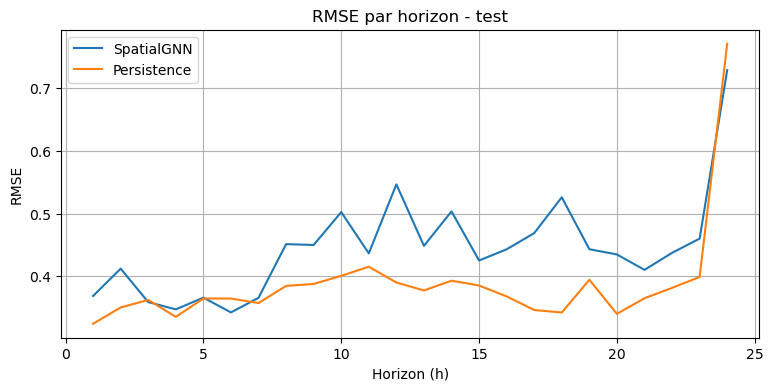

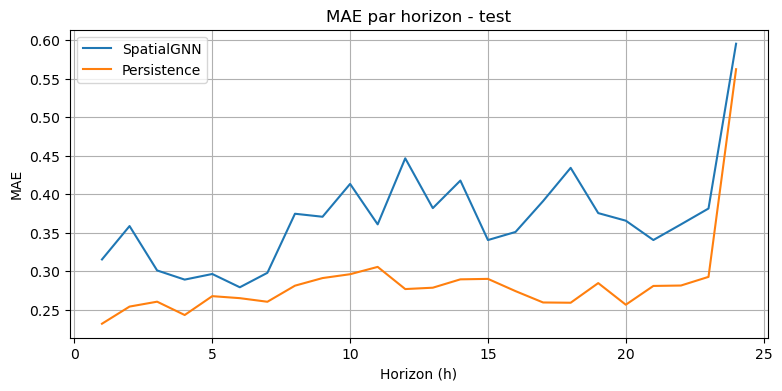

,h,MAE,RMSE,NMAE
0,1,0.315103,0.368225,0.340096
1,2,0.358466,0.411910,0.399158
2,3,0.300818,0.358401,0.322410
3,4,0.288925,0.346830,0.292698
4,5,0.296218,0.365569,0.277226


,h,MAE,RMSE,NMAE
0,1,0.231626,0.323881,0.249997
1,2,0.253892,0.349879,0.282713
2,3,0.260251,0.361862,0.278931
3,4,0.242932,0.334815,0.246104
4,5,0.267440,0.364148,0.250293


In [27]:
# ============================================================
# Cellule - Plots / métriques par horizon
# ============================================================
assert "test_out" in globals(), "test_out n'existe pas. Relance d'abord la cellule collect_predictions."
assert "pers_test_true" in globals(), "pers_test_true n'existe pas. Relance d'abord la cellule baseline."
assert "pers_test_pred" in globals(), "pers_test_pred n'existe pas. Relance d'abord la cellule baseline."

def per_horizon_metrics(y_true, y_pred):
    y_true_3d = ensure_3d_output(
        y_true,
        n_wells=len(CONFIG["WELL_IDX"]),
        horizon=CONFIG["HORIZON_HOURS"],
    )
    y_pred_3d = ensure_3d_output(
        y_pred,
        n_wells=len(CONFIG["WELL_IDX"]),
        horizon=CONFIG["HORIZON_HOURS"],
    )

    rows = []
    for h in range(CONFIG["HORIZON_HOURS"]):
        m = mae_rmse_nmae(y_true_3d[:, :, h], y_pred_3d[:, :, h])
        rows.append({"h": h + 1, **m})
    return pd.DataFrame(rows)


test_horizon_df = per_horizon_metrics(test_out["trues_real"], test_out["preds_real"])
pers_test_horizon_df = per_horizon_metrics(pers_test_true, pers_test_pred)

plt.figure(figsize=(9, 4))
plt.plot(test_horizon_df["h"], test_horizon_df["RMSE"], label="SpatialGNN")
plt.plot(pers_test_horizon_df["h"], pers_test_horizon_df["RMSE"], label="Persistence")
plt.xlabel("Horizon (h)")
plt.ylabel("RMSE")
plt.title("RMSE par horizon - test")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(test_horizon_df["h"], test_horizon_df["MAE"], label="SpatialGNN")
plt.plot(pers_test_horizon_df["h"], pers_test_horizon_df["MAE"], label="Persistence")
plt.xlabel("Horizon (h)")
plt.ylabel("MAE")
plt.title("MAE par horizon - test")
plt.grid(True)
plt.legend()
plt.show()

display(test_horizon_df.head())
display(pers_test_horizon_df.head())

In [28]:
# ============================================================
# Cellule - Reconstruction continue test (true_cont / pred_cont)
# ============================================================

T        = len(ts_g)
N_WELLS  = len(CONFIG["WELL_IDX"])

true_cont = np.full((T, N_WELLS), np.nan)
pred_cont = np.full((T, N_WELLS), np.nan)

# test_out["metas"] = target_start_idx pour chaque fenêtre de test [N_windows]
# test_out["preds_real"] shape [N_windows * 4, HOR] -> [N_windows, 4, HOR]
preds_3d = ensure_3d_output(test_out["preds_real"], n_wells=N_WELLS, horizon=HOR)
metas    = test_out["metas"]

assert metas is not None, "metas est None : vérifie que target_start_idx est bien stocké dans le dataset."
assert len(metas) == len(preds_3d), (
    f"Incohérence : {len(metas)} metas vs {len(preds_3d)} fenêtres de prédiction"
)

for k, ts0 in enumerate(metas):
    ts0 = int(ts0)
    for j in range(N_WELLS):
        true_cont[ts0 : ts0 + HOR, j] = g_full[ts0 : ts0 + HOR, j]
        pred_cont[ts0 : ts0 + HOR, j] = preds_3d[k, j, :]

n_valid = int(np.sum(np.any(~np.isnan(true_cont), axis=1)))
print(f"Reconstruction continue : {n_valid} heures valides sur {T}")
print(f"true_cont.shape = {true_cont.shape}")
print(f"pred_cont.shape = {pred_cont.shape}")

Reconstruction continue : 1464 heures valides sur 8784
true_cont.shape = (8784, 4)
pred_cont.shape = (8784, 4)


Zoom 72h de 2024-11-01 00:00:00 à 2024-11-03 23:00:00


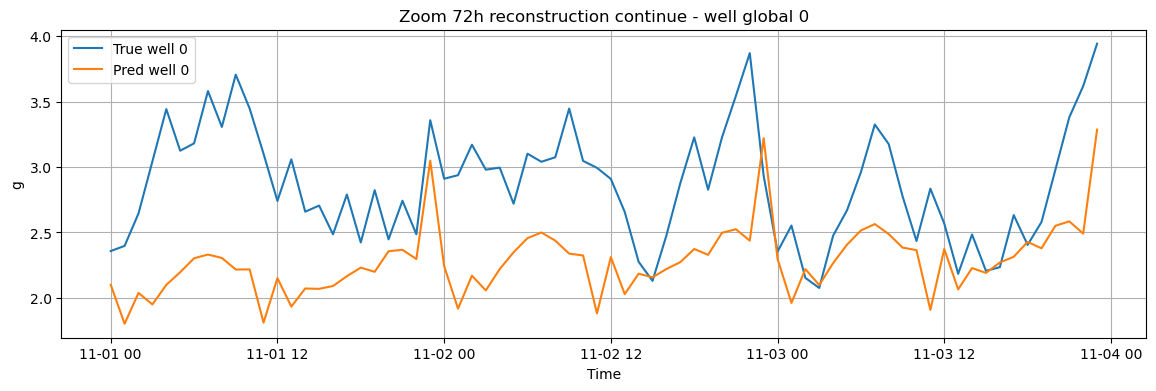

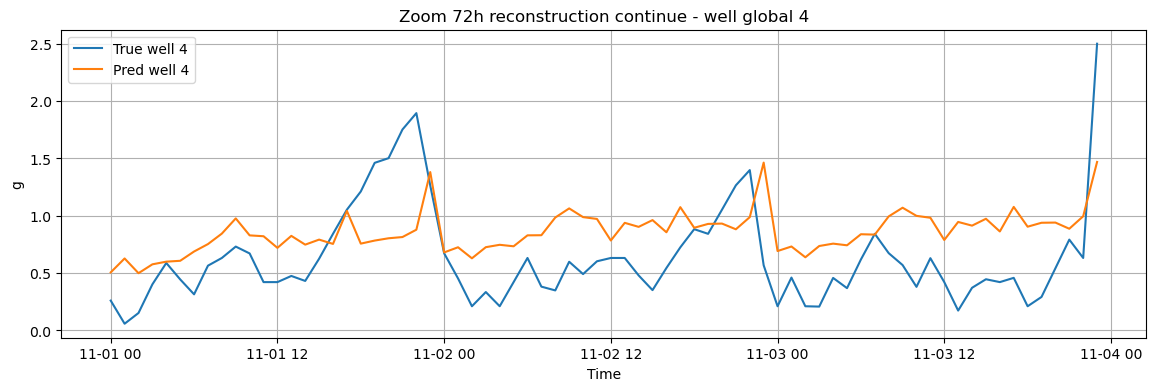

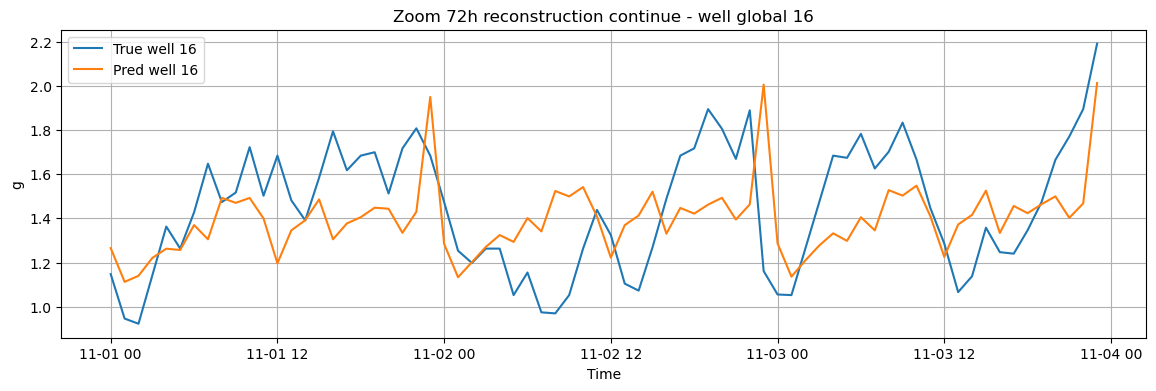

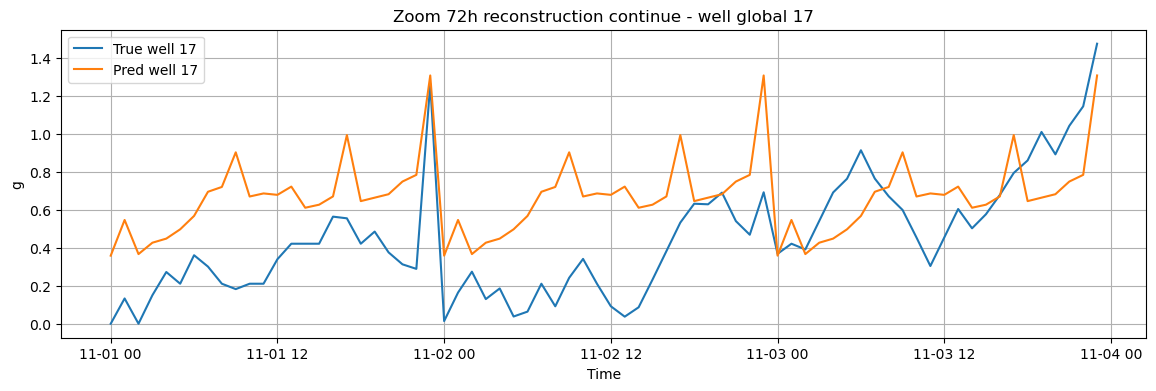

In [29]:
# ============================================================
# Cellule - Zoom 72h sur la reconstruction continue test
# ============================================================
N_ZOOM = 72  # 72 heures
valid_hours_mask = np.any(~np.isnan(true_cont), axis=1)
valid_idx = np.where(valid_hours_mask)[0]

assert len(valid_idx) > 0, "Aucune heure valide dans la reconstruction continue"

# début du premier segment valide
start_plot = valid_idx[0]
end_plot = min(start_plot + N_ZOOM, len(ts_g))

print("Zoom 72h de", ts_g[start_plot], "à", ts_g[end_plot - 1])

for j, w in enumerate(CONFIG["WELL_IDX"]):
    plt.figure(figsize=(14, 4))
    plt.plot(
        ts_g[start_plot:end_plot],
        true_cont[start_plot:end_plot, j],
        label=f"True well {w}",
    )
    plt.plot(
        ts_g[start_plot:end_plot],
        pred_cont[start_plot:end_plot, j],
        label=f"Pred well {w}",
    )
    plt.title(f"Zoom 72h reconstruction continue - well global {w}")
    plt.xlabel("Time")
    plt.ylabel("g")
    plt.grid(True)
    plt.legend()
    plt.show()

Zoom 72h de 2024-11-01 00:00:00 à 2024-11-03 23:00:00


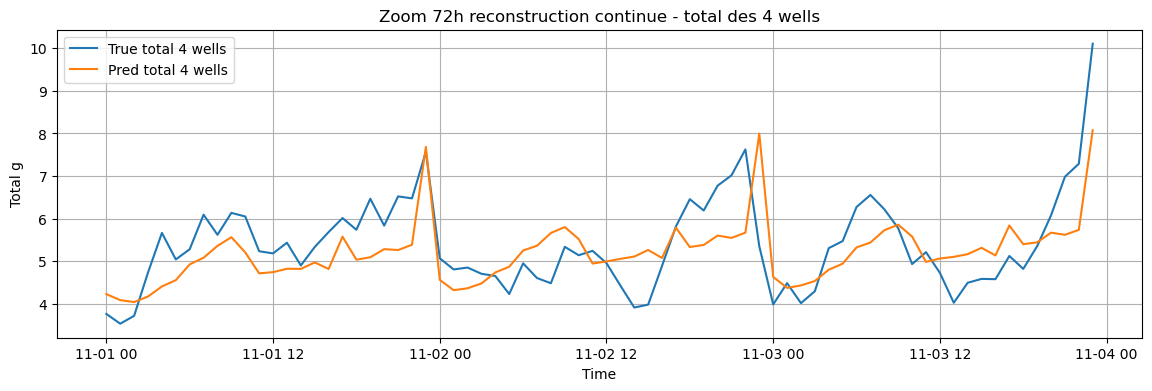

In [30]:
# ============================================================
# Cellule - Zoom 72h sur le total des 4 wells
# ============================================================
N_ZOOM = 72  # 72 heures

# on garde les heures où au moins un well a une valeur reconstruite
valid_hours_mask = np.any(~np.isnan(true_cont), axis=1)
valid_idx = np.where(valid_hours_mask)[0]

assert len(valid_idx) > 0, "Aucune heure valide dans la reconstruction continue"

start_plot = valid_idx[0]
end_plot = min(start_plot + N_ZOOM, len(ts_g))

print("Zoom 72h de", ts_g[start_plot], "à", ts_g[end_plot - 1])

# Somme sur les 4 wells
true_total_72h = np.nansum(true_cont[start_plot:end_plot, :], axis=1)
pred_total_72h = np.nansum(pred_cont[start_plot:end_plot, :], axis=1)

plt.figure(figsize=(14, 4))
plt.plot(
    ts_g[start_plot:end_plot],
    true_total_72h,
    label="True total 4 wells",
)
plt.plot(
    ts_g[start_plot:end_plot],
    pred_total_72h,
    label="Pred total 4 wells",
)
plt.title("Zoom 72h reconstruction continue - total des 4 wells")
plt.xlabel("Time")
plt.ylabel("Total g")
plt.grid(True)
plt.legend()
plt.show()

In [31]:
# ============================================================
# Cellule - Métriques sur les totaux agrégés
# ============================================================
def aggregated_total_metrics(true_arr, pred_arr, n_wells, horizon):
    true_3d = ensure_3d_output(true_arr, n_wells=n_wells, horizon=horizon)  # [N, W, H]
    pred_3d = ensure_3d_output(pred_arr, n_wells=n_wells, horizon=horizon)  # [N, W, H]

    assert true_3d.shape == pred_3d.shape, (
        f"Shape mismatch: true={true_3d.shape}, pred={pred_3d.shape}"
    )

    # Total agrégé sur les wells -> [N, H]
    true_total = np.sum(true_3d, axis=1)
    pred_total = np.sum(pred_3d, axis=1)

    # Erreur sur les totaux agrégés
    err_total = pred_total - true_total

    mae_total = np.mean(np.abs(err_total))
    rmse_total = np.sqrt(np.mean(err_total ** 2))
    std_error_total = np.std(err_total)
    mean_true_total = np.mean(np.abs(true_total))
    nmae_total = mae_total / (mean_true_total + 1e-12)

    metrics = {
        "MAE_total_agg": mae_total,
        "RMSE_total_agg": rmse_total,
        "STD_error_total_agg": std_error_total,
        "mean_abs_true_total_agg": mean_true_total,
        "NMAE_total_agg": nmae_total,
    }

    return metrics, true_total, pred_total, err_total


# -------- SpatialGNN --------
gnn_metrics_total, gnn_true_total, gnn_pred_total, gnn_err_total = aggregated_total_metrics(
    test_out["trues_real"],
    test_out["preds_real"],
    n_wells=len(CONFIG["WELL_IDX"]),
    horizon=CONFIG["HORIZON_HOURS"],
)

# -------- Baseline persistance --------
pers_metrics_total, pers_true_total, pers_pred_total, pers_err_total = aggregated_total_metrics(
    pers_test_true,
    pers_test_pred,
    n_wells=len(CONFIG["WELL_IDX"]),
    horizon=CONFIG["HORIZON_HOURS"],
)

df_total_metrics = pd.DataFrame([
    {"model": "SpatialGNN", **gnn_metrics_total},
    {"model": "Persistence", **pers_metrics_total},
])

display(df_total_metrics)

print("\n--- Détail SpatialGNN ---")
for k, v in gnn_metrics_total.items():
    print(f"{k}: {v:.6f}")

print("\n--- Détail Persistence ---")
for k, v in pers_metrics_total.items():
    print(f"{k}: {v:.6f}")

,model,MAE_total_agg,RMSE_total_agg,STD_error_total_agg,mean_abs_true_total_agg,NMAE_total_agg
0,SpatialGNN,0.762808,0.953360,0.940620,5.216006,0.146244
1,Persistence,0.641460,0.868651,0.868354,5.216006,0.122979



--- Détail SpatialGNN ---
MAE_total_agg: 0.762808
RMSE_total_agg: 0.953360
STD_error_total_agg: 0.940620
mean_abs_true_total_agg: 5.216006
NMAE_total_agg: 0.146244

--- Détail Persistence ---
MAE_total_agg: 0.641460
RMSE_total_agg: 0.868651
STD_error_total_agg: 0.868354
mean_abs_true_total_agg: 5.216006
NMAE_total_agg: 0.122979


=== GAZ ONLY | Global metrics on validation (g_total sur 4 wells) ===
MAE            : 0.643868
RMSE           : 0.830287
MAE/mean       : 0.135931
Roughness err  : 0.209458
Roughness true : 0.642459
Roughness pred : 0.433001


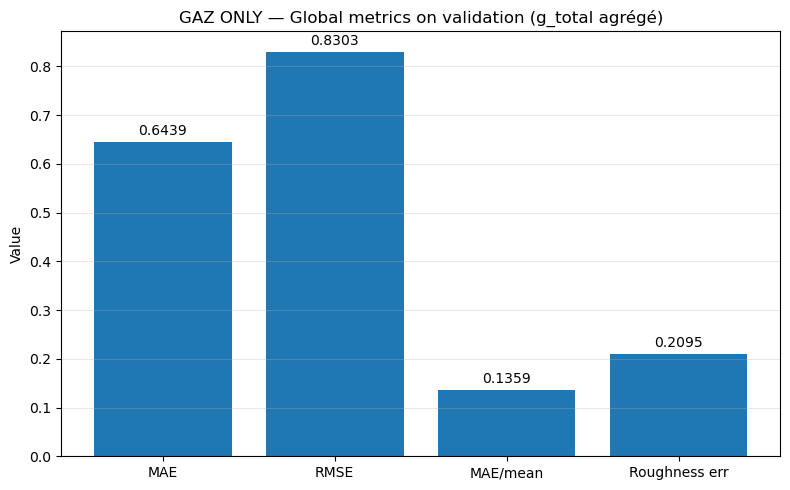

Figure saved to: C:\Users\yoans\TFE - GAZ\figures\global_metrics_gaz_only_val.png


In [32]:
# ============================================================
# Cellule — Global metrics plot | GAZ ONLY | VAL
# Adaptée au notebook spatial gaz GFPP
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def rmse(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def mae(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    return float(np.mean(np.abs(y_true - y_pred)))

def roughness(x):
    x = np.asarray(x).reshape(-1)
    if len(x) < 2:
        return 0.0
    return float(np.mean(np.abs(np.diff(x))))

# ------------------------------------------------------------
# Vérifications minimales
# ------------------------------------------------------------
assert "val_out" in globals(), "val_out introuvable. Lance d'abord la cellule qui collecte les prédictions."
assert "ensure_3d_output" in globals(), "ensure_3d_output introuvable."
assert "CONFIG" in globals(), "CONFIG introuvable."
assert "HOR" in globals(), "HOR introuvable."

# ------------------------------------------------------------
# Prédictions globales sur le set de validation
# val_out['preds_real'] et val_out['trues_real'] sont remis en
# shape [N_windows, N_WELLS, HOR]
# ------------------------------------------------------------
N_WELLS = len(CONFIG["WELL_IDX"])

pred_real_3d = ensure_3d_output(
    val_out["preds_real"],
    n_wells=N_WELLS,
    horizon=CONFIG["HORIZON_HOURS"],
)   # [N, W, H]

true_real_3d = ensure_3d_output(
    val_out["trues_real"],
    n_wells=N_WELLS,
    horizon=CONFIG["HORIZON_HOURS"],
)   # [N, W, H]

# ------------------------------------------------------------
# Total gaz agrégé sur les 4 wells
# Somme sur les wells -> [N, H], puis flatten
# ------------------------------------------------------------
g_pred_total = pred_real_3d.sum(axis=1).reshape(-1)
g_true_total = true_real_3d.sum(axis=1).reshape(-1)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------
metric_mae       = mae(g_true_total, g_pred_total)
metric_rmse      = rmse(g_true_total, g_pred_total)
metric_mae_mean  = metric_mae / (np.mean(np.abs(g_true_total)) + 1e-12)
rough_true       = roughness(g_true_total)
rough_pred       = roughness(g_pred_total)
metric_roughness = abs(rough_pred - rough_true)

metrics = {
    "MAE": metric_mae,
    "RMSE": metric_rmse,
    "MAE/mean": metric_mae_mean,
    "Roughness err": metric_roughness
}

print("=== GAZ ONLY | Global metrics on validation (g_total sur 4 wells) ===")
for k, v in metrics.items():
    print(f"{k:<15}: {v:.6f}")
print(f"{'Roughness true':<15}: {rough_true:.6f}")
print(f"{'Roughness pred':<15}: {rough_pred:.6f}")

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
names  = list(metrics.keys())
values = list(metrics.values())

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(names, values)

ax.set_title("GAZ ONLY — Global metrics on validation (g_total agrégé)")
ax.set_ylabel("Value")
ax.grid(True, axis="y", alpha=0.3)

ymax = max(values) if len(values) > 0 else 1.0
for b, v in zip(bars, values):
    ax.text(
        b.get_x() + b.get_width()/2,
        b.get_height() + 0.01 * ymax,
        f"{v:.4f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

fig.tight_layout()

# ------------------------------------------------------------
# Sauvegarde
# ------------------------------------------------------------
save_dir = CONFIG["BASE_DIR"] / "figures"
save_dir.mkdir(parents=True, exist_ok=True)

save_path = save_dir / "global_metrics_gaz_only_val.png"
fig.savefig(save_path, dpi=140, bbox_inches="tight")
plt.show()

print("Figure saved to:", save_path.resolve())

=== STD ANALYSIS | SpatialGasGNN | Validation ===
STD globale true                : 0.814778
STD globale pred                : 0.614981
Ratio pred/true globale         : 0.754784
-
STD totale agrégée true         : 1.179699
STD totale agrégée pred         : 0.729230
Ratio pred/true totale agrégée  : 0.618149

Wells les plus sous-variés (pred - true le plus négatif):
Well 01 | std_true=0.4318 | std_pred=0.1852 | diff=-0.2466
Well 00 | std_true=0.5057 | std_pred=0.2600 | diff=-0.2457
Well 02 | std_true=0.3096 | std_pred=0.1672 | diff=-0.1425
Well 03 | std_true=0.2985 | std_pred=0.1982 | diff=-0.1003

Wells les plus sur-variés (pred - true le plus positif):
Well 03 | std_true=0.2985 | std_pred=0.1982 | diff=-0.1003
Well 02 | std_true=0.3096 | std_pred=0.1672 | diff=-0.1425
Well 00 | std_true=0.5057 | std_pred=0.2600 | diff=-0.2457
Well 01 | std_true=0.4318 | std_pred=0.1852 | diff=-0.2466


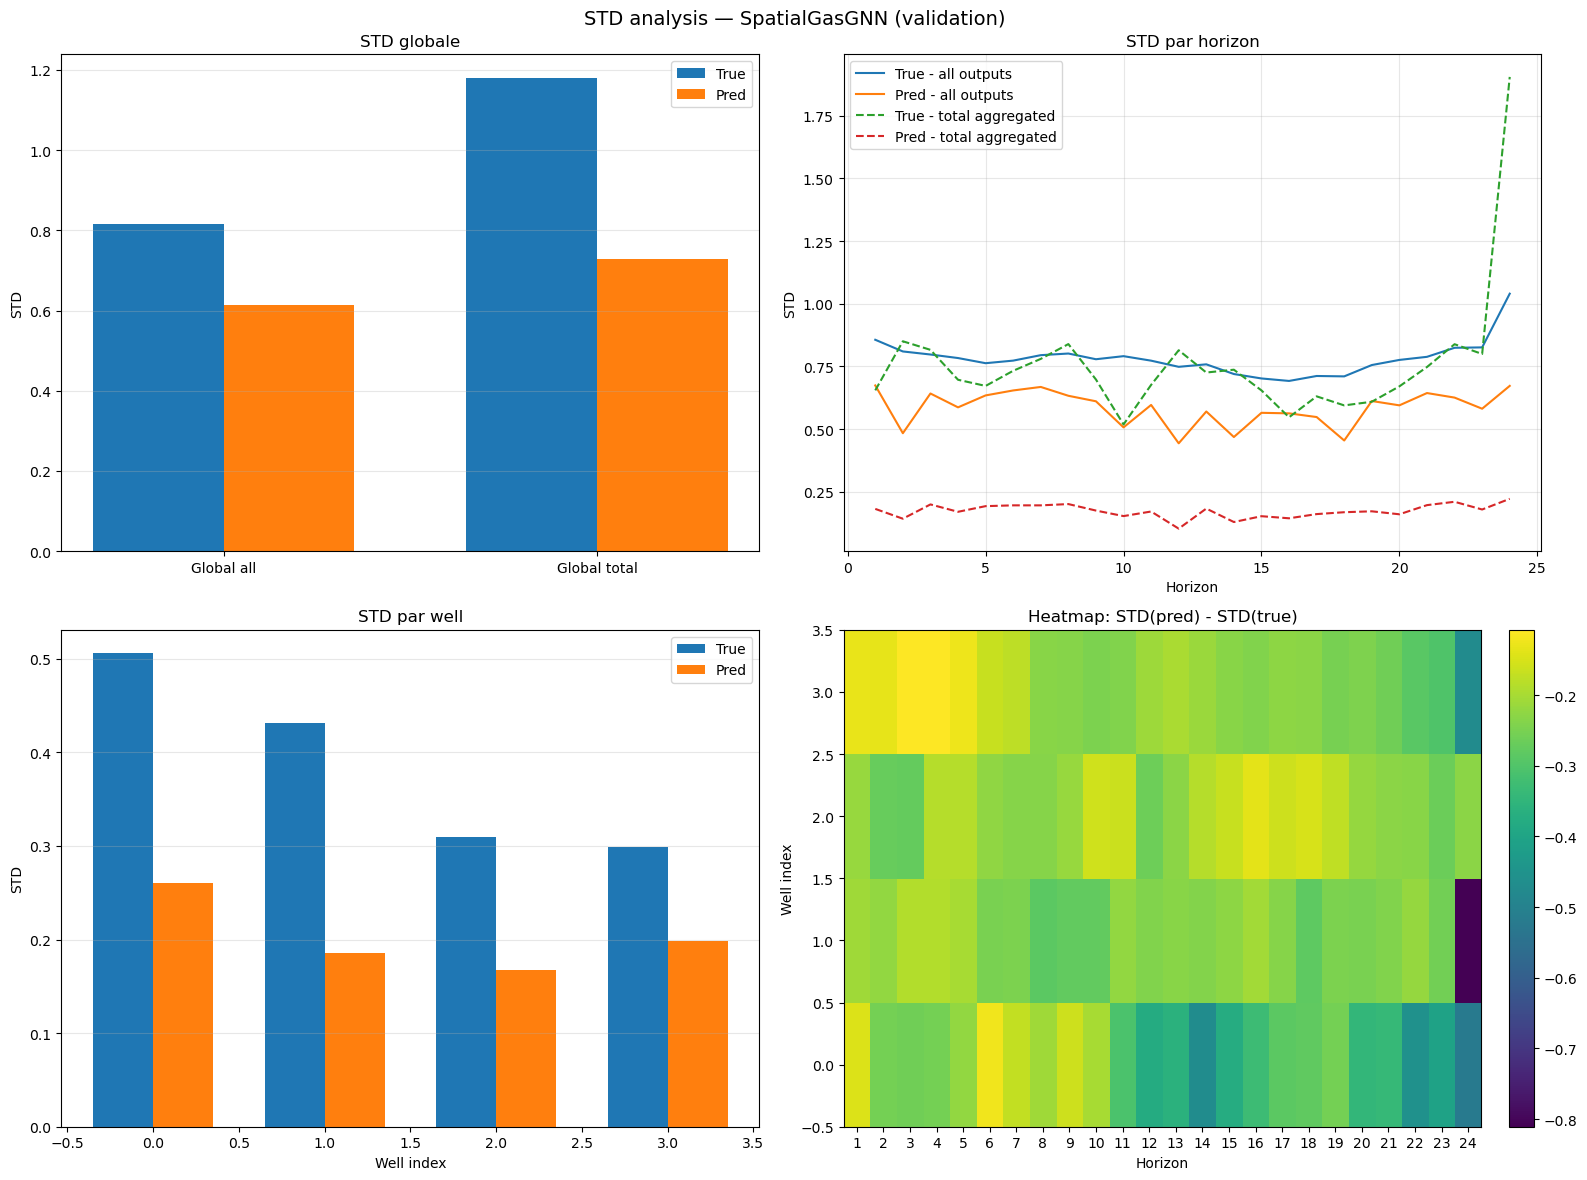

In [33]:
# ============================================================
# Cellule — STD analysis | VAL | SpatialGasGNN
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Vérifications
# ------------------------------------------------------------
assert "val_out" in globals(), "val_out introuvable."
assert "ensure_3d_output" in globals(), "ensure_3d_output introuvable."
assert "CONFIG" in globals(), "CONFIG introuvable."
assert "HOR" in globals(), "HOR introuvable."

N_WELLS = len(CONFIG["WELL_IDX"])

# ------------------------------------------------------------
# Mise en forme [N, N_WELLS, HOR]
# ------------------------------------------------------------
pred_3d = ensure_3d_output(
    val_out["preds_real"],
    n_wells=N_WELLS,
    horizon=CONFIG["HORIZON_HOURS"],
)

true_3d = ensure_3d_output(
    val_out["trues_real"],
    n_wells=N_WELLS,
    horizon=CONFIG["HORIZON_HOURS"],
)

# Convention:
# pred_3d / true_3d: [N_windows, N_WELLS, HOR]

# ------------------------------------------------------------
# 1) STD globale sur toutes les valeurs
# ------------------------------------------------------------
std_true_global = float(np.std(true_3d))
std_pred_global = float(np.std(pred_3d))

# ------------------------------------------------------------
# 2) STD du total gaz agrégé
# ------------------------------------------------------------
true_total = true_3d.sum(axis=1)   # [N, HOR]
pred_total = pred_3d.sum(axis=1)   # [N, HOR]

std_true_total_global = float(np.std(true_total))
std_pred_total_global = float(np.std(pred_total))

# ------------------------------------------------------------
# 3) STD par horizon
# ------------------------------------------------------------
std_true_h = np.std(true_3d, axis=(0, 1))   # [HOR]
std_pred_h = np.std(pred_3d, axis=(0, 1))   # [HOR]

std_true_total_h = np.std(true_total, axis=0)   # [HOR]
std_pred_total_h = np.std(pred_total, axis=0)   # [HOR]

# ------------------------------------------------------------
# 4) STD par well
# ------------------------------------------------------------
std_true_well = np.std(true_3d, axis=(0, 2))   # [N_WELLS]
std_pred_well = np.std(pred_3d, axis=(0, 2))   # [N_WELLS]

# ------------------------------------------------------------
# 5) Heatmap écart de STD par (well, horizon)
# ------------------------------------------------------------
std_true_well_h = np.std(true_3d, axis=0)   # [N_WELLS, HOR]
std_pred_well_h = np.std(pred_3d, axis=0)   # [N_WELLS, HOR]
std_diff_well_h = std_pred_well_h - std_true_well_h

# ------------------------------------------------------------
# Résumé texte
# ------------------------------------------------------------
print("=== STD ANALYSIS | SpatialGasGNN | Validation ===")
print(f"STD globale true                : {std_true_global:.6f}")
print(f"STD globale pred                : {std_pred_global:.6f}")
print(f"Ratio pred/true globale         : {std_pred_global / (std_true_global + 1e-12):.6f}")
print("-")
print(f"STD totale agrégée true         : {std_true_total_global:.6f}")
print(f"STD totale agrégée pred         : {std_pred_total_global:.6f}")
print(f"Ratio pred/true totale agrégée  : {std_pred_total_global / (std_true_total_global + 1e-12):.6f}")

well_diff = std_pred_well - std_true_well
most_under = np.argsort(well_diff)[:N_WELLS]
most_over  = np.argsort(well_diff)[-N_WELLS:]

print("\nWells les plus sous-variés (pred - true le plus négatif):")
for idx in most_under:
    print(
        f"Well {idx:02d} | std_true={std_true_well[idx]:.4f} | "
        f"std_pred={std_pred_well[idx]:.4f} | diff={well_diff[idx]:.4f}"
    )

print("\nWells les plus sur-variés (pred - true le plus positif):")
for idx in most_over[::-1]:
    print(
        f"Well {idx:02d} | std_true={std_true_well[idx]:.4f} | "
        f"std_pred={std_pred_well[idx]:.4f} | diff={well_diff[idx]:.4f}"
    )

# ------------------------------------------------------------
# Plots
# ------------------------------------------------------------
fig = plt.figure(figsize=(16, 12))

# --- Plot 1: barplot STD globales
ax1 = plt.subplot(2, 2, 1)
labels = ["Global all", "Global total"]
true_vals = [std_true_global, std_true_total_global]
pred_vals = [std_pred_global, std_pred_total_global]

x = np.arange(len(labels))
w = 0.35
ax1.bar(x - w/2, true_vals, width=w, label="True")
ax1.bar(x + w/2, pred_vals, width=w, label="Pred")
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_title("STD globale")
ax1.set_ylabel("STD")
ax1.grid(True, axis="y", alpha=0.3)
ax1.legend()

# --- Plot 2: STD par horizon
ax2 = plt.subplot(2, 2, 2)
h = np.arange(1, HOR + 1)
ax2.plot(h, std_true_h, label="True - all outputs")
ax2.plot(h, std_pred_h, label="Pred - all outputs")
ax2.plot(h, std_true_total_h, linestyle="--", label="True - total aggregated")
ax2.plot(h, std_pred_total_h, linestyle="--", label="Pred - total aggregated")
ax2.set_title("STD par horizon")
ax2.set_xlabel("Horizon")
ax2.set_ylabel("STD")
ax2.grid(True, alpha=0.3)
ax2.legend()

# --- Plot 3: STD par well
ax3 = plt.subplot(2, 2, 3)
wells = np.arange(N_WELLS)
ax3.bar(wells - w/2, std_true_well, width=w, label="True")
ax3.bar(wells + w/2, std_pred_well, width=w, label="Pred")
ax3.set_title("STD par well")
ax3.set_xlabel("Well index")
ax3.set_ylabel("STD")
ax3.grid(True, axis="y", alpha=0.3)
ax3.legend()

# --- Plot 4: heatmap diff STD
ax4 = plt.subplot(2, 2, 4)
im = ax4.imshow(std_diff_well_h, aspect="auto", origin="lower")
ax4.set_title("Heatmap: STD(pred) - STD(true)")
ax4.set_xlabel("Horizon")
ax4.set_ylabel("Well index")
ax4.set_xticks(np.arange(HOR))
ax4.set_xticklabels(np.arange(1, HOR + 1))
fig.colorbar(im, ax=ax4, fraction=0.046, pad=0.04)

fig.suptitle("STD analysis — SpatialGasGNN (validation)", fontsize=14)
fig.tight_layout()
plt.show()

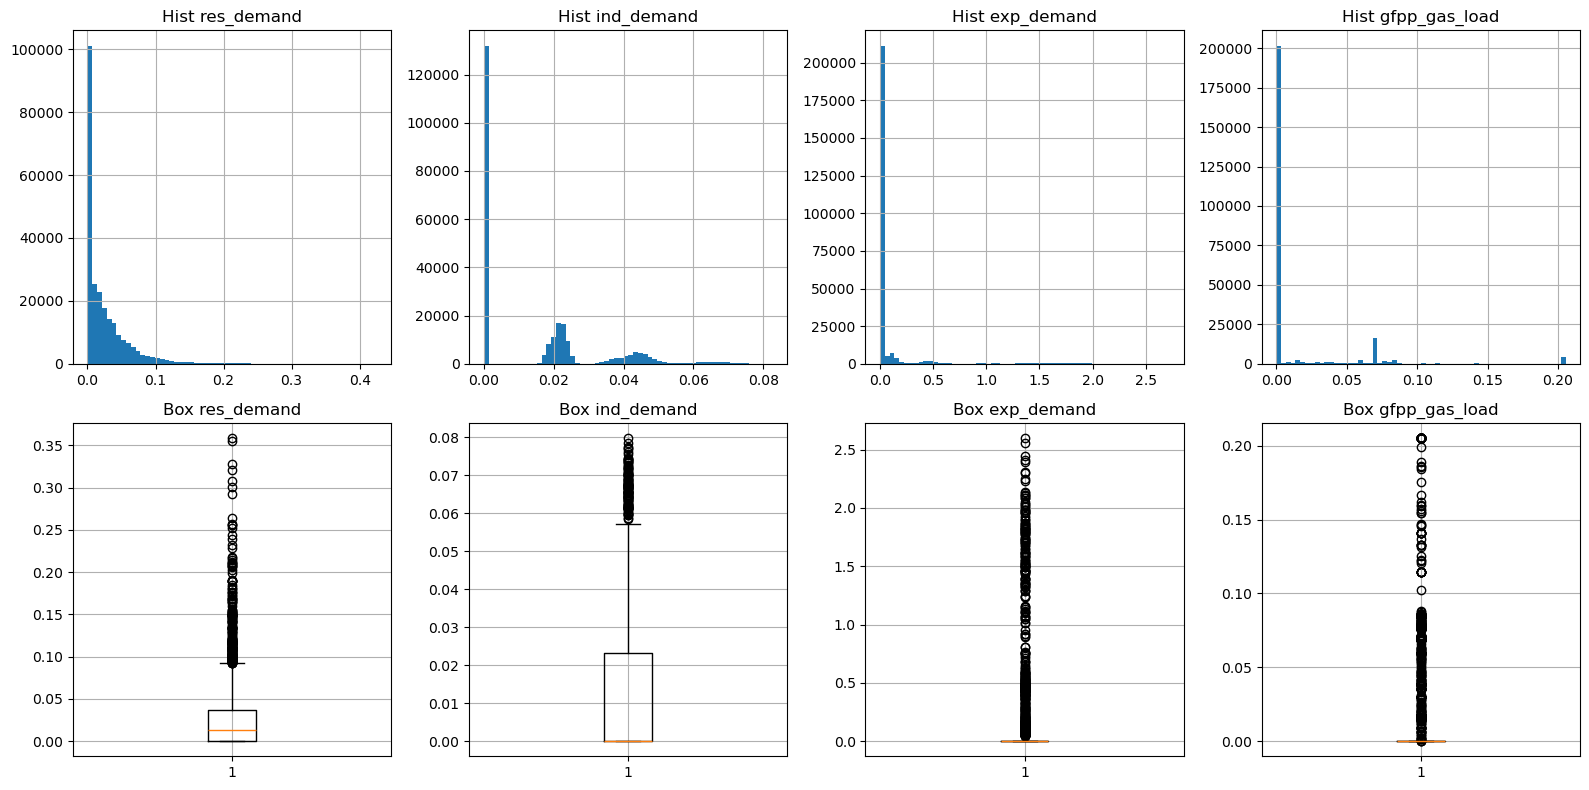

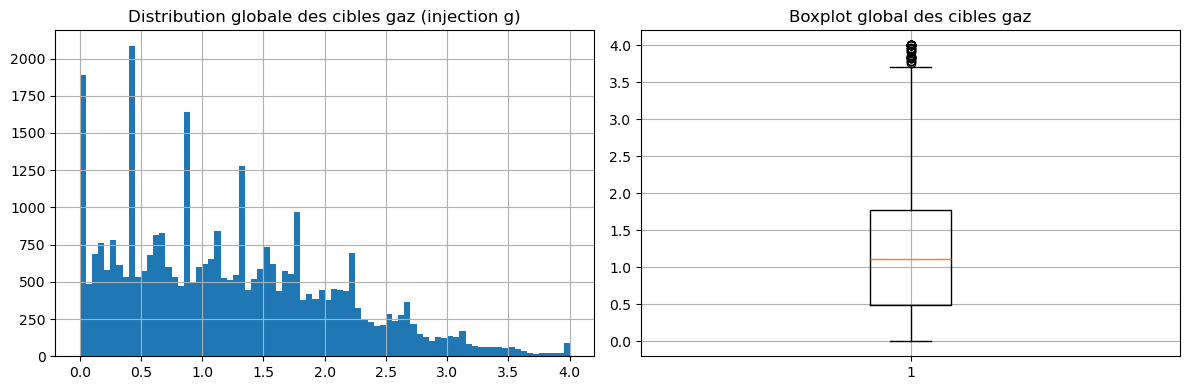

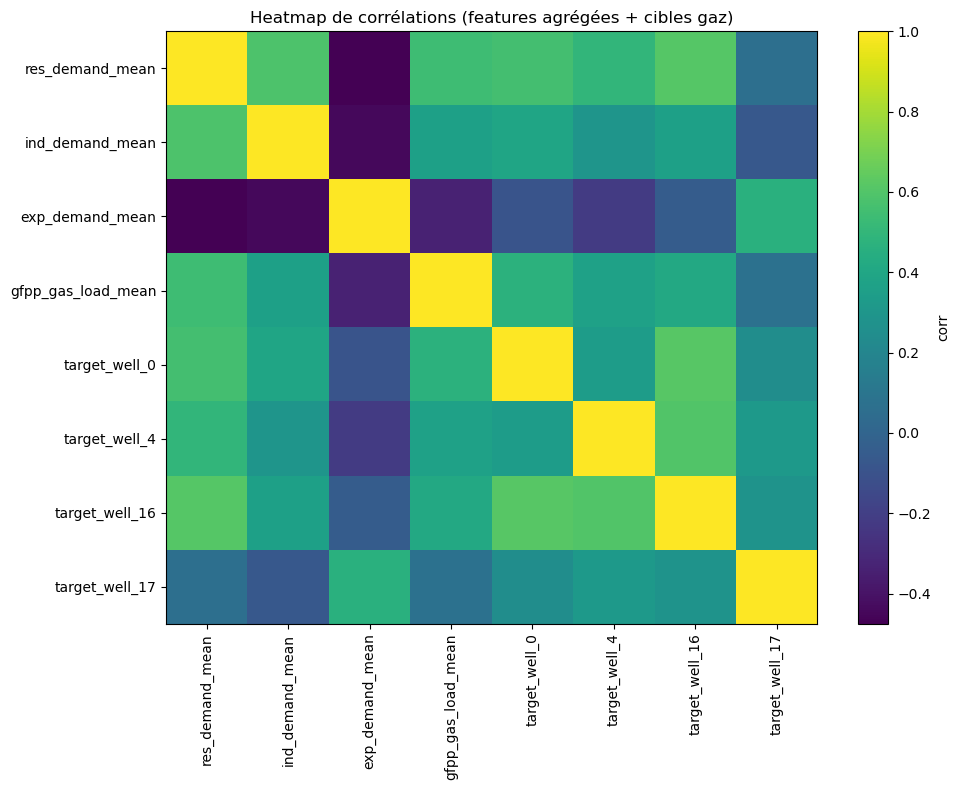

,count,mean,std,min,25%,50%,75%,max
res_demand_mean,8784.0,0.025620,0.016472,0.000003,0.011770,0.021516,0.036450,0.093601
ind_demand_mean,8784.0,0.014609,0.001432,0.010843,0.013607,0.014712,0.015628,0.018718
exp_demand_mean,8784.0,0.080931,0.020019,0.033393,0.068592,0.081365,0.093365,0.138794
gfpp_gas_load_mean,8784.0,0.013867,0.009992,0.000000,0.005681,0.013182,0.020623,0.034065
target_well_0,8784.0,2.321123,0.606402,0.407170,1.871573,2.246491,2.685126,4.000000
target_well_4,8784.0,0.735709,0.470367,0.000000,0.444444,0.673100,0.926635,2.500000
target_well_16,8784.0,1.420524,0.368363,0.187255,1.132067,1.408996,1.682243,2.200000
target_well_17,8784.0,0.427652,0.357381,0.000000,0.143841,0.372397,0.634397,1.500000


In [34]:
# ============================================================
# Cellule D3 - Distributions globales + boxplots + heatmap corr
# Sert à voir bruit, asymétrie, outliers, variables peu informatives
# ============================================================
assert "ts_g" in globals(), "Exécuter d'abord la cellule de construction des features dynamiques."

# ---------- sous-ensemble lisible ----------
n_feat_show = min(6, dyn_tensor.shape[-1])
feat_idx = np.arange(n_feat_show)
feat_names = dyn_feature_names[:n_feat_show] if dyn_feature_names is not None else [f"dyn_{i}" for i in feat_idx]

fig, axes = plt.subplots(2, n_feat_show, figsize=(4 * n_feat_show, 8))
for k, i in enumerate(feat_idx):
    vals = dyn_tensor[..., i].reshape(-1)
    vals = vals[np.isfinite(vals)]
    axes[0, k].hist(vals, bins=60)
    axes[0, k].set_title(f"Hist {feat_names[k]}")
    axes[0, k].grid(True)

    sample = vals[np.linspace(0, len(vals) - 1, min(4000, len(vals))).astype(int)] if len(vals) else np.array([])
    axes[1, k].boxplot(sample, vert=True)
    axes[1, k].set_title(f"Box {feat_names[k]}")
    axes[1, k].grid(True)

plt.tight_layout()
plt.show()

# ---------- cibles gaz (g_full) ----------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# À vérifier : g_full est le tenseur [T, N_WELLS] des injections gaz
target_vals = g_full.reshape(-1)
target_vals = target_vals[np.isfinite(target_vals)]

axes[0].hist(target_vals, bins=80)
axes[0].set_title("Distribution globale des cibles gaz (injection g)")
axes[0].grid(True)

sample_target = target_vals[np.linspace(0, len(target_vals) - 1, min(4000, len(target_vals))).astype(int)] if len(target_vals) else np.array([])
axes[1].boxplot(sample_target, vert=True)
axes[1].set_title("Boxplot global des cibles gaz")
axes[1].grid(True)

plt.tight_layout()
plt.show()

# ---------- heatmap corr sur sous-ensemble pertinent ----------
corr_dict = {}
for i in feat_idx:
    corr_dict[f"{feat_names[list(feat_idx).index(i)]}_mean"] = np.nanmean(dyn_tensor[:, :, i], axis=1)

# premières cibles wells
for j in range(min(6, g_full.shape[1])):
    # À vérifier : CONFIG["WELL_IDX"][j] est bien l'indice global du well j
    corr_dict[f"target_well_{CONFIG['WELL_IDX'][j]}"] = g_full[:, j]

corr_df = pd.DataFrame(corr_dict)
corr_mat = corr_df.corr(numeric_only=True).values

plt.figure(figsize=(10, 8))
plt.imshow(corr_mat, aspect="auto")
plt.colorbar(label="corr")
plt.xticks(range(len(corr_df.columns)), corr_df.columns, rotation=90)
plt.yticks(range(len(corr_df.columns)), corr_df.columns)
plt.title("Heatmap de corrélations (features agrégées + cibles gaz)")
plt.tight_layout()
plt.show()

display(corr_df.describe().T)

,horizon_h,model_MAE,model_RMSE,baseline_MAE,baseline_RMSE,RMSE_gain_vs_baseline_%
0,1,0.315103,0.368225,0.231626,0.323881,-13.691515
1,2,0.358466,0.411910,0.253892,0.349879,-17.729348
2,3,0.300818,0.358401,0.260251,0.361862,0.956325
3,4,0.288925,0.346830,0.242932,0.334815,-3.588504
4,5,0.296218,0.365569,0.267440,0.364148,-0.390001
5,6,0.278956,0.341935,0.264823,0.364127,6.094447
6,7,0.297737,0.365313,0.260153,0.356895,-2.358448
7,8,0.374469,0.451024,0.281035,0.384336,-17.351636
8,9,0.370562,0.449730,0.290920,0.387442,-16.076636
9,10,0.413218,0.502235,0.295926,0.400355,-25.447360


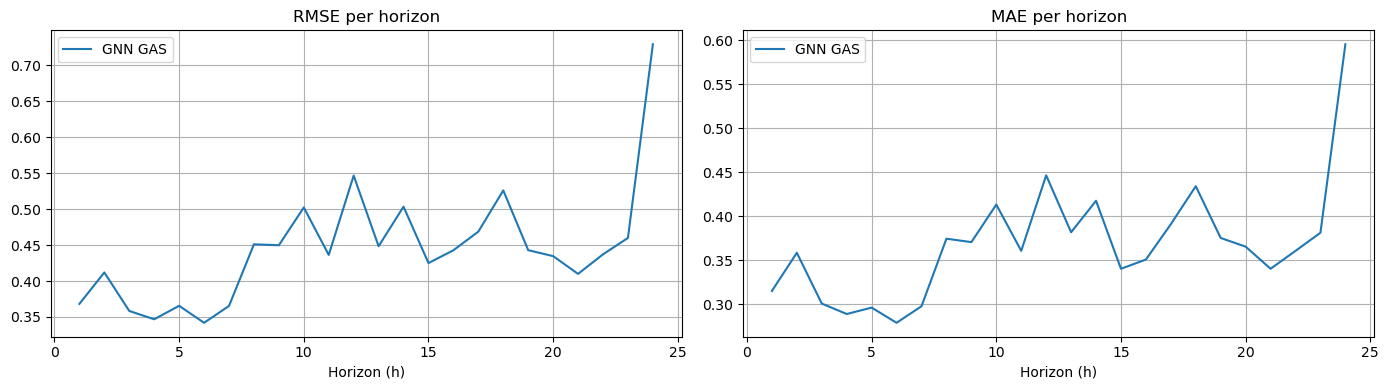

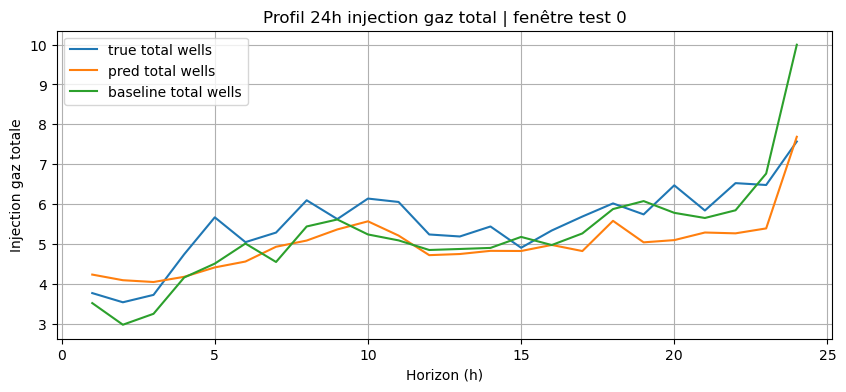

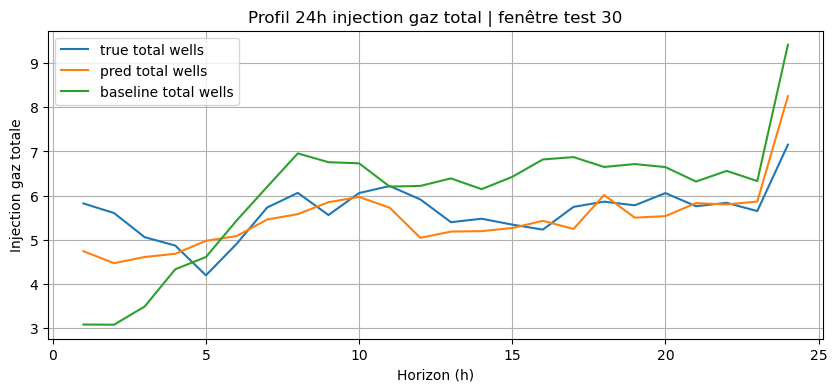

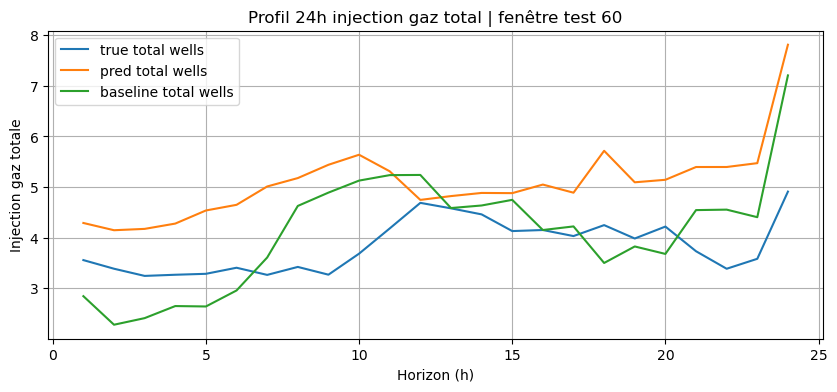

In [35]:
# ============================================================
# Cellule D11 - Analyse par horizon
# MAE/RMSE par horizon + comparaison baseline
# ============================================================
# À vérifier : définir N_WELLS_, HOR_, test_out_, pers_test_pred_, pers_test_true_
N_WELLS_ = len(CONFIG["WELL_IDX"])
HOR_      = CONFIG["HORIZON_HOURS"]

assert "test_out" in globals(), "test_out introuvable."
test_out_      = test_out
pers_test_pred_ = pers_test_pred
pers_test_true_ = pers_test_true

def _to_3d_pred(arr, n_wells, hor):
    arr = np.asarray(arr)
    if arr.ndim == 3:
        return arr
    if arr.ndim == 2:
        return arr.reshape(arr.shape[0] // n_wells, n_wells, hor)
    raise ValueError(f"Cannot reshape ndim={arr.ndim}")

y_true3 = _to_3d_pred(test_out_["trues_real"], N_WELLS_, HOR_)
y_pred3 = _to_3d_pred(test_out_["preds_real"], N_WELLS_, HOR_)
b_true3 = _to_3d_pred(pers_test_true_, N_WELLS_, HOR_)
b_pred3 = _to_3d_pred(pers_test_pred_, N_WELLS_, HOR_)

def _mae_rmse(a, b):
    a, b = np.asarray(a).ravel(), np.asarray(b).ravel()
    mae  = float(np.mean(np.abs(a - b)))
    rmse = float(np.sqrt(np.mean((a - b) ** 2)))
    return {"MAE": mae, "RMSE": rmse}

rows = []
for h in range(HOR_):
    m = _mae_rmse(y_true3[:, :, h], y_pred3[:, :, h])
    b = _mae_rmse(b_true3[:, :, h], b_pred3[:, :, h])
    rows.append({
        "horizon_h": h + 1,
        "model_MAE": m["MAE"],
        "model_RMSE": m["RMSE"],
        "baseline_MAE": b["MAE"],
        "baseline_RMSE": b["RMSE"],
        "RMSE_gain_vs_baseline_%": 100 * (b["RMSE"] - m["RMSE"]) / (b["RMSE"] + 1e-12),
    })
horizon_df = pd.DataFrame(rows)
display(horizon_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(horizon_df["horizon_h"], horizon_df["model_RMSE"], label="GNN GAS")
axes[0].set_title("RMSE per horizon")
axes[0].set_xlabel("Horizon (h)")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(horizon_df["horizon_h"], horizon_df["model_MAE"], label="GNN GAS")
axes[1].set_title("MAE per horizon")
axes[1].set_xlabel("Horizon (h)")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

# quelques prédictions complètes sur 24h (total agrégé des wells)
sel = np.linspace(0, len(y_true3) - 1, min(3, len(y_true3))).astype(int)
for k in sel:
    true_tot = np.sum(y_true3[k], axis=0)
    pred_tot = np.sum(y_pred3[k], axis=0)
    base_tot = np.sum(b_pred3[k], axis=0)

    plt.figure(figsize=(10, 4))
    plt.plot(np.arange(1, HOR_ + 1), true_tot, label="true total wells")
    plt.plot(np.arange(1, HOR_ + 1), pred_tot, label="pred total wells")
    plt.plot(np.arange(1, HOR_ + 1), base_tot, label="baseline total wells")
    plt.title(f"Profil 24h injection gaz total | fenêtre test {k}")
    plt.xlabel("Horizon (h)")
    plt.ylabel("Injection gaz totale")
    plt.grid(True)
    plt.legend()
    plt.show()

,well_local_idx,well_global_idx,MAE,RMSE,mean_abs_target,NMAE,std_true,std_pred,std_ratio_pred_true
0,0,0,0.417270,0.527989,2.569704,0.162380,0.512241,0.273383,0.533700
3,3,17,0.456504,0.509853,0.224024,2.037751,0.250203,0.198261,0.792399
1,1,4,0.319000,0.402291,0.921857,0.346040,0.460088,0.176972,0.384649
2,2,16,0.279775,0.340575,1.500422,0.186464,0.367491,0.171772,0.467417


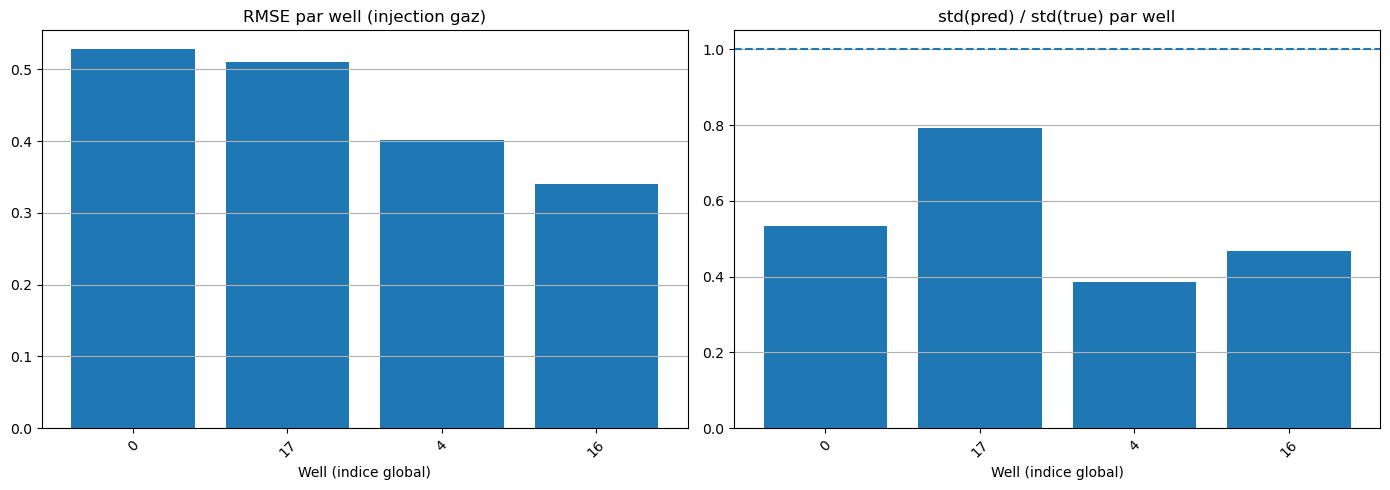

Pires wells (injection gaz) :


,well_local_idx,well_global_idx,MAE,RMSE,mean_abs_target,NMAE,std_true,std_pred,std_ratio_pred_true
0,0,0,0.417270,0.527989,2.569704,0.162380,0.512241,0.273383,0.533700
3,3,17,0.456504,0.509853,0.224024,2.037751,0.250203,0.198261,0.792399
1,1,4,0.319000,0.402291,0.921857,0.346040,0.460088,0.176972,0.384649
2,2,16,0.279775,0.340575,1.500422,0.186464,0.367491,0.171772,0.467417


In [36]:
# ============================================================
# Cellule D12 - Analyse par well / variable cible gaz
# métriques par well, pires sorties, erreur relative aux pics
# ============================================================
assert "test_out" in globals(), "test_out introuvable."

N_WELLS_ = len(CONFIG["WELL_IDX"])
HOR_      = CONFIG["HORIZON_HOURS"]

def _to_3d_pred(arr, n_wells, hor):
    arr = np.asarray(arr)
    if arr.ndim == 3:
        return arr
    if arr.ndim == 2:
        return arr.reshape(arr.shape[0] // n_wells, n_wells, hor)
    raise ValueError(f"Cannot reshape ndim={arr.ndim}")

def _mae_rmse(a, b):
    a, b = np.asarray(a).ravel(), np.asarray(b).ravel()
    return {
        "MAE": float(np.mean(np.abs(a - b))),
        "RMSE": float(np.sqrt(np.mean((a - b) ** 2))),
    }

y_true3 = _to_3d_pred(test_out["trues_real"], N_WELLS_, HOR_)
y_pred3 = _to_3d_pred(test_out["preds_real"], N_WELLS_, HOR_)

rows = []
for j in range(N_WELLS_):
    yt = y_true3[:, j, :]
    yp = y_pred3[:, j, :]
    m = _mae_rmse(yt, yp)
    rows.append({
        "well_local_idx": j,
        "well_global_idx": CONFIG["WELL_IDX"][j],
        "MAE": m["MAE"],
        "RMSE": m["RMSE"],
        "mean_abs_target": float(np.mean(np.abs(yt))),
        "NMAE": float(m["MAE"] / (np.mean(np.abs(yt)) + 1e-12)),
        "std_true": float(np.std(yt)),
        "std_pred": float(np.std(yp)),
        "std_ratio_pred_true": float(np.std(yp) / (np.std(yt) + 1e-12)),
    })
node_df = pd.DataFrame(rows).sort_values("RMSE", ascending=False)
display(node_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(node_df["well_global_idx"].astype(str), node_df["RMSE"])
axes[0].set_title("RMSE par well (injection gaz)")
axes[0].set_xlabel("Well (indice global)")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(True, axis="y")

axes[1].bar(node_df["well_global_idx"].astype(str), node_df["std_ratio_pred_true"])
axes[1].axhline(1.0, linestyle="--")
axes[1].set_title("std(pred) / std(true) par well")
axes[1].set_xlabel("Well (indice global)")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(True, axis="y")

plt.tight_layout()
plt.show()

print("Pires wells (injection gaz) :")
display(node_df.head(10))

,threshold_abs_y_95pct,MAE_normal_values,MAE_extreme_values,extreme_over_normal_ratio
0,3.008347,0.346124,0.786086,2.271112


,window_idx,well_local_idx,well_global_idx,horizon_h,y_true,y_pred,abs_error
0,53,0,0,24,0.940040,3.189079,2.249039
1,51,0,0,24,1.282822,3.274023,1.991201
2,35,0,0,24,1.619290,3.336304,1.717014
3,8,0,0,15,3.937902,2.282976,1.654926
4,42,0,0,12,3.579126,1.937379,1.641746
5,8,0,0,14,3.674119,2.111107,1.563012
6,32,0,0,12,3.478321,1.927979,1.550342
7,41,0,0,14,3.638613,2.098806,1.539806
8,49,0,0,24,1.794834,3.334522,1.539688
9,5,0,0,12,3.461073,1.941319,1.519754


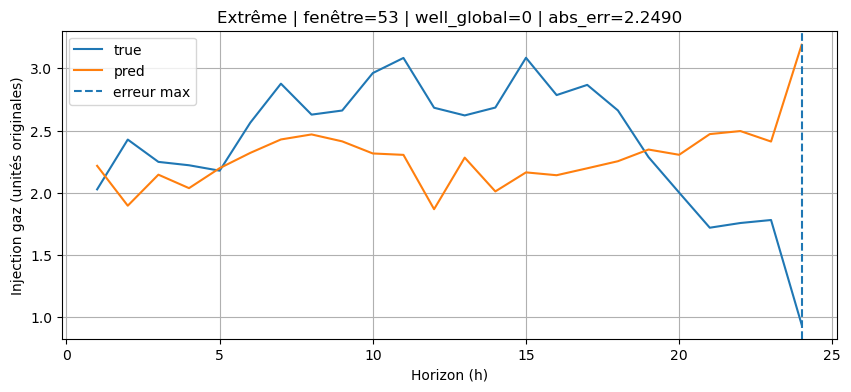

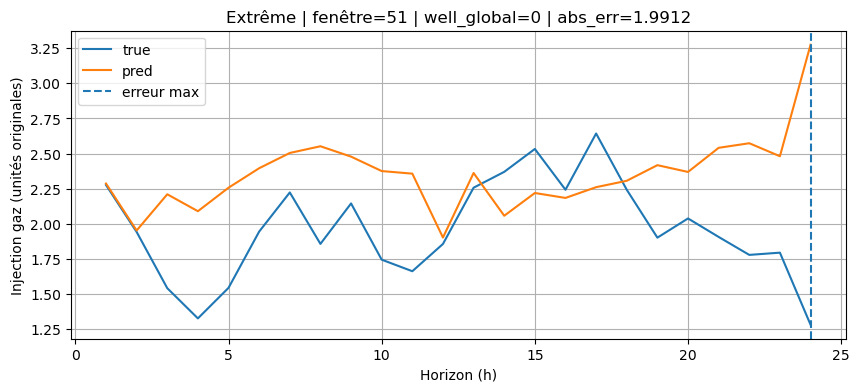

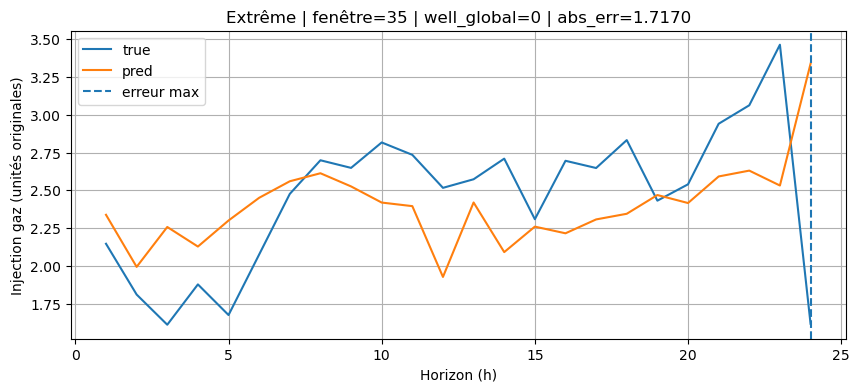

In [37]:
# ============================================================
# Cellule D13 - Analyse des extrêmes
# erreurs sur pics d'injection / valeurs normales + top erreurs
# ============================================================
assert "test_out" in globals(), "test_out introuvable."

N_WELLS_ = len(CONFIG["WELL_IDX"])
HOR_      = CONFIG["HORIZON_HOURS"]

def _to_3d_pred(arr, n_wells, hor):
    arr = np.asarray(arr)
    if arr.ndim == 3:
        return arr
    if arr.ndim == 2:
        return arr.reshape(arr.shape[0] // n_wells, n_wells, hor)
    raise ValueError(f"Cannot reshape ndim={arr.ndim}")

y_true3 = _to_3d_pred(test_out["trues_real"], N_WELLS_, HOR_)
y_pred3 = _to_3d_pred(test_out["preds_real"], N_WELLS_, HOR_)
abs_err = np.abs(y_pred3 - y_true3)

thr = np.nanpercentile(np.abs(y_true3), 95)
mask_extreme = np.abs(y_true3) >= thr
mask_normal  = np.abs(y_true3) < thr

extreme_mae = float(np.mean(abs_err[mask_extreme])) if np.any(mask_extreme) else np.nan
normal_mae  = float(np.mean(abs_err[mask_normal])) if np.any(mask_normal) else np.nan

summary_ext_df = pd.DataFrame([{
    "threshold_abs_y_95pct": thr,
    "MAE_normal_values": normal_mae,
    "MAE_extreme_values": extreme_mae,
    "extreme_over_normal_ratio": extreme_mae / (normal_mae + 1e-12)
}])
display(summary_ext_df)

# top erreurs ponctuelles
flat_idx = np.argsort(abs_err.reshape(-1))[-20:]
n_win, n_wells, n_hor = y_true3.shape
coords = np.array(np.unravel_index(flat_idx, (n_win, n_wells, n_hor))).T

rows = []
for w, j, h in coords[::-1]:
    rows.append({
        "window_idx": int(w),
        "well_local_idx": int(j),
        "well_global_idx": int(CONFIG["WELL_IDX"][j]),
        "horizon_h": int(h + 1),
        "y_true": float(y_true3[w, j, h]),
        "y_pred": float(y_pred3[w, j, h]),
        "abs_error": float(abs_err[w, j, h]),
    })
top_err_df = pd.DataFrame(rows)
display(top_err_df)

# visualisation des 3 plus gros échecs
for _, r in top_err_df.head(3).iterrows():
    w = int(r["window_idx"])
    j = int(r["well_local_idx"])
    plt.figure(figsize=(10, 4))
    plt.plot(np.arange(1, HOR_ + 1), y_true3[w, j], label="true")
    plt.plot(np.arange(1, HOR_ + 1), y_pred3[w, j], label="pred")
    plt.axvline(int(r["horizon_h"]), linestyle="--", label="erreur max")
    plt.title(
        f"Extrême | fenêtre={w} | well_global={CONFIG['WELL_IDX'][j]} | "
        f"abs_err={r['abs_error']:.4f}"
    )
    plt.xlabel("Horizon (h)")
    plt.ylabel("Injection gaz (unités originales)")
    plt.grid(True)
    plt.legend()
    plt.show()

GIANT DIAGNOSTIC CELL — GNN Spatial Gas

--- SECTION 1: Learning curves ---


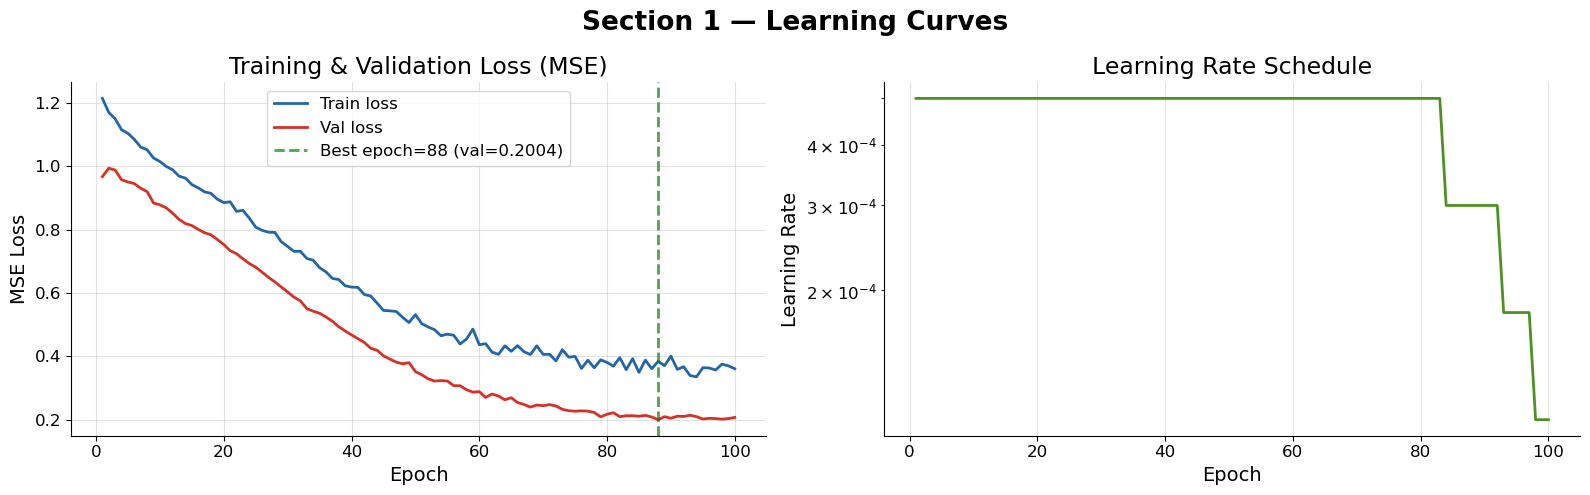

  Total epochs run      : 100
  Best epoch (val)      : 88  →  val_loss = 0.20039
  Final train loss      : 0.36097
  Final val   loss      : 0.20752
  Final gap (val-train) : -0.15346
  → Val loss stagnates after epoch 88 while train keeps decreasing.
    Overfitting signal: model memorizes train without generalizing.

--- SECTION 2: Global prediction quality per split ---
Split    MAE   RMSE     R2  std_pred/true    Bias
train 0.3370 0.4265 0.7438         0.6980 -0.0030
  val 0.2963 0.3778 0.7850         0.7548  0.0467
 test 0.3681 0.4518 0.7747         0.7279  0.0388


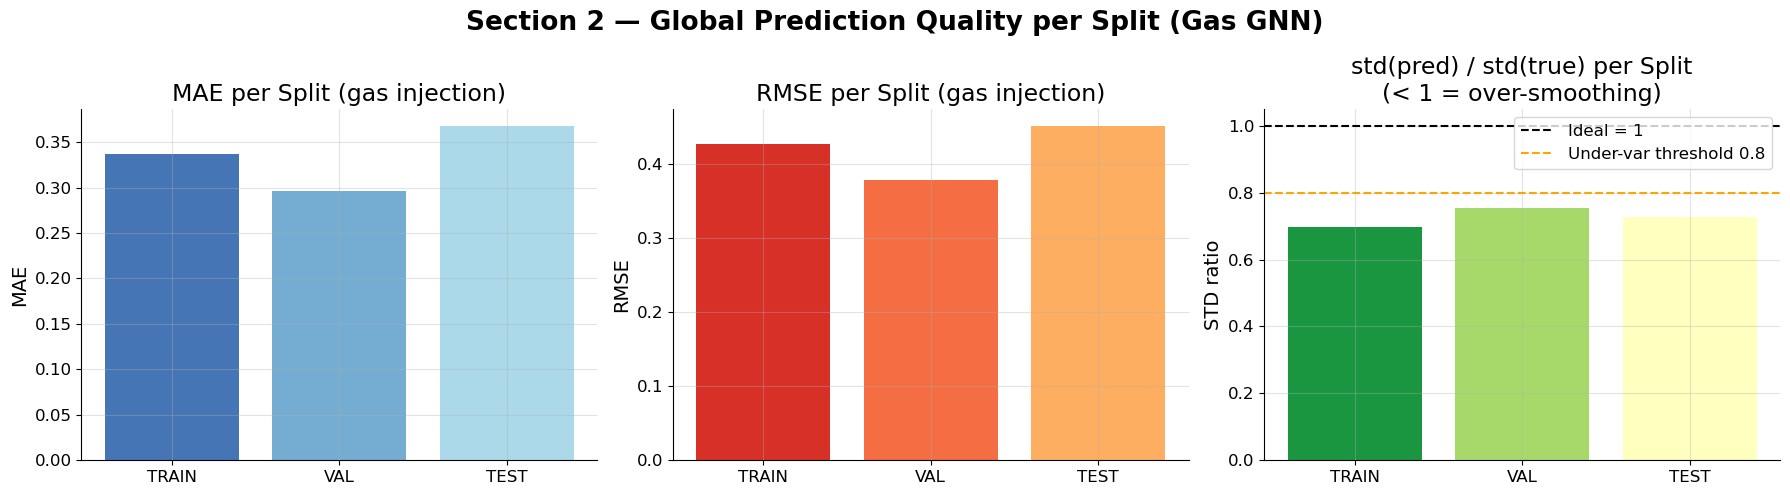


--- SECTION 3: Error per prediction horizon (test set) ---


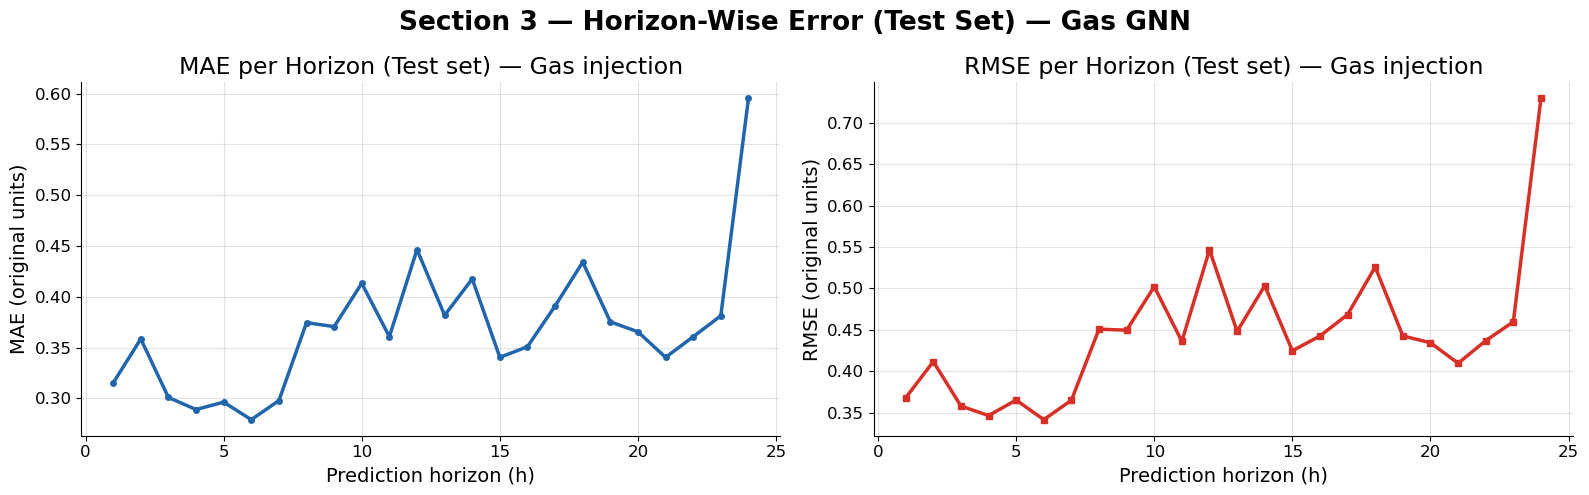

  RMSE at h=1  : 0.3682
  RMSE at h=24 : 0.7291
  Relative increase h1→h24 : 98.0%
  → Error degrades with horizon, consistent with a purely spatial GNN.

--- SECTION 4: Smoothing analysis — std(pred) vs std(true) ---
  Mean per-well STD ratio              : 0.545
  Aggregated (all wells) STD ratio     : 0.615
  % wells with std ratio < 0.8         : 100.0%
  → System-level gas injection variability is underestimated by 38% — GNN message-passing homogenises nodes.


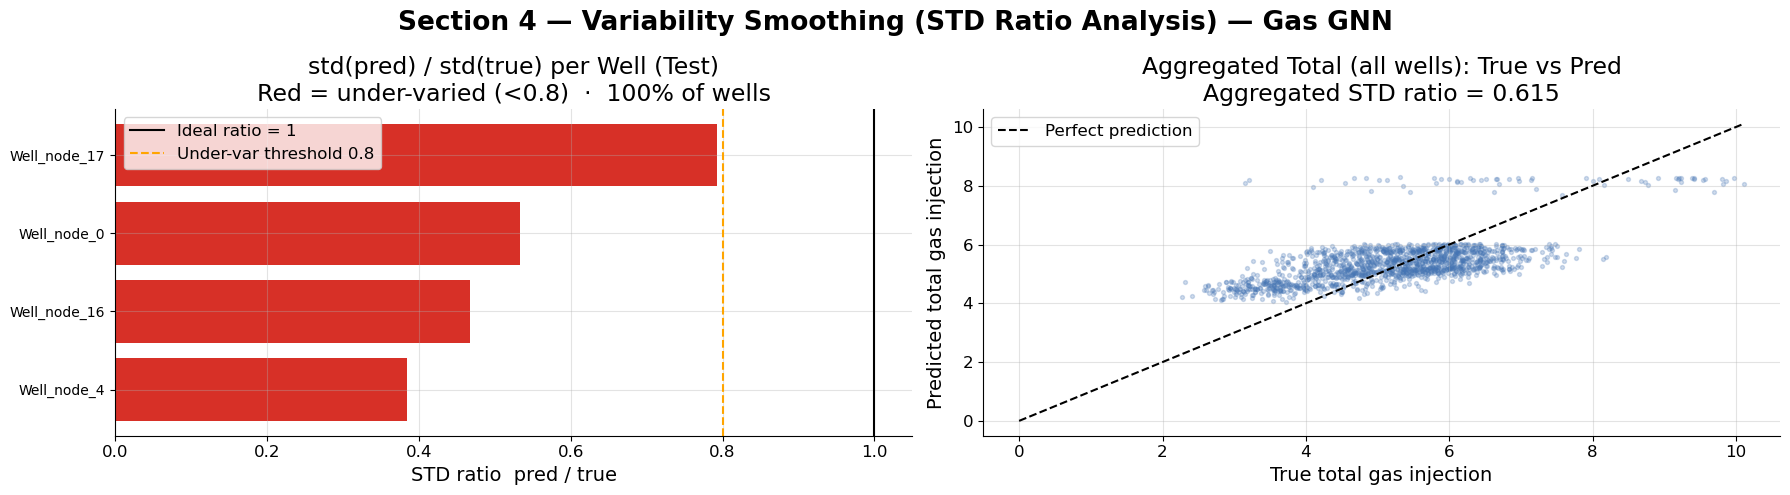


--- SECTION 5: Dynamic feature – target correlation (lag = horizon) ---
      feature  corr_with_target_t+24h
   res_demand                0.574253
gfpp_gas_load                0.397138
   ind_demand                0.332018
   exp_demand               -0.047194


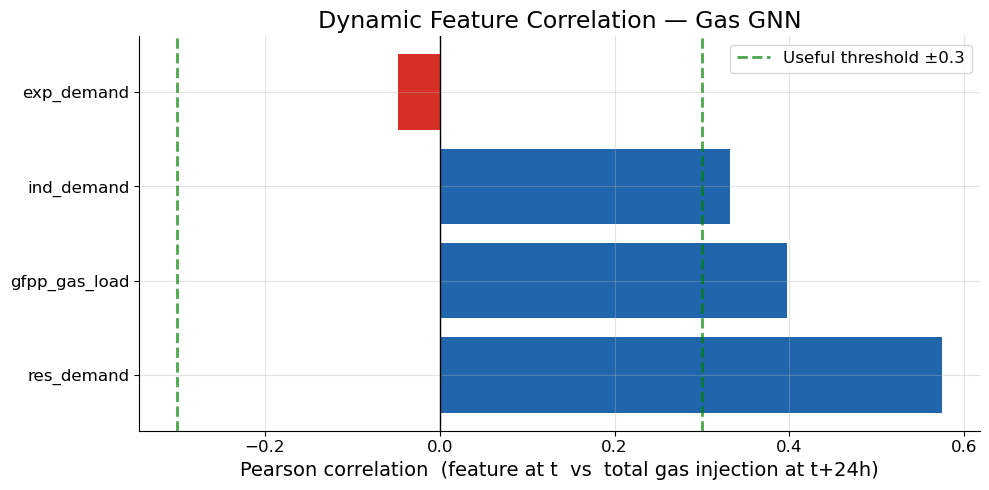


  ⚠ Near-zero correlation features (|r|<0.15): ['exp_demand']
    → These inputs carry almost no predictive information at this horizon.

--- SECTION 6: Intrinsic target difficulty — autocorrelation & variability ---


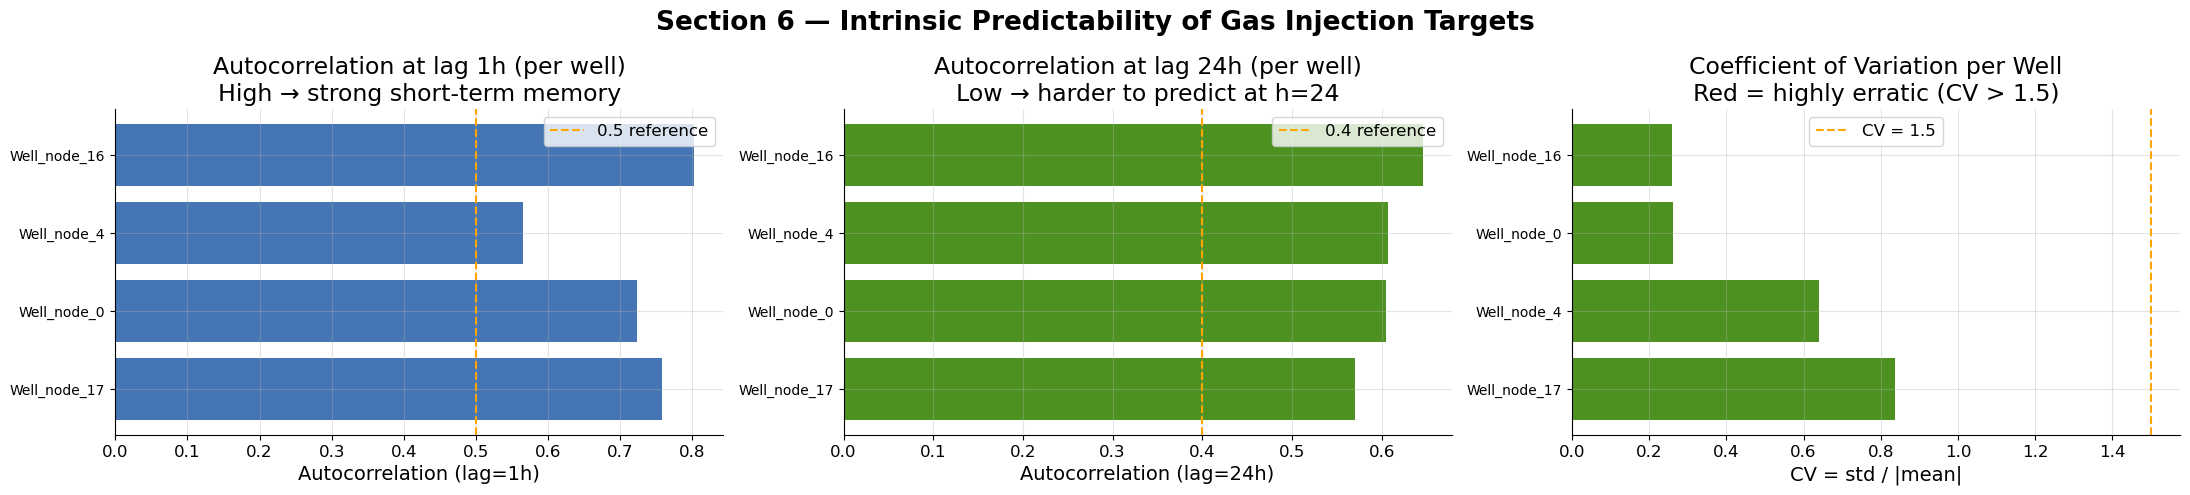

  Wells with autocorr(24h) < 0.4 (hard to predict at h=24): []
  Wells with CV > 2.0 (highly intermittent): []

--- SECTION 7: Per-node errors (test set) ---

  Top-3 worst wells account for 80.9% of total RMSE sum:
   well_name   MAE  RMSE  NMAE  std_true  std_pred  std_ratio  RMSE_share_%
 Well_node_0 0.417 0.528 0.162     0.512     0.273      0.534        29.650
Well_node_17 0.457 0.510 2.038     0.250     0.198      0.792        28.632
 Well_node_4 0.319 0.402 0.346     0.460     0.177      0.385        22.592
Well_node_16 0.280 0.341 0.186     0.367     0.172      0.467        19.126


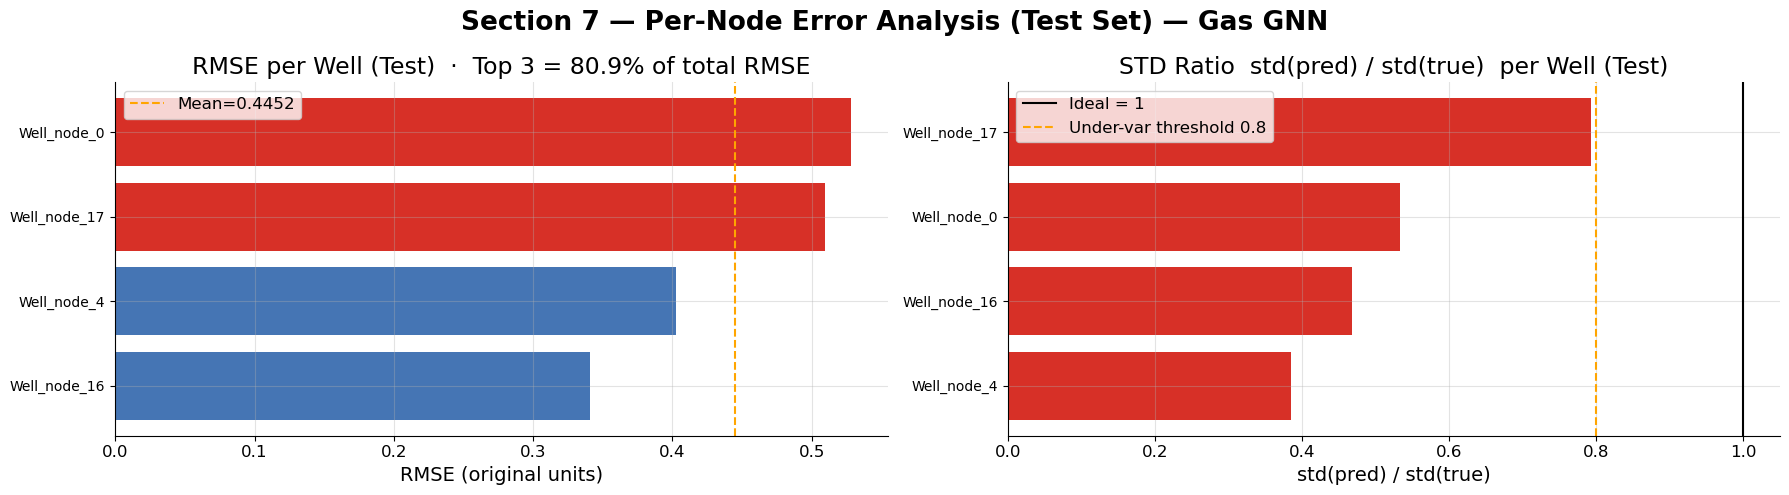


--- SECTION 8: Systematic ZERO/NON-ZERO injection failure analysis ---
  ZERO/NON-ZERO threshold : true < 0.001, pred > 0.01
  Number of failures      : 356
  Mean absolute error on those failures : 0.601468
  → GNN predicts injection when the well is actually inactive.
    Start/stop dynamics not captured from the available features.


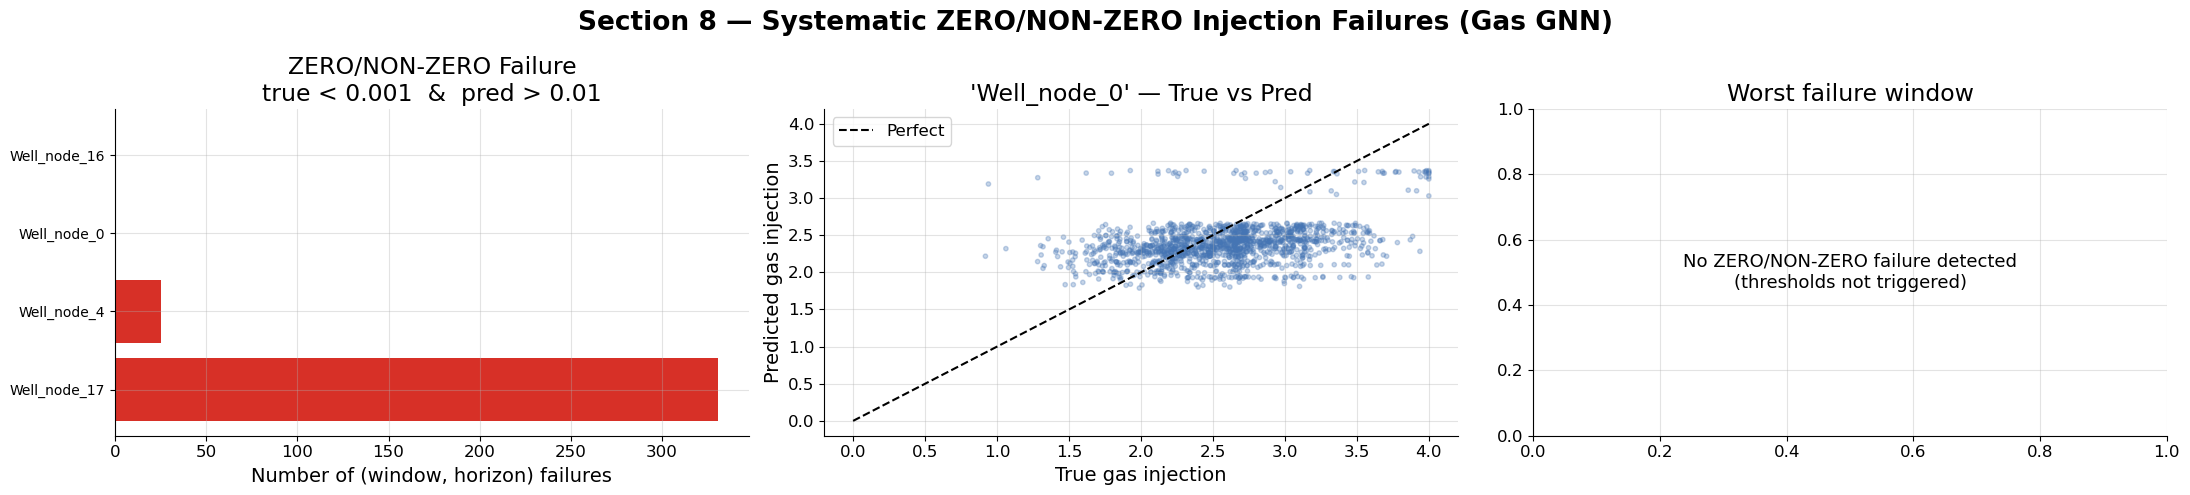


--- SECTION 9: Global residual analysis (test set) ---
  R²                    : 0.7747
  Bias (mean residual)  : 0.038834
  std(residual)         : 0.450144
  std(pred)/std(true)   : 0.7279


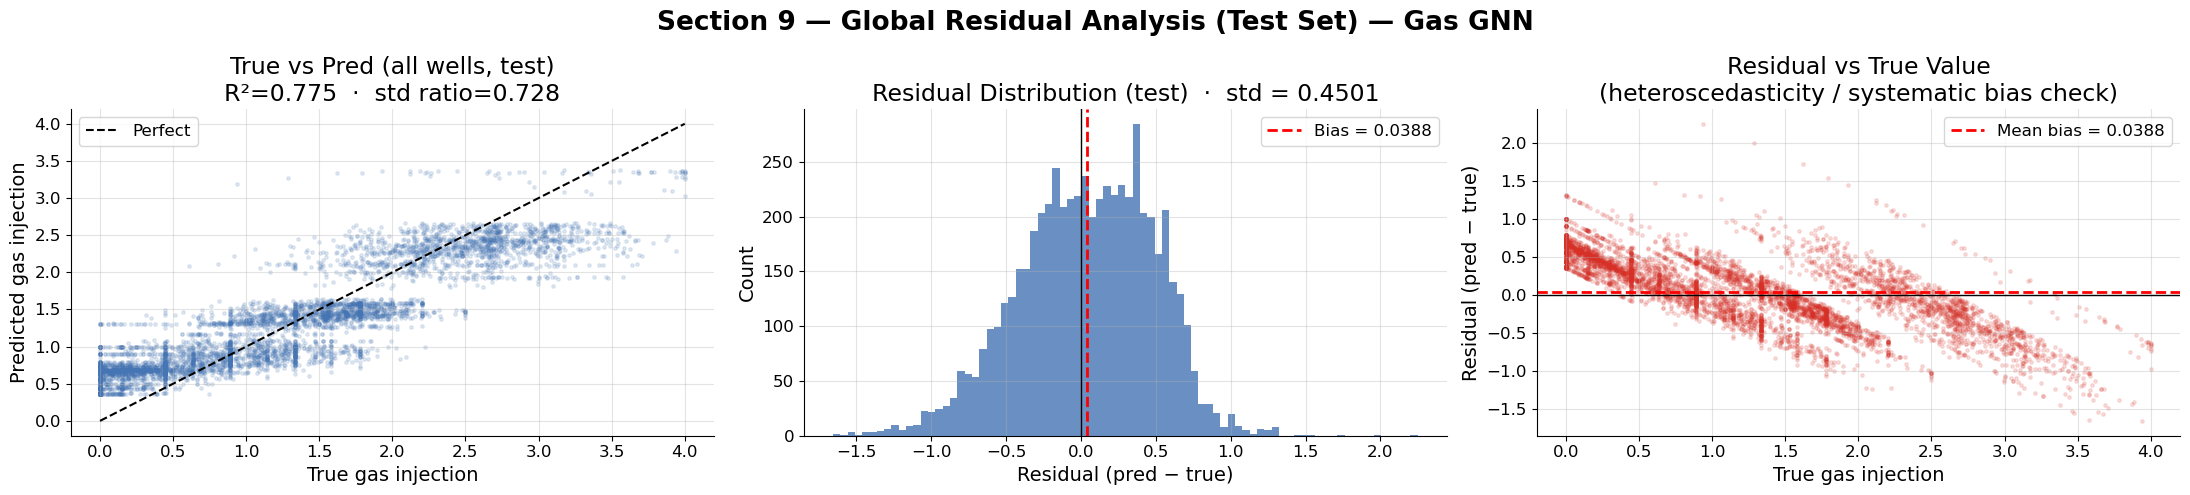


CONSOLIDATED DIAGNOSTIC SUMMARY — Gas GNN
   1. [MODEL]  Val loss stagnates at epoch ~88 while train keeps dropping (gap=-0.1535) → overfitting on 100 epochs.
   2. [MODEL]  Aggregated STD ratio = 0.615 → GNN smooths out 38% of system-level gas injection variability.
   3. [MODEL]  100% of wells have std(pred)/std(true) < 0.8 → over-smoothing generalised across individual wells.
   4. [MODEL]  RMSE increases from 0.3682 (h=1) to 0.7291 (h=24) (+98.0%) → purely spatial GNN lacks temporal depth.
   5. [MODEL]  Top-3 worst wells = 80.9% of total node RMSE → GNN spatial propagation does not equalise errors across wells.
   6. [DATA]   356 ZERO/NON-ZERO failures (true≈0, pred>>0.01) → well start/stop dynamics not learnable from available features.
   7. [DATA]   Features with near-zero lag-24h correlation: ['exp_demand'] → non-informative inputs for this horizon.

  Legend: [MODEL] = evidence against GNN adequacy
          [DATA]  = evidence of data/target limitations


In [38]:
# ============================================================
# GIANT DIAGNOSTIC CELL - GNN Spatial Gas
# Assesses: model inadequacy, data quality, and problem formulation
# All outputs in English | Report-ready style
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# ── Global matplotlib style ──────────────────────────────────
plt.rcParams.update({
    "figure.figsize"      : (14, 5),
    "axes.titlesize"      : 17,
    "axes.labelsize"      : 14,
    "xtick.labelsize"     : 12,
    "ytick.labelsize"     : 12,
    "legend.fontsize"     : 12,
    "figure.titlesize"    : 19,
    "lines.linewidth"     : 2.0,
    "axes.grid"           : True,
    "grid.alpha"          : 0.35,
    "axes.spines.top"     : False,
    "axes.spines.right"   : False,
})

# ── Robust variable resolution ───────────────────────────────
def _get(*names, default=None):
    for n in names:
        if n in globals():
            return globals()[n]
    return default

def _to3d(arr, n_wells, hor):
    arr = np.asarray(arr)
    if arr.ndim == 3:
        return arr
    if arr.ndim == 2:
        return arr.reshape(arr.shape[0] // n_wells, n_wells, hor)
    raise ValueError(f"Cannot reshape ndim={arr.ndim}")

def _mae(a, b):
    return float(np.mean(np.abs(np.asarray(a).ravel() - np.asarray(b).ravel())))

def _rmse(a, b):
    return float(np.sqrt(np.mean((np.asarray(a).ravel() - np.asarray(b).ravel())**2)))

# ── Retrieve core variables ──────────────────────────────────
CONFIG_    = _get("CONFIG", default={})
N_WELLS_   = _get("N_WELLS", default=len(CONFIG_.get("WELL_IDX", [0, 4, 16, 17])))
HOR_       = _get("HOR", "HORIZON_HOURS", default=24)
# À vérifier : WELL_IDX_ doit correspondre aux indices globaux des wells
WELL_IDX_  = list(CONFIG_.get("WELL_IDX", list(range(N_WELLS_))))

ts_        = np.asarray(_get("ts_g", "ts", default=np.arange(8784)))

train_out_ = _get("train_out")
val_out_   = _get("val_out")
test_out_  = _get("test_out")

# À vérifier : g_full est le tenseur [T, N_WELLS] des injections gaz
g_full_    = _get("g_full")          # [T, N_WELLS]
dyn_tensor_        = _get("dyn_tensor")
dyn_feature_names_ = _get("dyn_feature_names")
history_           = _get("history")

# Helper: get well name from global index (gas network has no bus name dataframe)
def well_name(global_idx):
    return f"Well_node_{global_idx}"

# Autocorrelation helper
def autocorr_1d(y, lag=1):
    y = np.asarray(y, dtype=float)
    valid = y[~np.isnan(y)]
    if len(valid) <= lag:
        return np.nan
    return float(np.corrcoef(valid[:-lag], valid[lag:])[0, 1])

print("=" * 70)
print("GIANT DIAGNOSTIC CELL — GNN Spatial Gas")
print("=" * 70)

# ============================================================
# SECTION 1 — Learning curves (overfitting detection)
# ============================================================
print("\n--- SECTION 1: Learning curves ---")

if history_ is not None:
    train_loss = np.asarray(history_["train_loss"], dtype=float)
    val_loss   = np.asarray(history_["val_loss"],   dtype=float)
    lr_hist    = np.asarray(history_.get("lr", []), dtype=float)
    epochs     = np.arange(1, len(train_loss) + 1)
    best_epoch = int(np.argmin(val_loss)) + 1
    best_val   = float(val_loss[best_epoch - 1])
    gap_final  = float(val_loss[-1] - train_loss[-1])

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    axes[0].plot(epochs, train_loss, label="Train loss", color="#2166ac", lw=2)
    axes[0].plot(epochs, val_loss,   label="Val loss",   color="#d73027", lw=2)
    axes[0].axvline(best_epoch, color="green", ls="--", alpha=0.7,
                    label=f"Best epoch={best_epoch} (val={best_val:.4f})")
    axes[0].set_title("Training & Validation Loss (MSE)")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("MSE Loss")
    axes[0].legend()

    if len(lr_hist):
        axes[1].plot(epochs[:len(lr_hist)], lr_hist, color="#4d9221", lw=2)
        axes[1].set_title("Learning Rate Schedule")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("Learning Rate")
        axes[1].set_yscale("log")

    plt.suptitle("Section 1 — Learning Curves", fontweight="bold")
    plt.tight_layout()
    plt.show()

    print(f"  Total epochs run      : {len(train_loss)}")
    print(f"  Best epoch (val)      : {best_epoch}  →  val_loss = {best_val:.5f}")
    print(f"  Final train loss      : {train_loss[-1]:.5f}")
    print(f"  Final val   loss      : {val_loss[-1]:.5f}")
    print(f"  Final gap (val-train) : {gap_final:.5f}")
    print(f"  → Val loss stagnates after epoch {best_epoch} while train keeps decreasing.")
    print(f"    Overfitting signal: model memorizes train without generalizing.")
else:
    print("  [SKIP] history_ not found.")

# ============================================================
# SECTION 2 — Global prediction quality (per split)
# ============================================================
print("\n--- SECTION 2: Global prediction quality per split ---")

split_metrics = []
for split_name, out in [("train", train_out_), ("val", val_out_), ("test", test_out_)]:
    if out is None:
        continue
    y_true = _to3d(out["trues_real"], N_WELLS_, HOR_).ravel()
    y_pred = _to3d(out["preds_real"], N_WELLS_, HOR_).ravel()
    split_metrics.append({
        "Split"         : split_name,
        "MAE"           : _mae(y_true, y_pred),
        "RMSE"          : _rmse(y_true, y_pred),
        "R2"            : float(r2_score(y_true, y_pred)),
        "std_pred/true" : float(np.std(y_pred)) / (float(np.std(y_true)) + 1e-9),
        "Bias"          : float(np.mean(y_pred - y_true)),
    })

if split_metrics:
    df_spl = pd.DataFrame(split_metrics)
    print(df_spl.to_string(index=False, float_format="{:.4f}".format))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    splits = df_spl["Split"].str.upper().values
    x = np.arange(len(splits))

    axes[0].bar(x, df_spl["MAE"],  color=["#4575b4","#74add1","#abd9e9"])
    axes[0].set_xticks(x); axes[0].set_xticklabels(splits)
    axes[0].set_title("MAE per Split (gas injection)"); axes[0].set_ylabel("MAE")

    axes[1].bar(x, df_spl["RMSE"], color=["#d73027","#f46d43","#fdae61"])
    axes[1].set_xticks(x); axes[1].set_xticklabels(splits)
    axes[1].set_title("RMSE per Split (gas injection)"); axes[1].set_ylabel("RMSE")

    axes[2].bar(x, df_spl["std_pred/true"], color=["#1a9641","#a6d96a","#ffffbf"])
    axes[2].axhline(1.0, color="black", ls="--", lw=1.5, label="Ideal = 1")
    axes[2].axhline(0.8, color="orange", ls="--", lw=1.5, label="Under-var threshold 0.8")
    axes[2].set_xticks(x); axes[2].set_xticklabels(splits)
    axes[2].set_title("std(pred) / std(true) per Split\n(< 1 = over-smoothing)")
    axes[2].set_ylabel("STD ratio")
    axes[2].legend()

    plt.suptitle("Section 2 — Global Prediction Quality per Split (Gas GNN)", fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("  [SKIP] No split outputs found.")

# ============================================================
# SECTION 3 — Error by prediction horizon (h=1 → 24)
# ============================================================
print("\n--- SECTION 3: Error per prediction horizon (test set) ---")

if test_out_ is not None:
    y_true3 = _to3d(test_out_["trues_real"], N_WELLS_, HOR_)
    y_pred3 = _to3d(test_out_["preds_real"], N_WELLS_, HOR_)

    horizon_rows = []
    for h in range(HOR_):
        horizon_rows.append({
            "h"         : h + 1,
            "model_MAE" : _mae(y_true3[:, :, h], y_pred3[:, :, h]),
            "model_RMSE": _rmse(y_true3[:, :, h], y_pred3[:, :, h]),
        })
    hor_df = pd.DataFrame(horizon_rows)
    horizons = hor_df["h"].values

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    axes[0].plot(horizons, hor_df["model_MAE"], color="#2166ac", lw=2.5, marker="o", ms=4)
    axes[0].set_title("MAE per Horizon (Test set) — Gas injection")
    axes[0].set_xlabel("Prediction horizon (h)")
    axes[0].set_ylabel("MAE (original units)")

    axes[1].plot(horizons, hor_df["model_RMSE"], color="#d73027", lw=2.5, marker="s", ms=4)
    axes[1].set_title("RMSE per Horizon (Test set) — Gas injection")
    axes[1].set_xlabel("Prediction horizon (h)")
    axes[1].set_ylabel("RMSE (original units)")

    plt.suptitle("Section 3 — Horizon-Wise Error (Test Set) — Gas GNN", fontweight="bold")
    plt.tight_layout()
    plt.show()

    rmse_h1  = hor_df.iloc[0]["model_RMSE"]
    rmse_h24 = hor_df.iloc[-1]["model_RMSE"]
    print(f"  RMSE at h=1  : {rmse_h1:.4f}")
    print(f"  RMSE at h=24 : {rmse_h24:.4f}")
    print(f"  Relative increase h1→h24 : {100*(rmse_h24 - rmse_h1)/rmse_h1:.1f}%")
    print(f"  → Error degrades with horizon, consistent with a purely spatial GNN.")
else:
    print("  [SKIP] test_out_ not found.")

# ============================================================
# SECTION 4 — Variability smoothing analysis (STD ratio)
# ============================================================
print("\n--- SECTION 4: Smoothing analysis — std(pred) vs std(true) ---")

if test_out_ is not None:
    y_true3 = _to3d(test_out_["trues_real"], N_WELLS_, HOR_)
    y_pred3 = _to3d(test_out_["preds_real"], N_WELLS_, HOR_)

    node_std_rows = []
    for j in range(N_WELLS_):
        std_t   = float(np.std(y_true3[:, j, :]))
        std_p   = float(np.std(y_pred3[:, j, :]))
        ratio   = std_p / (std_t + 1e-9)
        w_idx   = WELL_IDX_[j] if j < len(WELL_IDX_) else j
        node_std_rows.append({
            "well_j": j, "global_well_idx": w_idx,
            "well_name": well_name(w_idx),
            "std_true": std_t, "std_pred": std_p, "ratio": ratio,
        })
    node_std_df = pd.DataFrame(node_std_rows).sort_values("ratio")
    pct_under   = float((node_std_df["ratio"] < 0.8).mean()) * 100

    agg_true      = y_true3.sum(axis=1)   # [N_windows, HOR]
    agg_pred      = y_pred3.sum(axis=1)
    agg_std_ratio = float(np.std(agg_pred)) / (float(np.std(agg_true)) + 1e-9)

    print(f"  Mean per-well STD ratio              : {node_std_df['ratio'].mean():.3f}")
    print(f"  Aggregated (all wells) STD ratio     : {agg_std_ratio:.3f}")
    print(f"  % wells with std ratio < 0.8         : {pct_under:.1f}%")
    print(f"  → System-level gas injection variability is underestimated by"
          f" {100*(1-agg_std_ratio):.0f}% — GNN message-passing homogenises nodes.")

    fig, axes = plt.subplots(1, 2, figsize=(18, 5))

    colors_bar = ["#d73027" if r < 0.8 else "#4d9221" for r in node_std_df["ratio"]]
    axes[0].barh(range(len(node_std_df)), node_std_df["ratio"], color=colors_bar)
    axes[0].axvline(1.0, color="black",  ls="-",  lw=1.5, label="Ideal ratio = 1")
    axes[0].axvline(0.8, color="orange", ls="--", lw=1.5, label="Under-var threshold 0.8")
    axes[0].set_yticks(range(len(node_std_df)))
    axes[0].set_yticklabels(node_std_df["well_name"].values, fontsize=10)
    axes[0].set_title(f"std(pred) / std(true) per Well (Test)\n"
                      f"Red = under-varied (<0.8)  ·  {pct_under:.0f}% of wells")
    axes[0].set_xlabel("STD ratio  pred / true")
    axes[0].legend()

    n_samp = min(3000, len(agg_true.ravel()))
    idx_s  = np.random.choice(len(agg_true.ravel()), n_samp, replace=False)
    axes[1].scatter(agg_true.ravel()[idx_s], agg_pred.ravel()[idx_s],
                    alpha=0.25, s=8, color="#4575b4")
    lim = max(np.abs(agg_true.ravel()).max(), np.abs(agg_pred.ravel()).max())
    axes[1].plot([0, lim], [0, lim], "k--", lw=1.5, label="Perfect prediction")
    axes[1].set_title(f"Aggregated Total (all wells): True vs Pred\n"
                      f"Aggregated STD ratio = {agg_std_ratio:.3f}")
    axes[1].set_xlabel("True total gas injection")
    axes[1].set_ylabel("Predicted total gas injection")
    axes[1].legend()

    plt.suptitle("Section 4 — Variability Smoothing (STD Ratio Analysis) — Gas GNN", fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("  [SKIP] test_out_ not found.")

# ============================================================
# SECTION 5 — Feature-to-target correlation analysis
# ============================================================
print("\n--- SECTION 5: Dynamic feature – target correlation (lag = horizon) ---")

if dyn_tensor_ is not None and g_full_ is not None:
    T_data     = min(dyn_tensor_.shape[0], g_full_.shape[0])
    F_dyn      = dyn_tensor_.shape[-1]
    feat_names = (dyn_feature_names_ if dyn_feature_names_ is not None
                  else [f"dyn_feature_{i}" for i in range(F_dyn)])

    # total injection gaz agrégé [T]
    target_total = np.nansum(g_full_[:T_data], axis=1)
    lag = HOR_  # 24h

    corr_rows = []
    for k in range(F_dyn):
        feat_mean = np.nanmean(dyn_tensor_[:T_data, :, k], axis=1)
        valid     = ~(np.isnan(feat_mean) | np.isnan(target_total))
        x, y      = feat_mean[valid], target_total[valid]
        corr_val  = float(np.corrcoef(x[:-lag], y[lag:])[0, 1]) if len(x) > lag + 10 else np.nan
        corr_rows.append({"feature": feat_names[k], f"corr_with_target_t+{lag}h": corr_val})

    corr_df = pd.DataFrame(corr_rows).sort_values(f"corr_with_target_t+{lag}h",
                                                   key=abs, ascending=False)
    print(corr_df.to_string(index=False))

    fig, ax = plt.subplots(figsize=(10, 5))
    col_key  = f"corr_with_target_t+{lag}h"
    colors_c = ["#2166ac" if abs(v) > 0.3 else "#d73027"
                for v in corr_df[col_key]]
    ax.barh(corr_df["feature"], corr_df[col_key], color=colors_c)
    ax.axvline( 0.0, color="black", lw=1)
    ax.axvline( 0.3, color="green", ls="--", alpha=0.7, label="Useful threshold ±0.3")
    ax.axvline(-0.3, color="green", ls="--", alpha=0.7)
    ax.set_title("Dynamic Feature Correlation — Gas GNN")
    ax.set_xlabel(f"Pearson correlation  (feature at t  vs  total gas injection at t+{lag}h)")
    ax.legend()
    plt.tight_layout()
    plt.show()

    low_info = corr_df[corr_df[col_key].abs() < 0.15]
    if not low_info.empty:
        print(f"\n  ⚠ Near-zero correlation features (|r|<0.15): "
              f"{list(low_info['feature'].values)}")
        print("    → These inputs carry almost no predictive information at this horizon.")
else:
    print("  [SKIP] dyn_tensor_ or g_full_ not found.")

# ============================================================
# SECTION 6 — Intrinsic target difficulty: autocorrelation & CV
# ============================================================
print("\n--- SECTION 6: Intrinsic target difficulty — autocorrelation & variability ---")

if g_full_ is not None:
    ac_rows = []
    for j in range(g_full_.shape[1]):
        y        = g_full_[:, j]
        mean_abs = float(np.nanmean(np.abs(y)))
        std_y    = float(np.nanstd(y))
        cv       = std_y / (mean_abs + 1e-9)
        w_idx    = WELL_IDX_[j] if j < len(WELL_IDX_) else j
        ac_rows.append({
            "well_name"     : well_name(w_idx),
            "global_idx"    : w_idx,
            "mean_abs"      : mean_abs,
            "std"           : std_y,
            "cv"            : cv,
            "autocorr_1h"   : autocorr_1d(y, lag=1),
            "autocorr_24h"  : autocorr_1d(y, lag=24),
        })
    ac_df = pd.DataFrame(ac_rows).sort_values("autocorr_24h")

    fig, axes = plt.subplots(1, 3, figsize=(22, 5))

    axes[0].barh(range(len(ac_df)), ac_df["autocorr_1h"], color="#4575b4")
    axes[0].set_yticks(range(len(ac_df)))
    axes[0].set_yticklabels(ac_df["well_name"].values, fontsize=10)
    axes[0].set_title("Autocorrelation at lag 1h (per well)\nHigh → strong short-term memory")
    axes[0].set_xlabel("Autocorrelation (lag=1h)")
    axes[0].axvline(0.5, color="orange", ls="--", lw=1.5, label="0.5 reference")
    axes[0].legend()

    axes[1].barh(range(len(ac_df)), ac_df["autocorr_24h"], color="#4d9221")
    axes[1].set_yticks(range(len(ac_df)))
    axes[1].set_yticklabels(ac_df["well_name"].values, fontsize=10)
    axes[1].set_title("Autocorrelation at lag 24h (per well)\nLow → harder to predict at h=24")
    axes[1].set_xlabel("Autocorrelation (lag=24h)")
    axes[1].axvline(0.4, color="orange", ls="--", lw=1.5, label="0.4 reference")
    axes[1].legend()

    cv_sorted = ac_df.sort_values("cv", ascending=False)
    clrs_cv   = ["#d73027" if cv > 1.5 else "#4d9221" for cv in cv_sorted["cv"]]
    axes[2].barh(range(len(cv_sorted)), cv_sorted["cv"], color=clrs_cv)
    axes[2].set_yticks(range(len(cv_sorted)))
    axes[2].set_yticklabels(cv_sorted["well_name"].values, fontsize=10)
    axes[2].set_title("Coefficient of Variation per Well\nRed = highly erratic (CV > 1.5)")
    axes[2].set_xlabel("CV = std / |mean|")
    axes[2].axvline(1.5, color="orange", ls="--", lw=1.5, label="CV = 1.5")
    axes[2].legend()

    plt.suptitle("Section 6 — Intrinsic Predictability of Gas Injection Targets", fontweight="bold")
    plt.tight_layout()
    plt.show()

    hard_wells    = ac_df[ac_df["autocorr_24h"] < 0.4]
    erratic_wells = cv_sorted[cv_sorted["cv"] > 2.0]
    print(f"  Wells with autocorr(24h) < 0.4 (hard to predict at h=24): "
          f"{list(hard_wells['well_name'].values)}")
    print(f"  Wells with CV > 2.0 (highly intermittent): "
          f"{list(erratic_wells['well_name'].values)}")
else:
    print("  [SKIP] g_full_ not found.")

# ============================================================
# SECTION 7 — Per-node error analysis
# ============================================================
print("\n--- SECTION 7: Per-node errors (test set) ---")

if test_out_ is not None:
    y_true3 = _to3d(test_out_["trues_real"], N_WELLS_, HOR_)
    y_pred3 = _to3d(test_out_["preds_real"], N_WELLS_, HOR_)

    node_rows = []
    for j in range(N_WELLS_):
        yt      = y_true3[:, j, :]
        yp      = y_pred3[:, j, :]
        mae_j   = _mae(yt, yp)
        rmse_j  = _rmse(yt, yp)
        std_t   = float(np.std(yt))
        std_p   = float(np.std(yp))
        mean_t  = float(np.mean(np.abs(yt)))
        w_idx   = WELL_IDX_[j] if j < len(WELL_IDX_) else j
        node_rows.append({
            "well_j": j, "global_idx": w_idx,
            "well_name" : well_name(w_idx),
            "MAE"       : mae_j,
            "RMSE"      : rmse_j,
            "NMAE"      : mae_j / (mean_t + 1e-9),
            "std_true"  : std_t,
            "std_pred"  : std_p,
            "std_ratio" : std_p / (std_t + 1e-9),
        })
    node_df    = pd.DataFrame(node_rows).sort_values("RMSE", ascending=False)
    total_rmse = node_df["RMSE"].sum()
    node_df["RMSE_share_%"] = 100 * node_df["RMSE"] / (total_rmse + 1e-9)
    top3_share = float(node_df.head(3)["RMSE_share_%"].sum())

    print(f"\n  Top-3 worst wells account for {top3_share:.1f}% of total RMSE sum:")
    print(node_df[["well_name", "MAE", "RMSE", "NMAE",
                   "std_true", "std_pred", "std_ratio",
                   "RMSE_share_%"]].head(6).to_string(index=False,
                   float_format="{:.3f}".format))

    fig, axes = plt.subplots(1, 2, figsize=(18, 5))

    node_sort_rmse = node_df.sort_values("RMSE", ascending=True)
    mean_rmse      = total_rmse / N_WELLS_
    colors_rmse    = ["#d73027" if r > mean_rmse else "#4575b4"
                      for r in node_sort_rmse["RMSE"]]
    axes[0].barh(range(len(node_sort_rmse)), node_sort_rmse["RMSE"], color=colors_rmse)
    axes[0].set_yticks(range(len(node_sort_rmse)))
    axes[0].set_yticklabels(node_sort_rmse["well_name"].values, fontsize=10)
    axes[0].set_title(f"RMSE per Well (Test)  ·  Top 3 = {top3_share:.1f}% of total RMSE")
    axes[0].set_xlabel("RMSE (original units)")
    axes[0].axvline(mean_rmse, color="orange", ls="--", lw=1.5, label=f"Mean={mean_rmse:.4f}")
    axes[0].legend()

    node_sort_ratio = node_df.sort_values("std_ratio", ascending=True)
    clrs_r = ["#d73027" if r < 0.8 else "#4d9221" for r in node_sort_ratio["std_ratio"]]
    axes[1].barh(range(len(node_sort_ratio)), node_sort_ratio["std_ratio"], color=clrs_r)
    axes[1].axvline(1.0, color="black",  ls="-",  lw=1.5, label="Ideal = 1")
    axes[1].axvline(0.8, color="orange", ls="--", lw=1.5, label="Under-var threshold 0.8")
    axes[1].set_yticks(range(len(node_sort_ratio)))
    axes[1].set_yticklabels(node_sort_ratio["well_name"].values, fontsize=10)
    axes[1].set_title("STD Ratio  std(pred) / std(true)  per Well (Test)")
    axes[1].set_xlabel("std(pred) / std(true)")
    axes[1].legend()

    plt.suptitle("Section 7 — Per-Node Error Analysis (Test Set) — Gas GNN", fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("  [SKIP] test_out_ not found.")

# ============================================================
# SECTION 8 — Systematic ZERO/NON-ZERO failure analysis
# (injection gaz ≈ 0 mais le modèle prédit une injection non nulle)
# ============================================================
print("\n--- SECTION 8: Systematic ZERO/NON-ZERO injection failure analysis ---")

if test_out_ is not None:
    y_true3 = _to3d(test_out_["trues_real"], N_WELLS_, HOR_)
    y_pred3 = _to3d(test_out_["preds_real"], N_WELLS_, HOR_)
    abs_err = np.abs(y_pred3 - y_true3)

    # À ADAPTER : seuils en unités originales (MNm³/h typiquement)
    near_zero_thresh = 0.001   # injection vraie ≈ 0
    nonzero_pred_thr = 0.01    # mais prédiction non nulle
    mask_zero_fail = (np.abs(y_true3) < near_zero_thresh) & (np.abs(y_pred3) > nonzero_pred_thr)
    n_zero_fail    = int(mask_zero_fail.sum())
    mae_zero_fail  = float(np.mean(abs_err[mask_zero_fail])) if n_zero_fail > 0 else np.nan

    print(f"  ZERO/NON-ZERO threshold : true < {near_zero_thresh}, pred > {nonzero_pred_thr}")
    print(f"  Number of failures      : {n_zero_fail}")
    print(f"  Mean absolute error on those failures : {mae_zero_fail:.6f}")
    if n_zero_fail > 0:
        print("  → GNN predicts injection when the well is actually inactive.")
        print("    Start/stop dynamics not captured from the available features.")

    fail_per_well = mask_zero_fail.sum(axis=(0, 2))
    fail_df = pd.DataFrame({
        "well_j"         : np.arange(N_WELLS_),
        "global_well_idx": WELL_IDX_,
        "well_name"      : [well_name(WELL_IDX_[j]) for j in range(N_WELLS_)],
        "n_failures"     : fail_per_well,
    }).sort_values("n_failures", ascending=False).reset_index(drop=True)

    worst_well_j   = int(node_df.iloc[0]["well_j"])   if 'node_df' in dir() else 0
    worst_well_nm  = node_df.iloc[0]["well_name"]     if 'node_df' in dir() else "?"

    fig, axes = plt.subplots(1, 3, figsize=(22, 5))

    clrs_fail = ["#d73027" if n > 0 else "#4d9221" for n in fail_df["n_failures"]]
    axes[0].barh(range(len(fail_df)), fail_df["n_failures"], color=clrs_fail)
    axes[0].set_yticks(range(len(fail_df)))
    axes[0].set_yticklabels(fail_df["well_name"].values, fontsize=10)
    axes[0].set_title(f"ZERO/NON-ZERO Failure\n"
                      f"true < {near_zero_thresh}  &  pred > {nonzero_pred_thr}")
    axes[0].set_xlabel("Number of (window, horizon) failures")

    yt_w = y_true3[:, worst_well_j, :].ravel()
    yp_w = y_pred3[:, worst_well_j, :].ravel()
    clrs_sc = np.where(
        (np.abs(yt_w) < near_zero_thresh) & (np.abs(yp_w) > nonzero_pred_thr),
        "#d73027", "#4575b4"
    )
    axes[1].scatter(yt_w, yp_w, c=clrs_sc, alpha=0.3, s=10)
    lim_w = max(np.abs(yt_w).max(), np.abs(yp_w).max())
    axes[1].plot([0, lim_w], [0, lim_w], "k--", lw=1.5, label="Perfect")
    axes[1].set_title(f"'{worst_well_nm}' — True vs Pred")
    axes[1].set_xlabel("True gas injection"); axes[1].set_ylabel("Predicted gas injection")
    axes[1].legend()

    fail_per_win = mask_zero_fail[:, worst_well_j, :].sum(axis=1)
    if fail_per_win.max() > 0:
        worst_win = int(np.argmax(fail_per_win))
        axes[2].plot(range(1, HOR_ + 1), y_true3[worst_win, worst_well_j, :],
                     "o-", color="blue", lw=2, label="True")
        axes[2].plot(range(1, HOR_ + 1), y_pred3[worst_win, worst_well_j, :],
                     "s--", color="red", lw=2, label="Predicted")
        axes[2].set_title(f"'{worst_well_nm}' — Worst failure window")
        axes[2].set_xlabel("Horizon h"); axes[2].set_ylabel("Gas injection (original units)")
        axes[2].legend()
    else:
        axes[2].text(0.5, 0.5, "No ZERO/NON-ZERO failure detected\n(thresholds not triggered)",
                     ha="center", va="center", transform=axes[2].transAxes, fontsize=13)
        axes[2].set_title("Worst failure window")

    plt.suptitle("Section 8 — Systematic ZERO/NON-ZERO Injection Failures (Gas GNN)",
                 fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("  [SKIP] test_out_ not found.")

# ============================================================
# SECTION 9 — Global residual analysis (test set)
# ============================================================
print("\n--- SECTION 9: Global residual analysis (test set) ---")

if test_out_ is not None:
    y_true_f = _to3d(test_out_["trues_real"], N_WELLS_, HOR_).ravel()
    y_pred_f = _to3d(test_out_["preds_real"], N_WELLS_, HOR_).ravel()
    resid    = y_pred_f - y_true_f

    bias      = float(np.mean(resid))
    std_err   = float(np.std(resid))
    r2_val    = float(r2_score(y_true_f, y_pred_f))
    std_ratio = float(np.std(y_pred_f)) / (float(np.std(y_true_f)) + 1e-9)

    print(f"  R²                    : {r2_val:.4f}")
    print(f"  Bias (mean residual)  : {bias:.6f}")
    print(f"  std(residual)         : {std_err:.6f}")
    print(f"  std(pred)/std(true)   : {std_ratio:.4f}")

    fig, axes = plt.subplots(1, 3, figsize=(22, 5))

    n_samp = min(6000, len(y_true_f))
    idx_s  = np.random.choice(len(y_true_f), n_samp, replace=False)
    axes[0].scatter(y_true_f[idx_s], y_pred_f[idx_s], alpha=0.15, s=6, color="#4575b4")
    lim_all = max(np.abs(y_true_f).max(), np.abs(y_pred_f).max())
    axes[0].plot([0, lim_all], [0, lim_all], "k--", lw=1.5, label="Perfect")
    axes[0].set_title(f"True vs Pred (all wells, test)\nR²={r2_val:.3f}  ·  "
                      f"std ratio={std_ratio:.3f}")
    axes[0].set_xlabel("True gas injection"); axes[0].set_ylabel("Predicted gas injection")
    axes[0].legend()

    axes[1].hist(resid, bins=80, color="#4575b4", edgecolor="none", alpha=0.8)
    axes[1].axvline(bias, color="red",   ls="--", lw=2, label=f"Bias = {bias:.4f}")
    axes[1].axvline(0,    color="black", ls="-",  lw=1)
    axes[1].set_title(f"Residual Distribution (test)  ·  std = {std_err:.4f}")
    axes[1].set_xlabel("Residual (pred − true)"); axes[1].set_ylabel("Count")
    axes[1].legend()

    axes[2].scatter(y_true_f[idx_s], resid[idx_s], alpha=0.15, s=6, color="#d73027")
    axes[2].axhline(0,    color="black", lw=1)
    axes[2].axhline(bias, color="red",   ls="--", lw=2, label=f"Mean bias = {bias:.4f}")
    axes[2].set_title("Residual vs True Value\n(heteroscedasticity / systematic bias check)")
    axes[2].set_xlabel("True gas injection"); axes[2].set_ylabel("Residual (pred − true)")
    axes[2].legend()

    plt.suptitle("Section 9 — Global Residual Analysis (Test Set) — Gas GNN", fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("  [SKIP] test_out_ not found.")

# ============================================================
# SECTION 10 — Consolidated diagnostic summary
# ============================================================
print("\n" + "=" * 70)
print("CONSOLIDATED DIAGNOSTIC SUMMARY — Gas GNN")
print("=" * 70)

diag_lines = []

if history_ is not None:
    diag_lines.append(
        f"[MODEL]  Val loss stagnates at epoch ~{best_epoch} while train keeps dropping "
        f"(gap={gap_final:.4f}) → overfitting on {len(train_loss)} epochs."
    )

if 'agg_std_ratio' in dir():
    diag_lines.append(
        f"[MODEL]  Aggregated STD ratio = {agg_std_ratio:.3f} → "
        f"GNN smooths out {100*(1-agg_std_ratio):.0f}% of system-level gas injection variability."
    )

if 'pct_under' in dir():
    diag_lines.append(
        f"[MODEL]  {pct_under:.0f}% of wells have std(pred)/std(true) < 0.8 "
        f"→ over-smoothing generalised across individual wells."
    )

if 'hor_df' in dir():
    rmse_h1  = float(hor_df.iloc[0]["model_RMSE"])
    rmse_h24 = float(hor_df.iloc[-1]["model_RMSE"])
    diag_lines.append(
        f"[MODEL]  RMSE increases from {rmse_h1:.4f} (h=1) to {rmse_h24:.4f} (h=24) "
        f"(+{100*(rmse_h24-rmse_h1)/rmse_h1:.1f}%) → purely spatial GNN lacks temporal depth."
    )

if 'top3_share' in dir():
    diag_lines.append(
        f"[MODEL]  Top-3 worst wells = {top3_share:.1f}% of total node RMSE → "
        f"GNN spatial propagation does not equalise errors across wells."
    )

if 'n_zero_fail' in dir() and n_zero_fail > 0:
    diag_lines.append(
        f"[DATA]   {n_zero_fail} ZERO/NON-ZERO failures (true≈0, pred>>{nonzero_pred_thr}) → "
        f"well start/stop dynamics not learnable from available features."
    )

if 'corr_df' in dir():
    col_key = f"corr_with_target_t+{HOR_}h"
    low_corr = corr_df[corr_df[col_key].abs() < 0.15]
    if not low_corr.empty:
        diag_lines.append(
            f"[DATA]   Features with near-zero lag-{HOR_}h correlation: "
            f"{list(low_corr['feature'].values)} → non-informative inputs for this horizon."
        )

if 'erratic_wells' in dir() and len(erratic_wells) > 0:
    diag_lines.append(
        f"[DATA]   {len(erratic_wells)} wells have CV > 2.0 (highly intermittent injection) "
        f"→ intrinsically hard to predict with continuous regression."
    )

for i, line in enumerate(diag_lines, 1):
    print(f"  {i:2d}. {line}")

print("\n  Legend: [MODEL] = evidence against GNN adequacy")
print("          [DATA]  = evidence of data/target limitations")
print("=" * 70)


--- SECTION 8: Systematic ZERO/NON-ZERO injection failure analysis ---
  Well targets used in this analysis:
    local output 00 -> global node 00 -> Well_node_0
    local output 01 -> global node 04 -> Well_node_4
    local output 02 -> global node 16 -> Well_node_16
    local output 03 -> global node 17 -> Well_node_17

  ZERO/NON-ZERO threshold : true < 0.001, pred > 0.01
  Number of failures      : 356
  Mean absolute error on those failures : 0.601468
  → GNN predicts injection when the well is actually inactive.
    Start/stop dynamics may not be captured by the available features.


,well_j,global_well_idx,well_name,n_failures
0,3,17,Well_node_17,331
1,1,4,Well_node_4,25
2,0,0,Well_node_0,0
3,2,16,Well_node_16,0



  Worst well for ZERO/NON-ZERO failure:
    local output index : 3
    global node index  : 17
    well name          : Well_node_17
    number of failures : 331


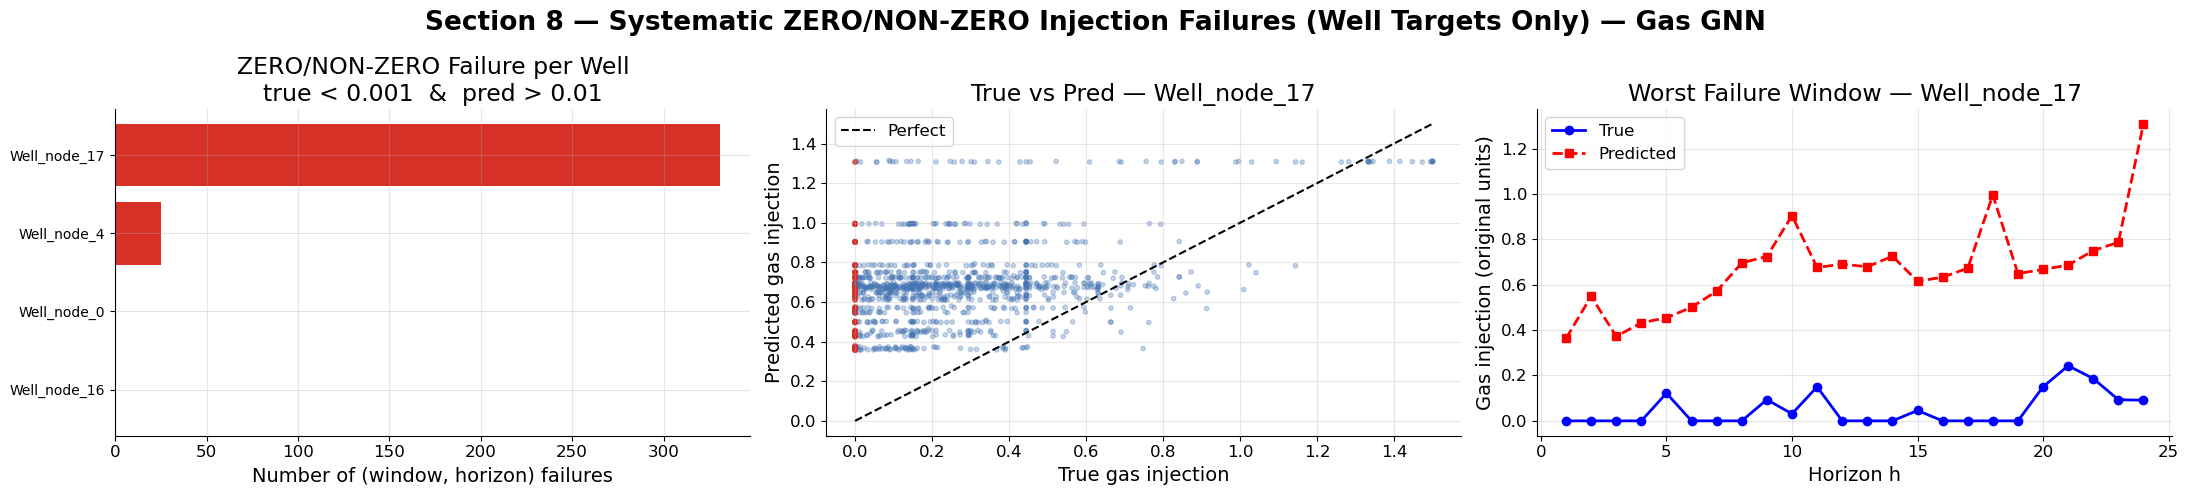

In [39]:
# ============================================================
# SECTION 8 — Systematic ZERO/NON-ZERO injection failure analysis
# CORRECTED: well-target labels only
# ============================================================
print("\n--- SECTION 8: Systematic ZERO/NON-ZERO injection failure analysis ---")

# À vérifier : définir N_WELLS_, HOR_, WELL_IDX_ si pas déjà fait
N_WELLS_  = len(CONFIG["WELL_IDX"])
HOR_      = CONFIG["HORIZON_HOURS"]
WELL_IDX_ = list(CONFIG["WELL_IDX"])

def _to3d(arr, n_wells, hor):
    arr = np.asarray(arr)
    if arr.ndim == 3:
        return arr
    if arr.ndim == 2:
        return arr.reshape(arr.shape[0] // n_wells, n_wells, hor)
    raise ValueError(f"Cannot reshape ndim={arr.ndim}")

if "test_out" in globals():
    y_true3 = _to3d(test_out["trues_real"], N_WELLS_, HOR_)
    y_pred3 = _to3d(test_out["preds_real"], N_WELLS_, HOR_)
    abs_err = np.abs(y_pred3 - y_true3)

    # Gas nodes: no name dataframe — use index labels
    well_names = [f"Well_node_{WELL_IDX_[j]}" for j in range(N_WELLS_)]

    print("  Well targets used in this analysis:")
    for j, nm in enumerate(well_names):
        print(f"    local output {j:02d} -> global node {WELL_IDX_[j]:02d} -> {nm}")

    # À ADAPTER : seuils en unités originales du gaz (MNm³/h)
    near_zero_thresh = 0.001   # injection vraie ≈ 0
    nonzero_pred_thr = 0.01    # mais prédiction non nulle

    mask_zero_fail = (np.abs(y_true3) < near_zero_thresh) & (np.abs(y_pred3) > nonzero_pred_thr)
    n_zero_fail    = int(mask_zero_fail.sum())
    mae_zero_fail  = float(np.mean(abs_err[mask_zero_fail])) if n_zero_fail > 0 else np.nan

    print(f"\n  ZERO/NON-ZERO threshold : true < {near_zero_thresh}, pred > {nonzero_pred_thr}")
    print(f"  Number of failures      : {n_zero_fail}")
    print(f"  Mean absolute error on those failures : {mae_zero_fail:.6f}")

    if n_zero_fail > 0:
        print("  → GNN predicts injection when the well is actually inactive.")
        print("    Start/stop dynamics may not be captured by the available features.")
    else:
        print("  → No ZERO/NON-ZERO failure detected with the current thresholds.")

    fail_per_well = mask_zero_fail.sum(axis=(0, 2))

    fail_df = pd.DataFrame({
        "well_j"         : np.arange(N_WELLS_),
        "global_well_idx": WELL_IDX_,
        "well_name"      : well_names,
        "n_failures"     : fail_per_well,
    }).sort_values("n_failures", ascending=False).reset_index(drop=True)

    display(fail_df)

    worst_well_j     = int(fail_df.iloc[0]["well_j"])
    worst_well_nm    = str(fail_df.iloc[0]["well_name"])
    worst_well_global = int(fail_df.iloc[0]["global_well_idx"])
    worst_fail_count = int(fail_df.iloc[0]["n_failures"])

    print(f"\n  Worst well for ZERO/NON-ZERO failure:")
    print(f"    local output index : {worst_well_j}")
    print(f"    global node index  : {worst_well_global}")
    print(f"    well name          : {worst_well_nm}")
    print(f"    number of failures : {worst_fail_count}")

    fig, axes = plt.subplots(1, 3, figsize=(22, 5))

    clrs_fail = ["#d73027" if n > 0 else "#4d9221" for n in fail_df["n_failures"]]
    axes[0].barh(range(len(fail_df)), fail_df["n_failures"], color=clrs_fail)
    axes[0].set_yticks(range(len(fail_df)))
    axes[0].set_yticklabels(fail_df["well_name"].values, fontsize=10)
    axes[0].invert_yaxis()
    axes[0].set_title(
        f"ZERO/NON-ZERO Failure per Well\ntrue < {near_zero_thresh}  &  pred > {nonzero_pred_thr}"
    )
    axes[0].set_xlabel("Number of (window, horizon) failures")
    axes[0].grid(True, axis="x", alpha=0.3)

    yt_w = y_true3[:, worst_well_j, :].ravel()
    yp_w = y_pred3[:, worst_well_j, :].ravel()

    clrs_sc = np.where(
        (np.abs(yt_w) < near_zero_thresh) & (np.abs(yp_w) > nonzero_pred_thr),
        "#d73027", "#4575b4"
    )

    axes[1].scatter(yt_w, yp_w, c=clrs_sc, alpha=0.3, s=10)
    lim_w = max(np.abs(yt_w).max(), np.abs(yp_w).max())
    axes[1].plot([0, lim_w], [0, lim_w], "k--", lw=1.5, label="Perfect")
    axes[1].set_title(f"True vs Pred — {worst_well_nm}")
    axes[1].set_xlabel("True gas injection")
    axes[1].set_ylabel("Predicted gas injection")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    fail_per_win = mask_zero_fail[:, worst_well_j, :].sum(axis=1)

    if fail_per_win.max() > 0:
        worst_win = int(np.argmax(fail_per_win))
        axes[2].plot(range(1, HOR_ + 1), y_true3[worst_win, worst_well_j, :],
                     "o-", color="blue", lw=2, label="True")
        axes[2].plot(range(1, HOR_ + 1), y_pred3[worst_win, worst_well_j, :],
                     "s--", color="red", lw=2, label="Predicted")
        axes[2].set_title(f"Worst Failure Window — {worst_well_nm}")
        axes[2].set_xlabel("Horizon h")
        axes[2].set_ylabel("Gas injection (original units)")
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)
    else:
        axes[2].text(0.5, 0.5,
                     "No ZERO/NON-ZERO failure detected\n(thresholds not triggered)",
                     ha="center", va="center",
                     transform=axes[2].transAxes, fontsize=13)
        axes[2].set_title("Worst failure window")
        axes[2].grid(True, alpha=0.3)

    plt.suptitle(
        "Section 8 — Systematic ZERO/NON-ZERO Injection Failures (Well Targets Only) — Gas GNN",
        fontweight="bold"
    )
    plt.tight_layout()
    plt.show()

else:
    print("  [SKIP] test_out not found.")

In [40]:
# ============================================================
# Cellule AB1 - Ablation "sans message passing réel"
# Encodeur MLP -> (aucune propagation graphe) -> Décodeur MLP
# But : tester si le message passing apporte vraiment quelque chose
# ============================================================

import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1) Modèle sans message passing
# ------------------------------------------------------------
class NoMessagePassingGas(nn.Module):
    """
    Même logique que SpatialGasGNN, sauf qu'on n'utilise
    ni edge_index ni edge_attr : chaque nœud est traité localement.
    """
    def __init__(
        self,
        in_dim: int,
        hidden_dim: int,
        horizon: int,
        encoder_hidden_dims=(256, 128),
        decoder_hidden_dims=(128, 64),
        dropout: float = 0.0,
        use_batchnorm: bool = True,
    ):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.horizon = horizon

        enc_dims = [in_dim] + list(encoder_hidden_dims) + [hidden_dim]
        self.encoder = MLP(
            enc_dims,
            dropout=dropout,
            use_batchnorm=use_batchnorm,
            activate_last=False
        )

        dec_dims = [hidden_dim] + list(decoder_hidden_dims) + [horizon]
        self.decoder = MLP(
            dec_dims,
            dropout=dropout,
            use_batchnorm=use_batchnorm,
            activate_last=False
        )

    def forward(self, x, edge_index, edge_attr, well_mask):
        # edge_index et edge_attr sont ignorés volontairement
        h = self.encoder(x)              # [N_total_batch, hidden_dim]
        h_wells = h[well_mask]           # [N_wells_total_batch, hidden_dim]
        out = self.decoder(h_wells)      # [N_wells_total_batch, horizon]
        return out


# ------------------------------------------------------------
# 2) Initialisation
# ------------------------------------------------------------
N_WELLS = len(CONFIG["WELL_IDX"])

ablation_model = NoMessagePassingGas(
    in_dim=expected_x_dim,
    hidden_dim=CONFIG["HIDDEN_DIM"],
    horizon=HOR,
    encoder_hidden_dims=CONFIG["ENCODER_HIDDEN_DIMS"],
    decoder_hidden_dims=CONFIG["DECODER_HIDDEN_DIMS"],
    dropout=CONFIG["DROPOUT"],
    use_batchnorm=CONFIG["USE_BATCHNORM"],
).to(DEVICE)

ablation_optimizer = torch.optim.Adam(
    ablation_model.parameters(),
    lr=CONFIG["LR"],
    weight_decay=CONFIG["WEIGHT_DECAY"]
)

ablation_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    ablation_optimizer,
    mode="min",
    factor=CONFIG["SCHEDULER_FACTOR"],
    patience=CONFIG["SCHEDULER_PATIENCE"],
    min_lr=CONFIG["SCHEDULER_MIN_LR"],
)

ablation_early_stopper = EarlyStopping(
    patience=CONFIG["EARLY_STOPPING_PATIENCE"],
    min_delta=CONFIG.get("EARLY_STOPPING_MIN_DELTA", 0.0),
)

ablation_history = {"train_loss": [], "val_loss": [], "lr": []}

print("=== Modèle sans message passing (Gas) ===")
print(ablation_model)


# ------------------------------------------------------------
# 3) Entraînement
# ------------------------------------------------------------
for epoch in range(1, CONFIG["EPOCHS"] + 1):
    train_loss = run_one_epoch(ablation_model, train_loader, optimizer=ablation_optimizer)
    val_loss   = run_one_epoch(ablation_model, val_loader, optimizer=None)

    ablation_scheduler.step(val_loss)
    current_lr = ablation_optimizer.param_groups[0]["lr"]

    ablation_history["train_loss"].append(train_loss)
    ablation_history["val_loss"].append(val_loss)
    ablation_history["lr"].append(current_lr)

    print(
        f"[NoMP] Epoch {epoch:03d} | "
        f"train={train_loss:.6f} | val={val_loss:.6f} | "
        f"counter={ablation_early_stopper.counter}/{ablation_early_stopper.patience} | "
        f"lr={current_lr:.2e}"
    )

    if ablation_early_stopper.step(val_loss, ablation_model):
        print(f"[NoMP] Early stopping déclenché à l'epoch {epoch}.")
        break

assert ablation_early_stopper.best_state is not None, "Aucun meilleur état sauvegardé pour le modèle NoMP."
ablation_model.load_state_dict(ablation_early_stopper.best_state)

print("\n[NoMP] Meilleur val_loss :", ablation_early_stopper.best_loss)


# ------------------------------------------------------------
# 4) Collecte des prédictions
# ------------------------------------------------------------
ablation_train_out = collect_predictions(ablation_model, train_loader)
ablation_val_out   = collect_predictions(ablation_model, val_loader)
ablation_test_out  = collect_predictions(ablation_model, test_loader)


# ------------------------------------------------------------
# 5) Évaluation
# ------------------------------------------------------------
def evaluate_output_dict_custom(out, split_name, model_prefix):
    preds_3d = ensure_3d_output(out["preds_real"], n_wells=N_WELLS, horizon=HOR)
    trues_3d = ensure_3d_output(out["trues_real"], n_wells=N_WELLS, horizon=HOR)

    rows = []

    # global
    m = mae_rmse_nmae(trues_3d, preds_3d)
    m.update({"split": split_name, "model": f"{model_prefix}_global"})
    rows.append(m)

    # par well
    for j, well_idx in enumerate(CONFIG["WELL_IDX"]):
        m = mae_rmse_nmae(trues_3d[:, j, :], preds_3d[:, j, :])
        m.update({
            "split": split_name,
            "model": f"{model_prefix}_well_{well_idx}",
            "well_global_idx": well_idx,
            # À vérifier : pas de buses_df dans le notebook gaz
            "well_name": f"well_node_{well_idx}",
        })
        rows.append(m)

    return pd.DataFrame(rows)


ablation_metrics_df = pd.concat([
    evaluate_output_dict_custom(ablation_train_out, "train", "NoMP"),
    evaluate_output_dict_custom(ablation_val_out,   "val",   "NoMP"),
    evaluate_output_dict_custom(ablation_test_out,  "test",  "NoMP"),
], axis=0, ignore_index=True)

print("\n=== Métriques modèle sans message passing (Gas) ===")
display(ablation_metrics_df)

print("\n=== Résumé global test : NoMP ===")
display(
    ablation_metrics_df[
        (ablation_metrics_df["split"] == "test") &
        (ablation_metrics_df["model"] == "NoMP_global")
    ]
)


# ------------------------------------------------------------
# 6) Comparaison directe avec :
#    - le GNN complet déjà entraîné (metrics_df)
#    - la persistence déjà calculée
# ------------------------------------------------------------
comparison_rows = []

# NoMP
tmp = ablation_metrics_df[
    (ablation_metrics_df["split"] == "test") &
    (ablation_metrics_df["model"] == "NoMP_global")
].copy()
if len(tmp) == 1:
    row = tmp.iloc[0]
    comparison_rows.append({
        "model": "NoMessagePassing",
        "MAE": row["MAE"],
        "RMSE": row["RMSE"],
        "NMAE": row["NMAE"],
    })

# GNN complet
# À vérifier : dans le notebook gaz (cell 27), le nom est "SpatialGNN_global"
if "metrics_df" in globals():
    tmp = metrics_df[
        (metrics_df["split"] == "test") &
        (metrics_df["model"] == "SpatialGNN_global")
    ].copy()
    if len(tmp) == 1:
        row = tmp.iloc[0]
        comparison_rows.append({
            "model": "SpatialGasGNN",
            "MAE": row["MAE"],
            "RMSE": row["RMSE"],
            "NMAE": row["NMAE"],
        })

# Persistence
if "metrics_df" in globals():
    tmp = metrics_df[
        (metrics_df["split"] == "test") &
        (metrics_df["model"] == "Persistence_global")
    ].copy()
    if len(tmp) == 1:
        row = tmp.iloc[0]
        comparison_rows.append({
            "model": "Persistence",
            "MAE": row["MAE"],
            "RMSE": row["RMSE"],
            "NMAE": row["NMAE"],
        })

comparison_df = pd.DataFrame(comparison_rows).sort_values("RMSE").reset_index(drop=True)

print("\n=== Comparaison finale test (global) — Gas GNN ===")
display(comparison_df)


# ------------------------------------------------------------
# 7) Conclusion automatique simple
# ------------------------------------------------------------
if len(comparison_df) >= 2:
    gnn_rmse  = comparison_df.loc[comparison_df["model"] == "SpatialGasGNN", "RMSE"]
    nomp_rmse = comparison_df.loc[comparison_df["model"] == "NoMessagePassing", "RMSE"]

    print("\n=== Interprétation automatique ===")
    if len(gnn_rmse) and len(nomp_rmse):
        rel_gap = 100 * (nomp_rmse.iloc[0] - gnn_rmse.iloc[0]) / max(abs(gnn_rmse.iloc[0]), 1e-12)

        print(f"Écart relatif RMSE NoMP vs GNN = {rel_gap:.2f}%")

        if abs(rel_gap) < 2:
            print("Conclusion : le message passing apporte très peu de gain mesurable dans cette configuration.")
        elif rel_gap > 0:
            print("Conclusion : le GNN complet est meilleur ; le message passing semble apporter de l'information utile.")
        else:
            print("Conclusion : le modèle sans message passing fait mieux ; le message passing semble inutile ou nuisible ici.")
    else:
        print("Impossible de comparer automatiquement NoMP et SpatialGasGNN.")

=== Modèle sans message passing (Gas) ===
NoMessagePassingGas(
  (encoder): MLP(
    (net): Sequential(
      (0): Linear(in_features=297, out_features=4, bias=True)
      (1): BatchNorm1d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.1, inplace=False)
      (4): Linear(in_features=4, out_features=2, bias=True)
      (5): BatchNorm1d(2, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU()
      (7): Dropout(p=0.1, inplace=False)
      (8): Linear(in_features=2, out_features=8, bias=True)
    )
  )
  (decoder): MLP(
    (net): Sequential(
      (0): Linear(in_features=8, out_features=2, bias=True)
      (1): BatchNorm1d(2, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.1, inplace=False)
      (4): Linear(in_features=2, out_features=4, bias=True)
      (5): BatchNorm1d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      

[NoMP] Epoch 092 | train=0.957828 | val=0.872482 | counter=2/30 | lr=5.00e-04
[NoMP] Epoch 093 | train=0.957009 | val=0.871994 | counter=3/30 | lr=5.00e-04
[NoMP] Epoch 094 | train=0.961180 | val=0.871342 | counter=0/30 | lr=5.00e-04
[NoMP] Epoch 095 | train=0.960467 | val=0.871130 | counter=0/30 | lr=5.00e-04
[NoMP] Epoch 096 | train=0.959445 | val=0.872629 | counter=0/30 | lr=5.00e-04
[NoMP] Epoch 097 | train=0.959676 | val=0.872472 | counter=1/30 | lr=5.00e-04
[NoMP] Epoch 098 | train=0.958811 | val=0.872114 | counter=2/30 | lr=5.00e-04
[NoMP] Epoch 099 | train=0.958823 | val=0.871139 | counter=3/30 | lr=5.00e-04
[NoMP] Epoch 100 | train=0.957308 | val=0.871113 | counter=4/30 | lr=3.00e-04

[NoMP] Meilleur val_loss : 0.8711134983647254
collect_predictions done
preds_scaled.shape = (1084, 24)
trues_scaled.shape = (1084, 24)
preds_real.shape   = (1084, 24)
trues_real.shape   = (1084, 24)
metas.shape        = (271,)
collect_predictions done
preds_scaled.shape = (124, 24)
trues_scaled.s

,MAE,RMSE,NMAE,split,model,well_global_idx,well_name
0,0.678227,0.824805,0.559767,train,NoMP_global,NaN,NaN
1,1.078797,1.218341,0.474588,train,NoMP_well_0,0.0,well_node_0
2,0.583057,0.657114,0.841204,train,NoMP_well_4,4.0,well_node_4
3,0.318762,0.403069,0.227822,train,NoMP_well_16,16.0,well_node_16
4,0.732292,0.801621,1.522200,train,NoMP_well_17,17.0,well_node_17
5,0.668580,0.787719,0.564594,val,NoMP_global,NaN,NaN
6,1.013343,1.106689,0.456535,val,NoMP_well_0,0.0,well_node_0
7,0.511400,0.581792,0.693543,val,NoMP_well_4,4.0,well_node_4
8,0.292233,0.353351,0.204377,val,NoMP_well_16,16.0,well_node_16
9,0.857345,0.891013,2.450761,val,NoMP_well_17,17.0,well_node_17



=== Résumé global test : NoMP ===


,MAE,RMSE,NMAE,split,model,well_global_idx,well_name
10,0.783643,0.941278,0.600953,test,NoMP_global,NaN,NaN



=== Comparaison finale test (global) — Gas GNN ===


,model,MAE,RMSE,NMAE
0,Persistence,0.284918,0.396007,0.218495
1,SpatialGasGNN,0.368137,0.451816,0.282313
2,NoMessagePassing,0.783643,0.941278,0.600953



=== Interprétation automatique ===
Écart relatif RMSE NoMP vs GNN = 108.33%
Conclusion : le GNN complet est meilleur ; le message passing semble apporter de l'information utile.


In [41]:
# ============================================================
# Cellule - Métriques sur les TOTAUX AGRÉGÉS (TEST)
# SpatialGasGNN vs Persistence vs NoMessagePassing
# ============================================================
import numpy as np
import pandas as pd

N_WELLS = len(CONFIG["WELL_IDX"])

def aggregate_totals_per_hour(arr, n_wells, horizon):
    """
    Entrée :
      - arr en shape [B*N_WELLS, HOR] ou [B, N_WELLS, HOR]
    Sortie :
      - totals en shape [B, HOR]
        = somme des wells pour chaque horizon
    """
    arr_3d = ensure_3d_output(arr, n_wells, horizon)   # [B, N_WELLS, HOR]
    totals = arr_3d.sum(axis=1)                        # [B, HOR]
    return totals

# ------------------------------------------------------------
# 1) Totaux agrégés - modèle GNN complet
# ------------------------------------------------------------
gnn_test_pred_tot = aggregate_totals_per_hour(test_out["preds_real"], N_WELLS, HOR)
gnn_test_true_tot = aggregate_totals_per_hour(test_out["trues_real"], N_WELLS, HOR)

# ------------------------------------------------------------
# 2) Totaux agrégés - modèle No Message Passing
# ------------------------------------------------------------
nomp_test_pred_tot = aggregate_totals_per_hour(ablation_test_out["preds_real"], N_WELLS, HOR)
nomp_test_true_tot = aggregate_totals_per_hour(ablation_test_out["trues_real"], N_WELLS, HOR)

# ------------------------------------------------------------
# 3) Totaux agrégés - Persistence
# ------------------------------------------------------------
pers_test_pred_tot = aggregate_totals_per_hour(pers_test_pred, N_WELLS, HOR)
pers_test_true_tot = aggregate_totals_per_hour(pers_test_true, N_WELLS, HOR)

# ------------------------------------------------------------
# 4) Métriques
# ------------------------------------------------------------
rows = []

m = mae_rmse_nmae(gnn_test_true_tot, gnn_test_pred_tot)
m["model"] = "SpatialGasGNN_aggregated_total"
rows.append(m)

m = mae_rmse_nmae(pers_test_true_tot, pers_test_pred_tot)
m["model"] = "Persistence_aggregated_total"
rows.append(m)

m = mae_rmse_nmae(nomp_test_true_tot, nomp_test_pred_tot)
m["model"] = "NoMessagePassing_aggregated_total"
rows.append(m)

agg_total_df = pd.DataFrame(rows)[["model", "MAE", "RMSE", "NMAE"]]
agg_total_df = agg_total_df.sort_values("RMSE").reset_index(drop=True)

print("=== Comparaison TEST sur les TOTAUX AGRÉGÉS (injection gaz) ===")
display(agg_total_df)

# ------------------------------------------------------------
# 5) Interprétation automatique NoMP vs GNN
# ------------------------------------------------------------
gnn_rmse = agg_total_df.loc[
    agg_total_df["model"] == "SpatialGasGNN_aggregated_total", "RMSE"
]
nomp_rmse = agg_total_df.loc[
    agg_total_df["model"] == "NoMessagePassing_aggregated_total", "RMSE"
]

if len(gnn_rmse) and len(nomp_rmse):
    rel_gap = 100 * (nomp_rmse.iloc[0] - gnn_rmse.iloc[0]) / max(abs(gnn_rmse.iloc[0]), 1e-12)

    print("\n=== Interprétation automatique (totaux agrégés — gaz) ===")
    print(f"Écart relatif RMSE NoMP vs GNN = {rel_gap:.2f}%")

    if abs(rel_gap) < 2:
        print("Conclusion : sur les totaux agrégés, le message passing apporte très peu de gain mesurable.")
    elif rel_gap > 0:
        print("Conclusion : sur les totaux agrégés, le GNN complet est meilleur ; le message passing semble utile.")
    else:
        print("Conclusion : sur les totaux agrégés, le modèle sans message passing fait mieux ; le message passing semble inutile ou nuisible ici.")

=== Comparaison TEST sur les TOTAUX AGRÉGÉS (injection gaz) ===


,model,MAE,RMSE,NMAE
0,Persistence_aggregated_total,0.641460,0.868651,0.122979
1,SpatialGasGNN_aggregated_total,0.762808,0.953360,0.146244
2,NoMessagePassing_aggregated_total,0.857298,1.053050,0.164359



=== Interprétation automatique (totaux agrégés — gaz) ===
Écart relatif RMSE NoMP vs GNN = 10.46%
Conclusion : sur les totaux agrégés, le GNN complet est meilleur ; le message passing semble utile.


In [42]:
# ============================================================
# Cellule - Roughness sur TOTAUX AGRÉGÉS (TEST)
# true / pred / error
# SpatialGasGNN vs Persistence vs NoMessagePassing
# ============================================================
import numpy as np
import pandas as pd

N_WELLS = len(CONFIG["WELL_IDX"])

def ensure_3d_output(arr, n_wells, horizon):
    arr = np.asarray(arr)
    if arr.ndim == 3:
        assert arr.shape[1] == n_wells and arr.shape[2] == horizon
        return arr
    if arr.ndim == 2:
        assert arr.shape[1] == horizon
        assert arr.shape[0] % n_wells == 0, \
            f"Lignes {arr.shape[0]} non divisible par n_wells={n_wells}"
        return arr.reshape(arr.shape[0] // n_wells, n_wells, horizon)
    raise ValueError(f"ndim non supporté: {arr.ndim}")

def aggregate_totals_per_hour(arr, n_wells, horizon):
    """
    Entrée : [B*N_WELLS, HOR] ou [B, N_WELLS, HOR]
    Sortie : [B, HOR] = somme des wells
    """
    arr_3d = ensure_3d_output(arr, n_wells, horizon)
    return arr_3d.sum(axis=1)

def roughness(x):
    x = np.asarray(x).reshape(-1)
    if len(x) < 2:
        return 0.0
    return float(np.mean(np.abs(np.diff(x))))

# ------------------------------------------------------------
# 1) Totaux agrégés
# ------------------------------------------------------------
gnn_true_tot = aggregate_totals_per_hour(test_out["trues_real"], N_WELLS, HOR)
gnn_pred_tot = aggregate_totals_per_hour(test_out["preds_real"], N_WELLS, HOR)

pers_true_tot = aggregate_totals_per_hour(pers_test_true, N_WELLS, HOR)
pers_pred_tot = aggregate_totals_per_hour(pers_test_pred, N_WELLS, HOR)

nomp_true_tot = aggregate_totals_per_hour(ablation_test_out["trues_real"], N_WELLS, HOR)
nomp_pred_tot = aggregate_totals_per_hour(ablation_test_out["preds_real"], N_WELLS, HOR)

# ------------------------------------------------------------
# 2) Erreurs
# ------------------------------------------------------------
gnn_err_tot  = gnn_pred_tot  - gnn_true_tot
pers_err_tot = pers_pred_tot - pers_true_tot
nomp_err_tot = nomp_pred_tot - nomp_true_tot

# ------------------------------------------------------------
# 3) Tableau roughness
# ------------------------------------------------------------
rows = []

rows.append({
    "model": "SpatialGasGNN",
    "rough_true":  roughness(gnn_true_tot),
    "rough_pred":  roughness(gnn_pred_tot),
    "rough_error": roughness(gnn_err_tot),
})

rows.append({
    "model": "Persistence",
    "rough_true":  roughness(pers_true_tot),
    "rough_pred":  roughness(pers_pred_tot),
    "rough_error": roughness(pers_err_tot),
})

rows.append({
    "model": "NoMessagePassing",
    "rough_true":  roughness(nomp_true_tot),
    "rough_pred":  roughness(nomp_pred_tot),
    "rough_error": roughness(nomp_err_tot),
})

roughness_df = pd.DataFrame(rows)
roughness_df["pred_minus_true"] = roughness_df["rough_pred"] - roughness_df["rough_true"]
roughness_df["pred_over_true"]  = roughness_df["rough_pred"] / np.maximum(roughness_df["rough_true"], 1e-12)

print("=== Roughness sur les TOTAUX AGRÉGÉS — injection gaz (TEST) ===")
display(roughness_df)

# ------------------------------------------------------------
# 4) Lecture rapide
# ------------------------------------------------------------
print("\n=== Lecture rapide ===")
for _, r in roughness_df.iterrows():
    print(f"{r['model']}:")
    print(f"  rough_true  = {r['rough_true']:.6f}")
    print(f"  rough_pred  = {r['rough_pred']:.6f}")
    print(f"  rough_error = {r['rough_error']:.6f}")
    print(f"  pred - true = {r['pred_minus_true']:.6f}")
    print(f"  pred / true = {r['pred_over_true']:.3f}")

=== Roughness sur les TOTAUX AGRÉGÉS — injection gaz (TEST) ===


,model,rough_true,rough_pred,rough_error,pred_minus_true,pred_over_true
0,SpatialGasGNN,0.599118,0.447786,0.530338,-0.151332,0.747408
1,Persistence,0.599118,0.604408,0.560054,0.005290,1.008830
2,NoMessagePassing,0.599118,0.365441,0.492172,-0.233677,0.609965



=== Lecture rapide ===
SpatialGasGNN:
  rough_true  = 0.599118
  rough_pred  = 0.447786
  rough_error = 0.530338
  pred - true = -0.151332
  pred / true = 0.747
Persistence:
  rough_true  = 0.599118
  rough_pred  = 0.604408
  rough_error = 0.560054
  pred - true = 0.005290
  pred / true = 1.009
NoMessagePassing:
  rough_true  = 0.599118
  rough_pred  = 0.365441
  rough_error = 0.492172
  pred - true = -0.233677
  pred / true = 0.610


In [43]:
# ============================================================
# Cellule - Constance des erreurs (GAZ)
# Formules :
#   e_i = |yhat_i - y_i|
#   mean_abs_err = (1/N) * sum_i e_i
#   std_abs_err  = sqrt( (1/N) * sum_i (e_i - mean_abs_err)^2 )
#   std_over_mean = std_abs_err / mean_abs_err
# ============================================================
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1) Récupération robuste des variables
# ------------------------------------------------------------
if "HOR_" not in globals():
    if "HOR" in globals():
        HOR_ = HOR
    else:
        raise NameError("HOR_ / HOR introuvable.")

if "N_WELLS_" not in globals():
    if "N_WELLS" in globals():
        N_WELLS_ = N_WELLS
    elif "N_GAS_TARGETS" in globals():
        N_WELLS_ = N_GAS_TARGETS
    else:
        raise NameError("N_WELLS_ / N_WELLS / N_GAS_TARGETS introuvable.")

if "test_out_" not in globals():
    test_out_ = test_out if "test_out" in globals() else None

if "ablation_test_out_" not in globals():
    ablation_test_out_ = ablation_test_out if "ablation_test_out" in globals() else None

if "pers_test_pred_" not in globals():
    pers_test_pred_ = pers_test_pred if "pers_test_pred" in globals() else None

if "pers_test_true_" not in globals():
    pers_test_true_ = pers_test_true if "pers_test_true" in globals() else None


# ------------------------------------------------------------
# 2) Fonctions utilitaires
# ------------------------------------------------------------
def _to_3d_pred(arr, n_wells, horizon):
    arr = np.asarray(arr)
    if arr.ndim == 3:
        assert arr.shape[1] == n_wells and arr.shape[2] == horizon, \
            f"Shape 3D inattendue: {arr.shape}, attendu (*, {n_wells}, {horizon})"
        return arr
    if arr.ndim == 2:
        assert arr.shape[1] == horizon, \
            f"Horizon inattendu dans {arr.shape}, attendu {horizon}"
        assert arr.shape[0] % n_wells == 0, \
            f"Lignes {arr.shape[0]} non divisible par n_wells={n_wells}"
        return arr.reshape(arr.shape[0] // n_wells, n_wells, horizon)
    raise ValueError(f"Shape non supportée: {arr.shape}")

def _aggregate_total(arr, n_wells, horizon):
    arr3 = _to_3d_pred(arr, n_wells, horizon)
    return arr3.sum(axis=1)  # [B, HOR]

def _error_constancy_metrics(y_true, y_pred, label="model"):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    abs_err = np.abs(y_pred - y_true)

    mean_abs_err = float(np.mean(abs_err))
    std_abs_err  = float(np.std(abs_err))
    std_over_mean = float(std_abs_err / mean_abs_err) if mean_abs_err > 1e-12 else np.nan

    return {
        "model": label,
        "mean_abs_err": mean_abs_err,
        "std_abs_err": std_abs_err,
        "std_over_mean": std_over_mean
    }

def _interpret_constancy(std_over_mean):
    if np.isnan(std_over_mean):
        return "interprétation impossible"
    elif std_over_mean < 0.30:
        return "erreurs très constantes"
    elif std_over_mean < 0.60:
        return "erreurs plutôt constantes"
    elif std_over_mean < 1.00:
        return "erreurs modérément variables"
    else:
        return "erreurs très irrégulières"


# ------------------------------------------------------------
# 3) Calculs
# ------------------------------------------------------------
rows = []

# SpatialGasGNN - global
if test_out_ is not None:
    rows.append(_error_constancy_metrics(
        test_out_["trues_real"],
        test_out_["preds_real"],
        label="SpatialGasGNN_global"
    ))

    # SpatialGasGNN - agrégé
    y_true_tot = _aggregate_total(test_out_["trues_real"], N_WELLS_, HOR_)
    y_pred_tot = _aggregate_total(test_out_["preds_real"], N_WELLS_, HOR_)
    rows.append(_error_constancy_metrics(
        y_true_tot, y_pred_tot,
        label="SpatialGasGNN_aggregated_total"
    ))

# NoMessagePassing - global
if ablation_test_out_ is not None:
    rows.append(_error_constancy_metrics(
        ablation_test_out_["trues_real"],
        ablation_test_out_["preds_real"],
        label="NoMessagePassing_global"
    ))

    # NoMessagePassing - agrégé
    y_true_tot = _aggregate_total(ablation_test_out_["trues_real"], N_WELLS_, HOR_)
    y_pred_tot = _aggregate_total(ablation_test_out_["preds_real"], N_WELLS_, HOR_)
    rows.append(_error_constancy_metrics(
        y_true_tot, y_pred_tot,
        label="NoMessagePassing_aggregated_total"
    ))

# Persistence - global
if pers_test_true_ is not None and pers_test_pred_ is not None:
    rows.append(_error_constancy_metrics(
        pers_test_true_,
        pers_test_pred_,
        label="Persistence_global"
    ))

    # Persistence - agrégé
    y_true_tot = _aggregate_total(pers_test_true_, N_WELLS_, HOR_)
    y_pred_tot = _aggregate_total(pers_test_pred_, N_WELLS_, HOR_)
    rows.append(_error_constancy_metrics(
        y_true_tot, y_pred_tot,
        label="Persistence_aggregated_total"
    ))

constancy_gas_df = pd.DataFrame(rows)[
    ["model", "mean_abs_err", "std_abs_err", "std_over_mean"]
].sort_values("std_over_mean").reset_index(drop=True)

print("=== GAZ | Constance des erreurs ===")
display(constancy_gas_df)

print("\n=== Interprétation ===")
for _, r in constancy_gas_df.iterrows():
    print(f"\n{r['model']}")
    print(f"  mean_abs_err  = {r['mean_abs_err']:.6f}")
    print(f"  std_abs_err   = {r['std_abs_err']:.6f}")
    print(f"  std/mean      = {r['std_over_mean']:.3f}")
    print(f"  lecture       = {_interpret_constancy(r['std_over_mean'])}")

if len(constancy_gas_df) >= 2:
    best_idx = constancy_gas_df["std_over_mean"].idxmin()
    best_model = constancy_gas_df.loc[best_idx, "model"]
    best_ratio = constancy_gas_df.loc[best_idx, "std_over_mean"]

    print("\n=== Conclusion rapide ===")
    print(f"Le modèle avec les erreurs les plus constantes est : {best_model} (std/mean = {best_ratio:.3f})")

=== GAZ | Constance des erreurs ===


,model,mean_abs_err,std_abs_err,std_over_mean
0,NoMessagePassing_global,0.783643,0.521447,0.665414
1,SpatialGasGNN_global,0.368137,0.261941,0.711530
2,NoMessagePassing_aggregated_total,0.857298,0.611518,0.713308
3,SpatialGasGNN_aggregated_total,0.762808,0.571855,0.749670
4,Persistence_aggregated_total,0.641460,0.585734,0.913126
5,Persistence_global,0.284918,0.275033,0.965308



=== Interprétation ===

NoMessagePassing_global
  mean_abs_err  = 0.783643
  std_abs_err   = 0.521447
  std/mean      = 0.665
  lecture       = erreurs modérément variables

SpatialGasGNN_global
  mean_abs_err  = 0.368137
  std_abs_err   = 0.261941
  std/mean      = 0.712
  lecture       = erreurs modérément variables

NoMessagePassing_aggregated_total
  mean_abs_err  = 0.857298
  std_abs_err   = 0.611518
  std/mean      = 0.713
  lecture       = erreurs modérément variables

SpatialGasGNN_aggregated_total
  mean_abs_err  = 0.762808
  std_abs_err   = 0.571855
  std/mean      = 0.750
  lecture       = erreurs modérément variables

Persistence_aggregated_total
  mean_abs_err  = 0.641460
  std_abs_err   = 0.585734
  std/mean      = 0.913
  lecture       = erreurs modérément variables

Persistence_global
  mean_abs_err  = 0.284918
  std_abs_err   = 0.275033
  std/mean      = 0.965
  lecture       = erreurs modérément variables

=== Conclusion rapide ===
Le modèle avec les erreurs les plus

In [44]:
# ============================================================
# Cellule - Constance des erreurs (GAZ)
# Formules :
#   e_i = |yhat_i - y_i|
#   MAE = (1/N) * sum_i e_i
#   STD = sqrt( (1/N) * sum_i (e_i - MAE)^2 )
#   STD_over_MAE = STD / MAE
# ============================================================
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1) Récupération robuste des variables
# ------------------------------------------------------------
if "HOR_" not in globals():
    if "HOR" in globals():
        HOR_ = HOR
    else:
        raise NameError("HOR_ / HOR introuvable.")

if "N_WELLS_" not in globals():
    if "N_WELLS" in globals():
        N_WELLS_ = N_WELLS
    elif "N_GAS_TARGETS" in globals():
        N_WELLS_ = N_GAS_TARGETS
    else:
        raise NameError("N_WELLS_ / N_WELLS / N_GAS_TARGETS introuvable.")

if "test_out_" not in globals():
    test_out_ = test_out if "test_out" in globals() else None

if "ablation_test_out_" not in globals():
    ablation_test_out_ = ablation_test_out if "ablation_test_out" in globals() else None

if "pers_test_pred_" not in globals():
    pers_test_pred_ = pers_test_pred if "pers_test_pred" in globals() else None

if "pers_test_true_" not in globals():
    pers_test_true_ = pers_test_true if "pers_test_true" in globals() else None

# ------------------------------------------------------------
# 2) Fonctions utilitaires
# ------------------------------------------------------------
def _to_3d_pred(arr, n_wells, horizon):
    arr = np.asarray(arr)
    if arr.ndim == 3:
        assert arr.shape[1] == n_wells and arr.shape[2] == horizon, \
            f"Shape 3D inattendue: {arr.shape}, attendu (*, {n_wells}, {horizon})"
        return arr
    if arr.ndim == 2:
        assert arr.shape[1] == horizon, \
            f"Horizon inattendu dans {arr.shape}, attendu {horizon}"
        assert arr.shape[0] % n_wells == 0, \
            f"Lignes {arr.shape[0]} non divisible par n_wells={n_wells}"
        return arr.reshape(arr.shape[0] // n_wells, n_wells, horizon)
    raise ValueError(f"Shape non supportée: {arr.shape}")

def _aggregate_total(arr, n_wells, horizon):
    arr3 = _to_3d_pred(arr, n_wells, horizon)
    return arr3.sum(axis=1)  # [B, HOR]

def _error_constancy_metrics(y_true, y_pred, label="model"):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    abs_err = np.abs(y_pred - y_true)

    mae = float(np.mean(abs_err))
    std = float(np.std(abs_err))
    std_over_mae = float(std / mae) if mae > 1e-12 else np.nan

    return {
        "model": label,
        "MAE_abs_err": mae,
        "STD_abs_err": std,
        "STD_over_MAE": std_over_mae
    }

def _interpret_constancy(std_over_mae):
    if np.isnan(std_over_mae):
        return "interprétation impossible"
    elif std_over_mae < 0.30:
        return "erreurs très constantes"
    elif std_over_mae < 0.60:
        return "erreurs plutôt constantes"
    elif std_over_mae < 1.00:
        return "erreurs modérément variables"
    else:
        return "erreurs très irrégulières"

# ------------------------------------------------------------
# 3) Calculs
# ------------------------------------------------------------
rows = []

# SpatialGasGNN - global
if test_out_ is not None:
    rows.append(_error_constancy_metrics(
        test_out_["trues_real"],
        test_out_["preds_real"],
        label="SpatialGasGNN_global"
    ))

    # SpatialGasGNN - agrégé
    y_true_tot = _aggregate_total(test_out_["trues_real"], N_WELLS_, HOR_)
    y_pred_tot = _aggregate_total(test_out_["preds_real"], N_WELLS_, HOR_)
    rows.append(_error_constancy_metrics(
        y_true_tot, y_pred_tot,
        label="SpatialGasGNN_aggregated_total"
    ))

# NoMessagePassing - global
if ablation_test_out_ is not None:
    rows.append(_error_constancy_metrics(
        ablation_test_out_["trues_real"],
        ablation_test_out_["preds_real"],
        label="NoMessagePassing_global"
    ))

    # NoMessagePassing - agrégé
    y_true_tot = _aggregate_total(ablation_test_out_["trues_real"], N_WELLS_, HOR_)
    y_pred_tot = _aggregate_total(ablation_test_out_["preds_real"], N_WELLS_, HOR_)
    rows.append(_error_constancy_metrics(
        y_true_tot, y_pred_tot,
        label="NoMessagePassing_aggregated_total"
    ))

# Persistence - global
if pers_test_true_ is not None and pers_test_pred_ is not None:
    rows.append(_error_constancy_metrics(
        pers_test_true_,
        pers_test_pred_,
        label="Persistence_global"
    ))

    # Persistence - agrégé
    y_true_tot = _aggregate_total(pers_test_true_, N_WELLS_, HOR_)
    y_pred_tot = _aggregate_total(pers_test_pred_, N_WELLS_, HOR_)
    rows.append(_error_constancy_metrics(
        y_true_tot, y_pred_tot,
        label="Persistence_aggregated_total"
    ))

constancy_gas_df = pd.DataFrame(rows)[
    ["model", "MAE_abs_err", "STD_abs_err", "STD_over_MAE"]
].sort_values("STD_over_MAE").reset_index(drop=True)

print("=== GAZ | Constance des erreurs (STD / MAE) ===")
display(constancy_gas_df)

print("\n=== Interprétation ===")
for _, r in constancy_gas_df.iterrows():
    print(f"\n{r['model']}")
    print(f"  MAE_abs_err  = {r['MAE_abs_err']:.6f}")
    print(f"  STD_abs_err  = {r['STD_abs_err']:.6f}")
    print(f"  STD/MAE      = {r['STD_over_MAE']:.3f}")
    print(f"  lecture      = {_interpret_constancy(r['STD_over_MAE'])}")

=== GAZ | Constance des erreurs (STD / MAE) ===


,model,MAE_abs_err,STD_abs_err,STD_over_MAE
0,NoMessagePassing_global,0.783643,0.521447,0.665414
1,SpatialGasGNN_global,0.368137,0.261941,0.711530
2,NoMessagePassing_aggregated_total,0.857298,0.611518,0.713308
3,SpatialGasGNN_aggregated_total,0.762808,0.571855,0.749670
4,Persistence_aggregated_total,0.641460,0.585734,0.913126
5,Persistence_global,0.284918,0.275033,0.965308



=== Interprétation ===

NoMessagePassing_global
  MAE_abs_err  = 0.783643
  STD_abs_err  = 0.521447
  STD/MAE      = 0.665
  lecture      = erreurs modérément variables

SpatialGasGNN_global
  MAE_abs_err  = 0.368137
  STD_abs_err  = 0.261941
  STD/MAE      = 0.712
  lecture      = erreurs modérément variables

NoMessagePassing_aggregated_total
  MAE_abs_err  = 0.857298
  STD_abs_err  = 0.611518
  STD/MAE      = 0.713
  lecture      = erreurs modérément variables

SpatialGasGNN_aggregated_total
  MAE_abs_err  = 0.762808
  STD_abs_err  = 0.571855
  STD/MAE      = 0.750
  lecture      = erreurs modérément variables

Persistence_aggregated_total
  MAE_abs_err  = 0.641460
  STD_abs_err  = 0.585734
  STD/MAE      = 0.913
  lecture      = erreurs modérément variables

Persistence_global
  MAE_abs_err  = 0.284918
  STD_abs_err  = 0.275033
  STD/MAE      = 0.965
  lecture      = erreurs modérément variables
